

<!-- TEASER_END -->

Let's first initialize the notebook:

In [1]:
import numpy as np
np.set_printoptions(precision=6, suppress=True)
import os

## an ambiguous arrangement of dots

# hexagonal grid

- grille hexagonale 
- objets circulaires
- taille des objet constante
- couleur variant seulement en hue de façon aléatoire


In [2]:
%pip install pycairo

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cairo
from IPython.display import Image, display
from math import pi
from io import BytesIO

DOWNSCALE = 8
N_height, N_width = int(np.sqrt(3)/2*12000)//DOWNSCALE, 12000//DOWNSCALE
N_height, N_width

(1299, 1500)

In [4]:
def disp(draw_func):
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, N_width, N_height)
    ctx = cairo.Context(surface)
    draw_func(ctx, N_height=N_height, N_width=N_width)
    with BytesIO() as fileobj:
        surface.write_to_png(fileobj)
        display(Image(fileobj.getvalue(), width=N_width))

def render(draw_func, savepath):
    with cairo.PDFSurface(f"{savepath}.pdf", N_width, N_height) as surface:
        ctx = cairo.Context(surface)
        draw_func(ctx, N_height=N_height, N_width=N_width)        

figpath = '../files'
%mkdir -p {figpath}
import numpy as np
np.set_printoptions(precision=2, suppress=True)

import os
from IPython import get_ipython
ip = get_ipython()
# print(ip.user_ns)
study_name = None
if '__vsc_ipynb_file__' in ip.user_ns:
    # https://github.com/msm1089/ipynbname/issues/17
    study_name = os.path.split(os.path.basename(ip.user_ns['__vsc_ipynb_file__']))[1]
elif '__file__' in ip.user_ns:
    study_name = ip.user_ns['__file__']#.replace('.ipynb', '')
else:
    import ipynbname
    study_name = ipynbname.name()

savepath = os.path.join(figpath, study_name.replace('.ipynb', ''))
savepath

'../files/2026-07-31-pale-blue-dots'

In [5]:
def hue_to_rgba(hue, alpha=1.):
    """
    Convert a hue value to an isoluminant RGB color.
    The hue value should be in degrees [0, 360).
    """
    hue = np.mod(hue, 360.)
    theta = np.deg2rad(hue)

    # Linear-RGB luminance weights.
    luma = np.array([0.2126, 0.7152, 0.0722])

    # Two orthonormal directions in the plane orthogonal to luminance.
    basis_u = np.array([luma[1], -luma[0], 0.0])
    basis_u /= np.linalg.norm(basis_u)
    basis_v = np.cross(luma, basis_u)
    basis_v /= np.linalg.norm(basis_v)

    # Constant luminance in linear RGB, with a safe chroma radius.
    base_luminance = 0.5
    chroma = 0.25
    rgb_linear = base_luminance + chroma * (
        np.cos(theta) * basis_u + np.sin(theta) * basis_v
    )
    rgb_linear = np.clip(rgb_linear, 0.0, 1.0)

    return (*rgb_linear, alpha)

In [6]:
def circle(cr, x, y, radius):
    """
    x      - center x
    y      - center y
    width  - width of ellipse  (in x direction when angle=0)
    height - height of ellipse (in y direction when angle=0)
    angle  - angle in radians to rotate, clockwise
    """
    cr.save()
    cr.translate(x, y)
    cr.scale(radius / 2.0, radius / 2.0)
    cr.arc(0.0, 0.0, 1.0, 0.0, 2.0 * pi)
    cr.restore()


0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233 	377 	610 	987 	1597 	2584 	4181 

In [7]:
N_H, N_W = 20, 20
N_H, N_W = 8, 8
N_H, N_W

(8, 8)

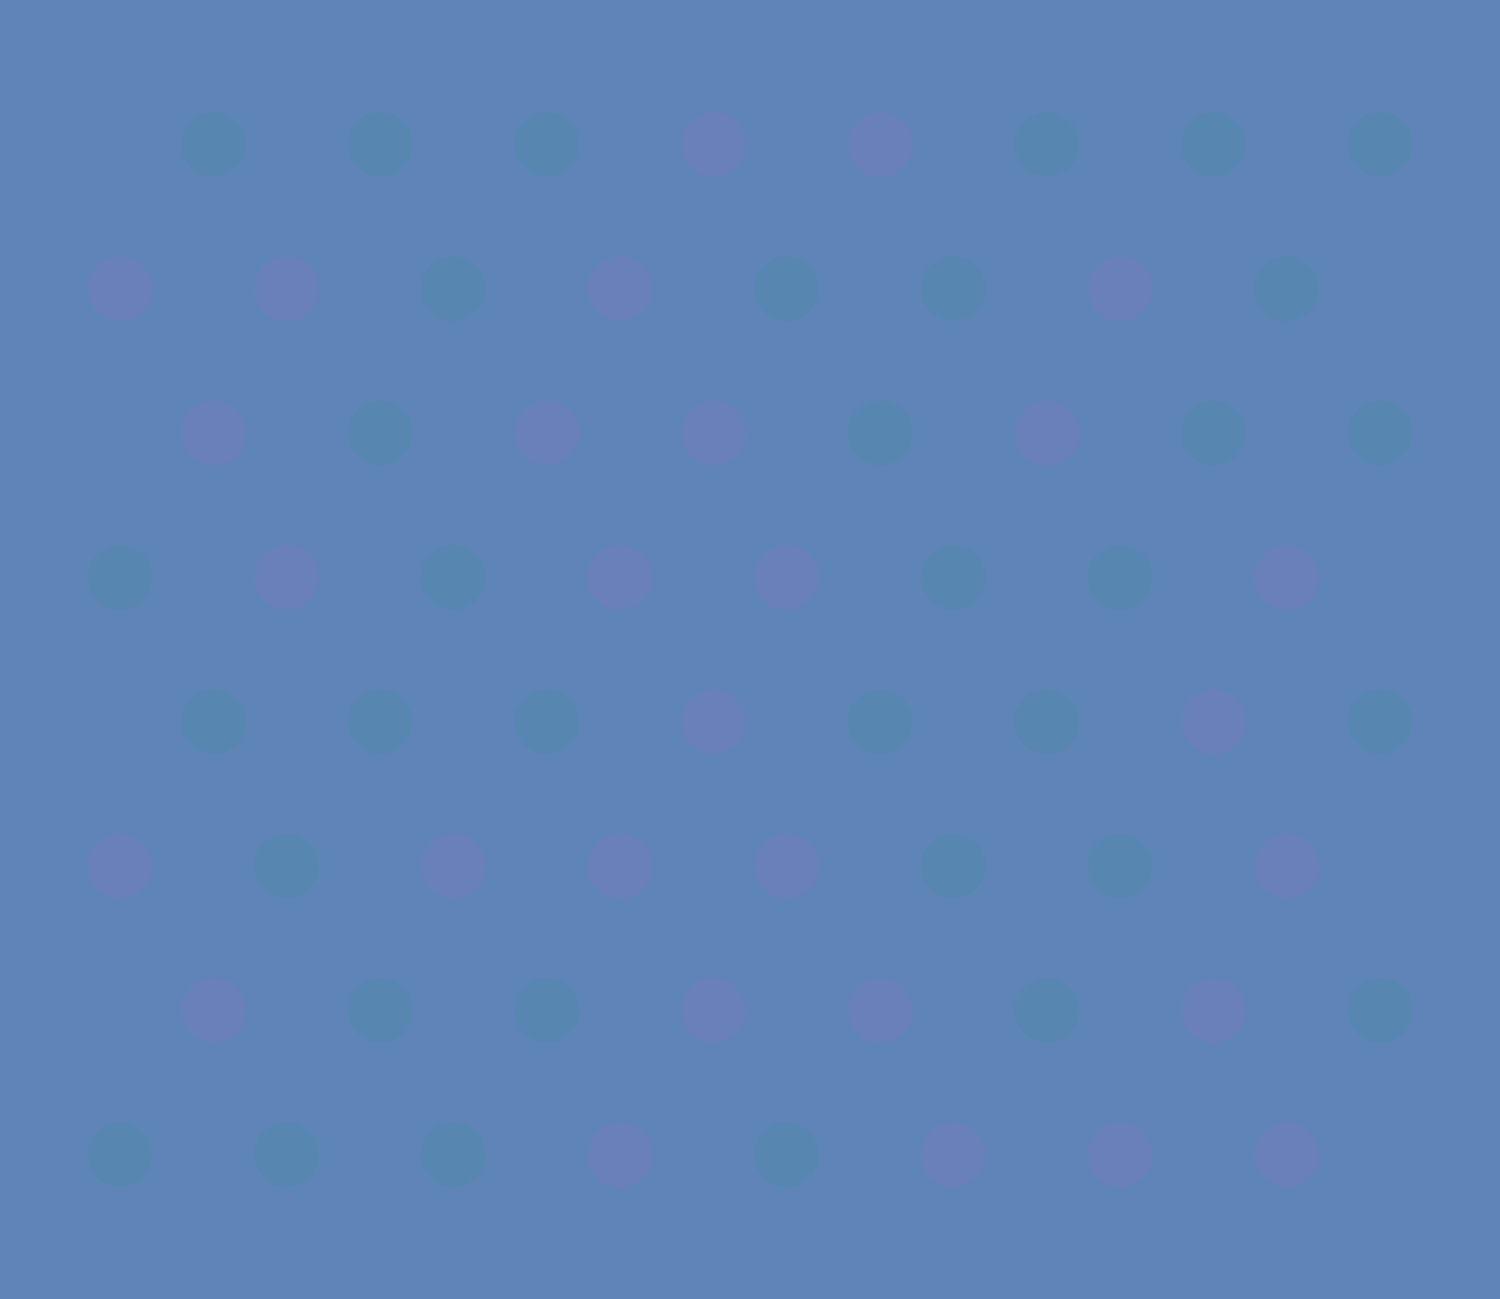

In [8]:
def hexagonal_grid(cr, N_height, N_width, N_H, N_W, size_mag, alpha, c_mean, c_std, operator):

    cr.save()
    cr.set_operator(cairo.OPERATOR_SOURCE)
    cr.set_source_rgba(*hue_to_rgba(c_mean, 1.))
    cr.paint()
    cr.restore()

    cr.set_operator(operator)

    # Compute the grid
    # https://laurentperrinet.github.io/sciblog/posts/2020-04-16-creating-an-hexagonal-grid.html    
    width_v, height_v = np.meshgrid(np.linspace(0, N_width, N_W+2, endpoint=True)[1:-1], 
                                    np.linspace(0, N_height, N_H+2, endpoint=True)[1:-1], sparse=False, indexing='xy')
    
    width_v[::2, :] += N_width/N_W/4  # shift every second row by half a column
    width_v[1::2, :] -= N_width/N_W/4  # shift every second row by half a column

    # convert to cartesian coordinates
    X = width_v
    Y = height_v
    R = size_mag * N_height / N_H * np.ones_like(X)  # constant radius
    # C = np.random.normal(loc=c_mean, scale=c_std, size=X.shape)  # random hue values
    # C = (c_mean + c_std) * np.ones_like(X)  # incremented hue values
    C = c_mean + c_std * np.sign(np.random.normal(loc=0, scale=c_std, size=X.shape))  # random hue values

    # draw 
    for x, y, r, c in zip(X.ravel(), Y.ravel(), R.ravel(), C.ravel()):
        circle(cr, x, y, r)
        cr.set_source_rgba(*hue_to_rgba(c, alpha))
        cr.fill()

    return cr

# blue 
c_blue = 240
c_std = 10
opts = dict(N_height=N_height, N_width=N_width, N_H=N_H, N_W=N_W,
            size_mag=.4, alpha=1., c_mean=c_blue, c_std=c_std, operator=cairo.OPERATOR_OVER)

@disp
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)

In [9]:
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)
render(draw, savepath)

# scanning some parameters

In [10]:
N_scan = 9

## alpha

alpha_=1.00e-01


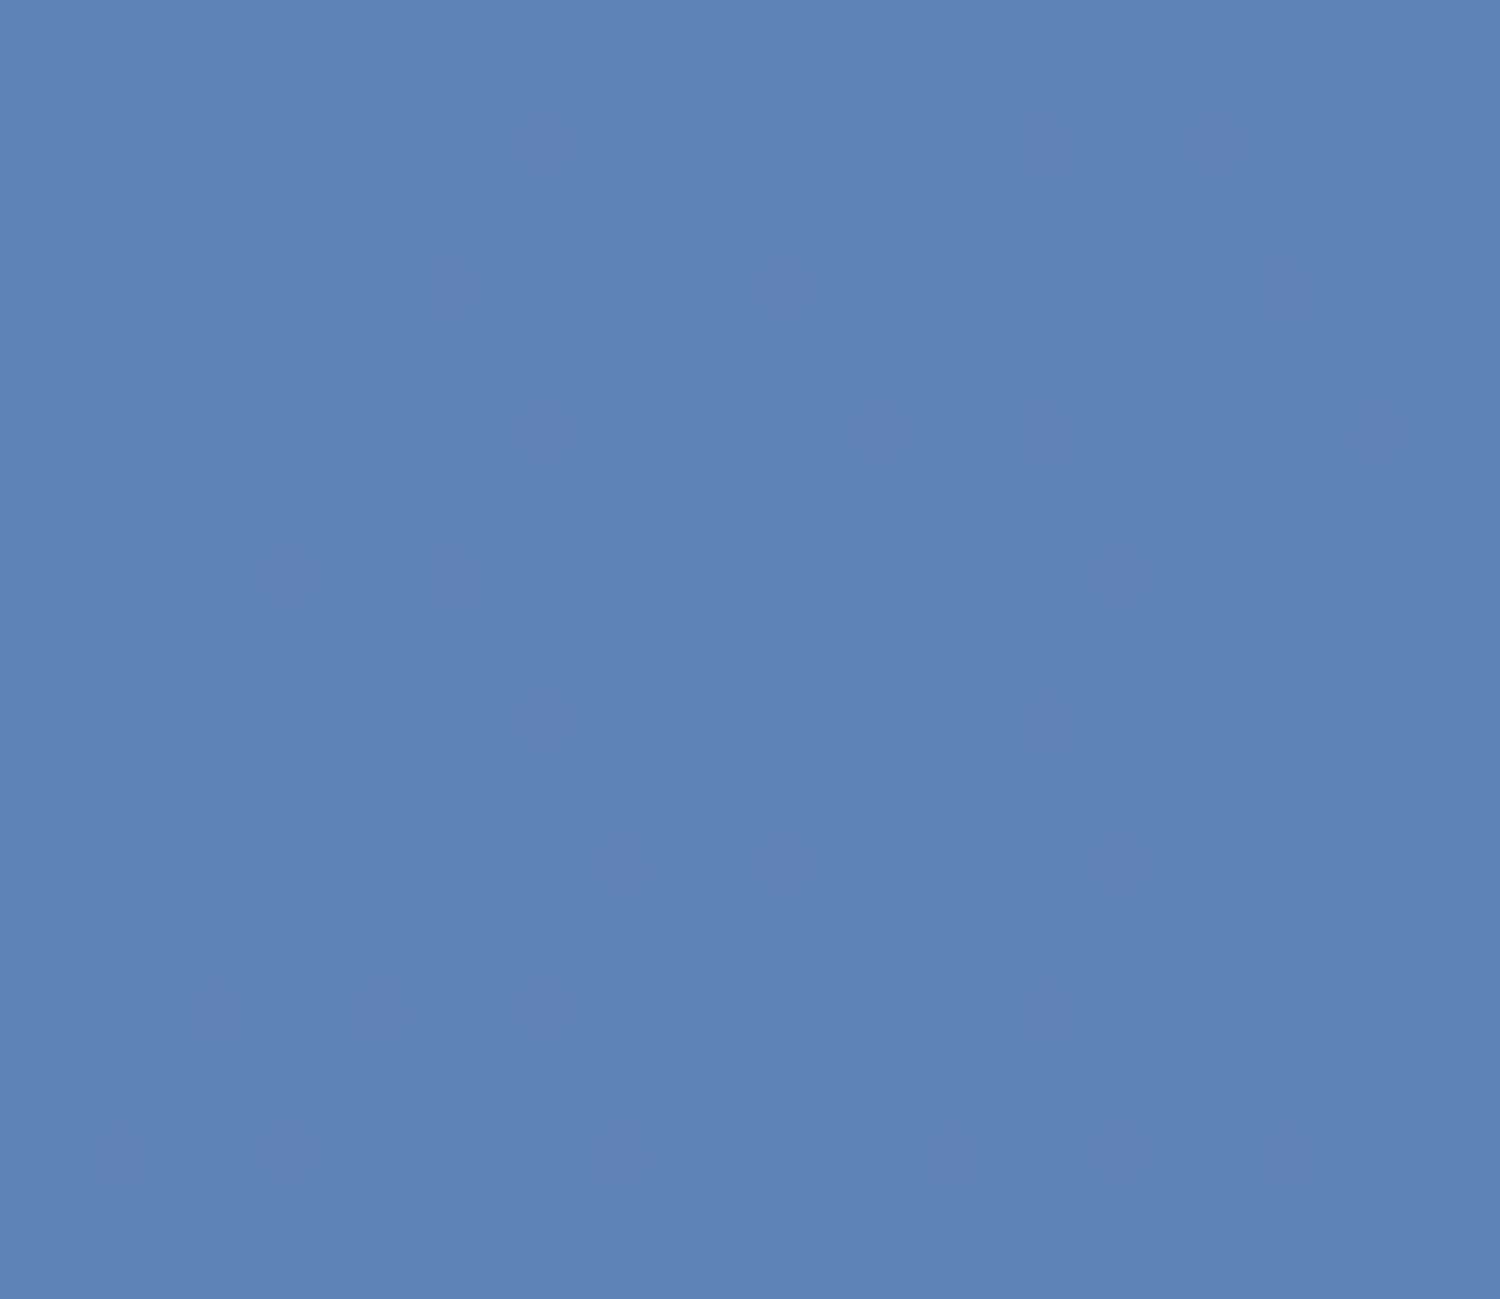

alpha_=2.13e-01


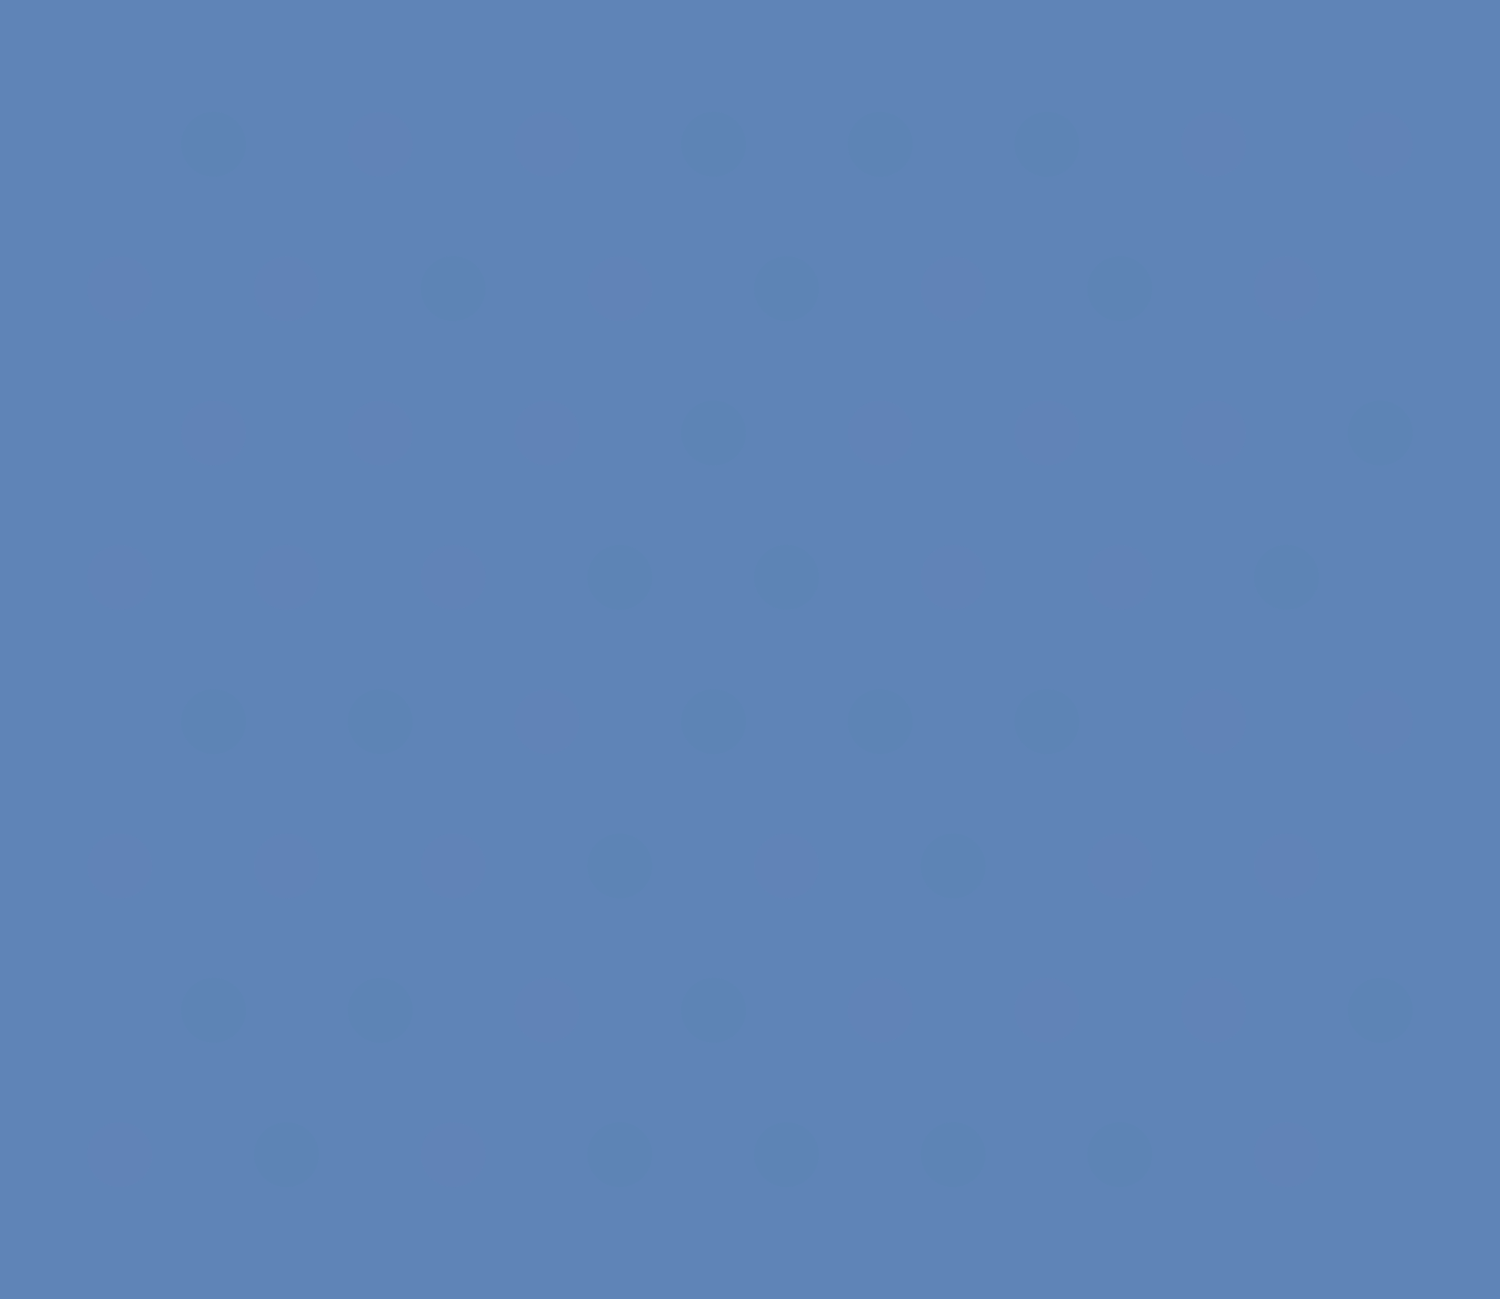

alpha_=3.25e-01


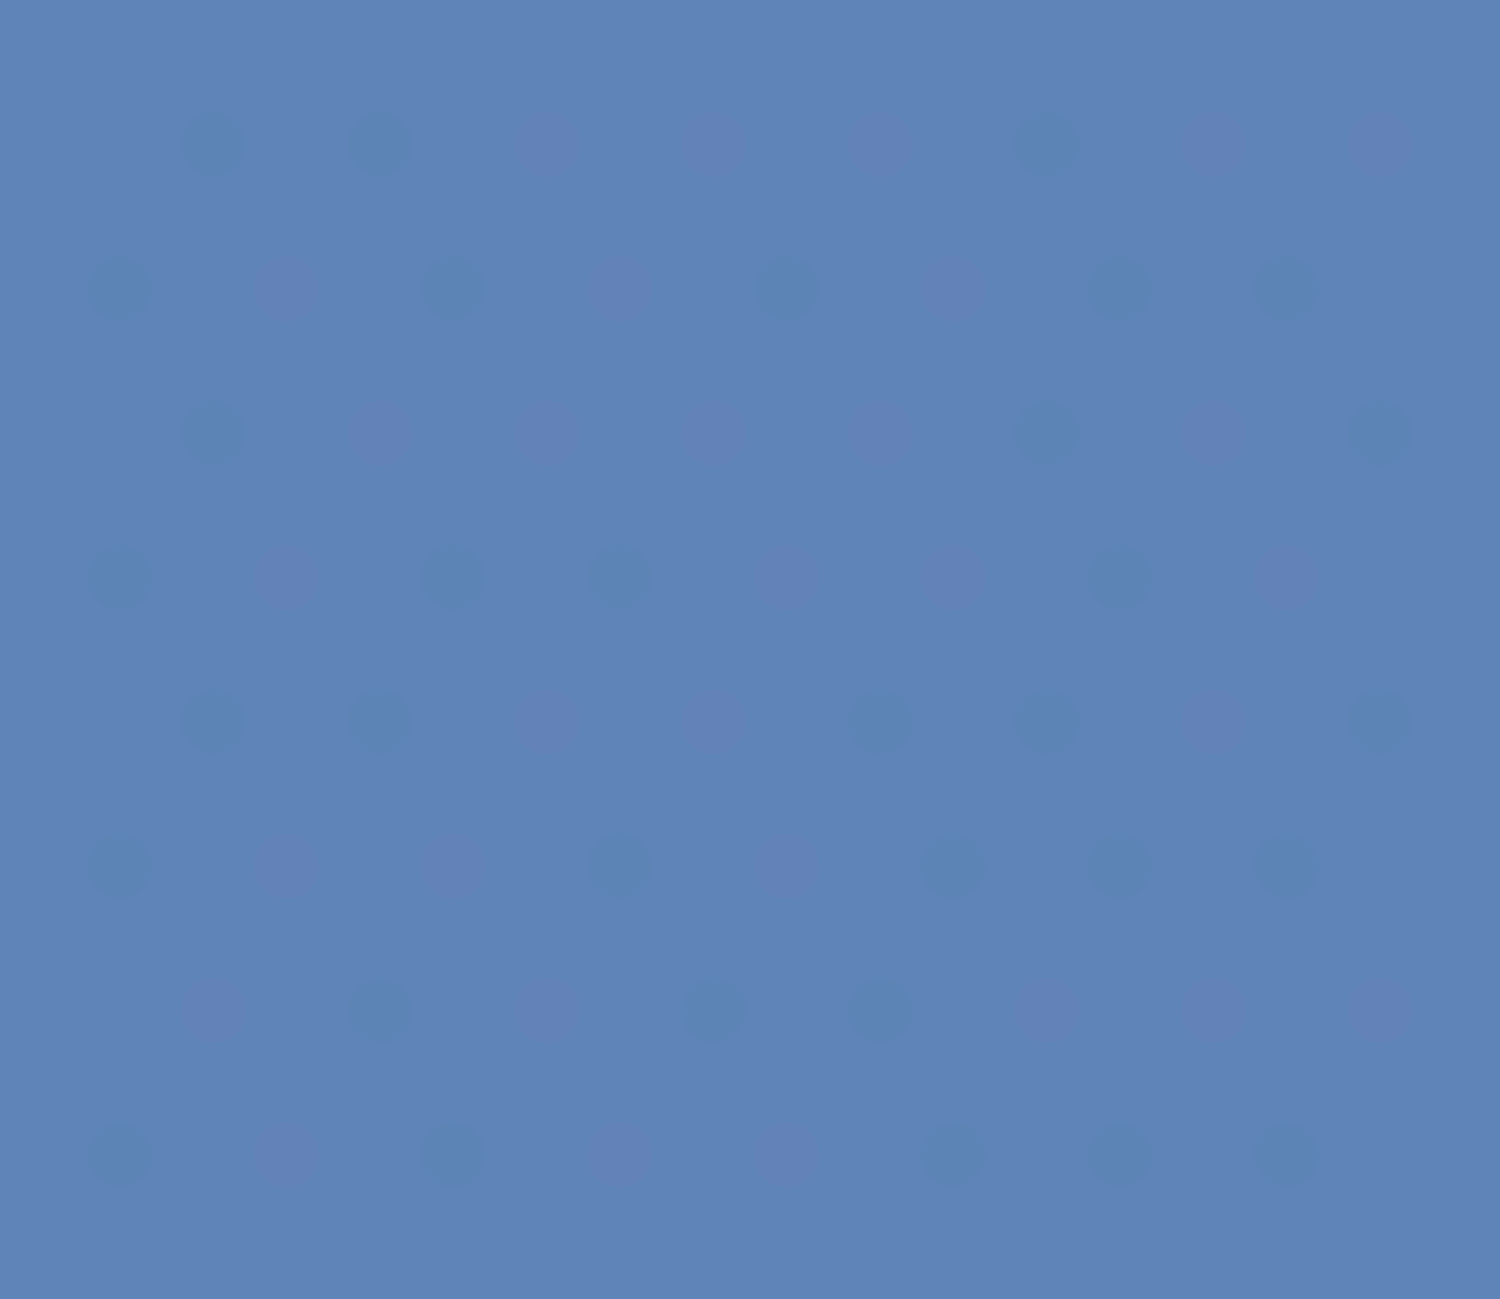

alpha_=4.38e-01


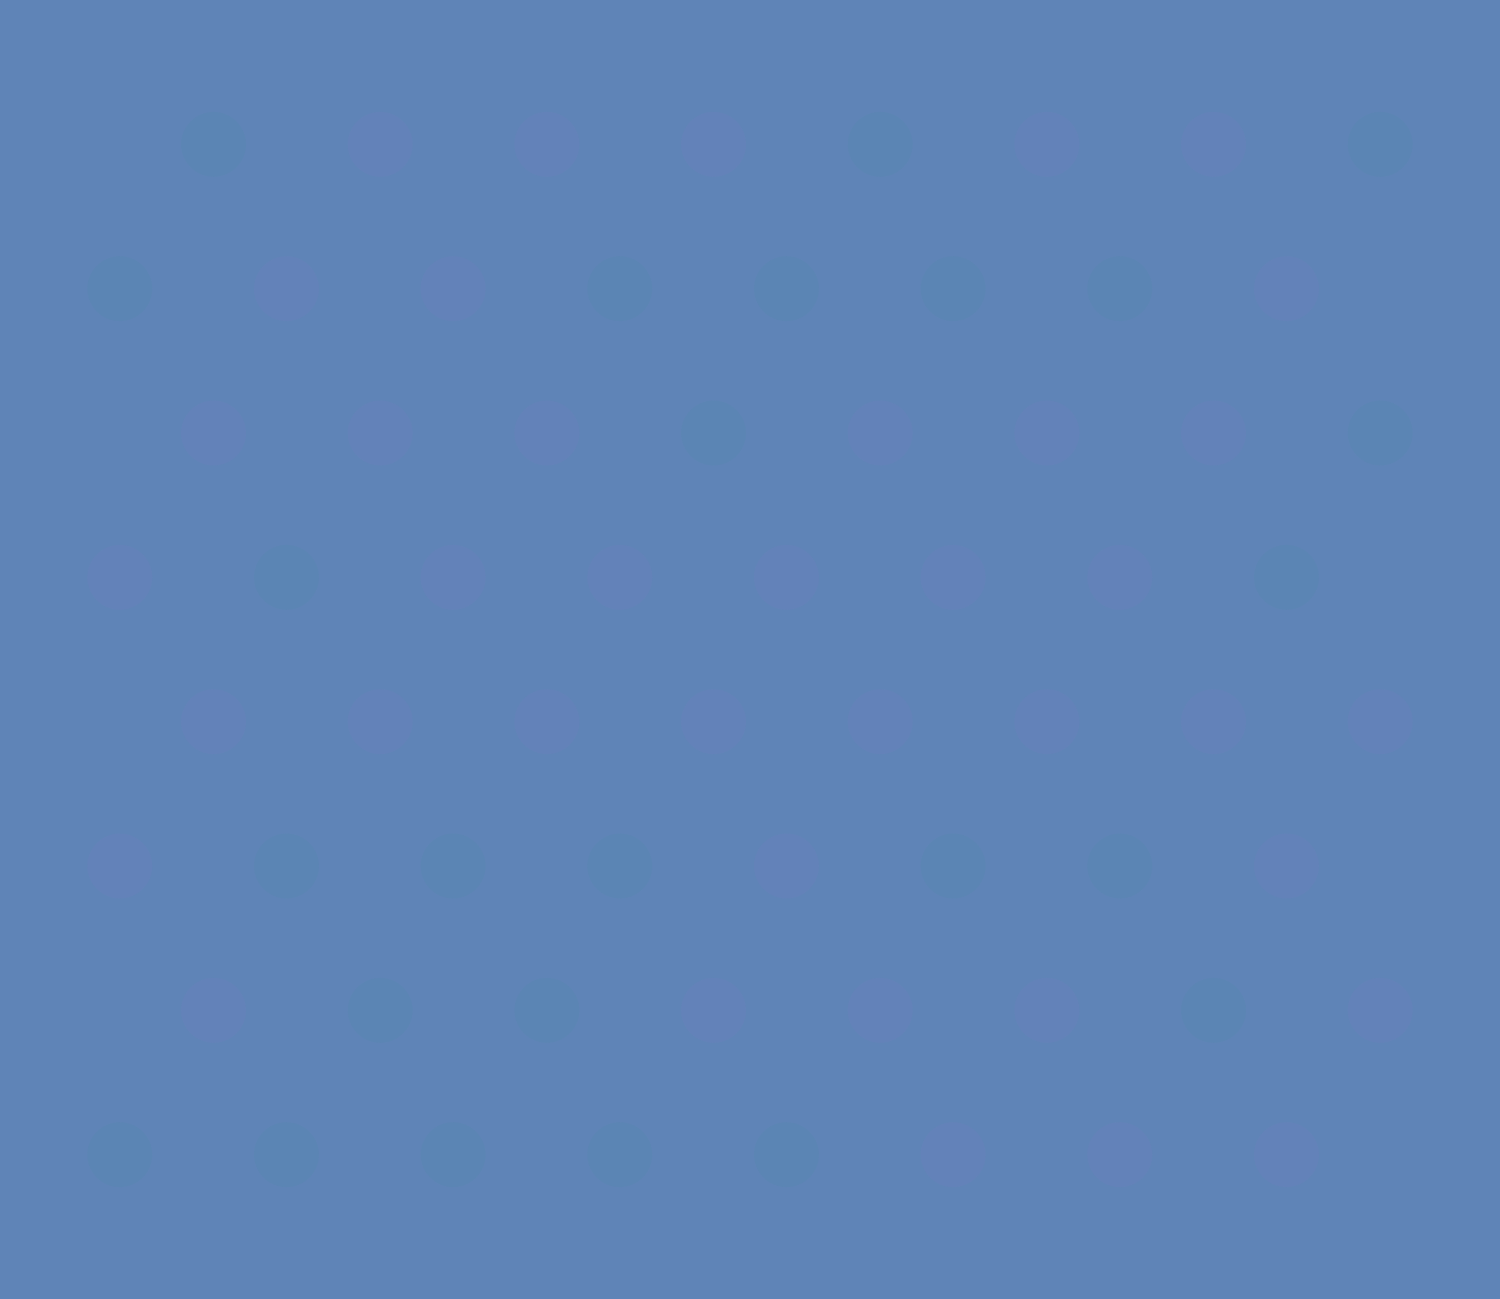

alpha_=5.50e-01


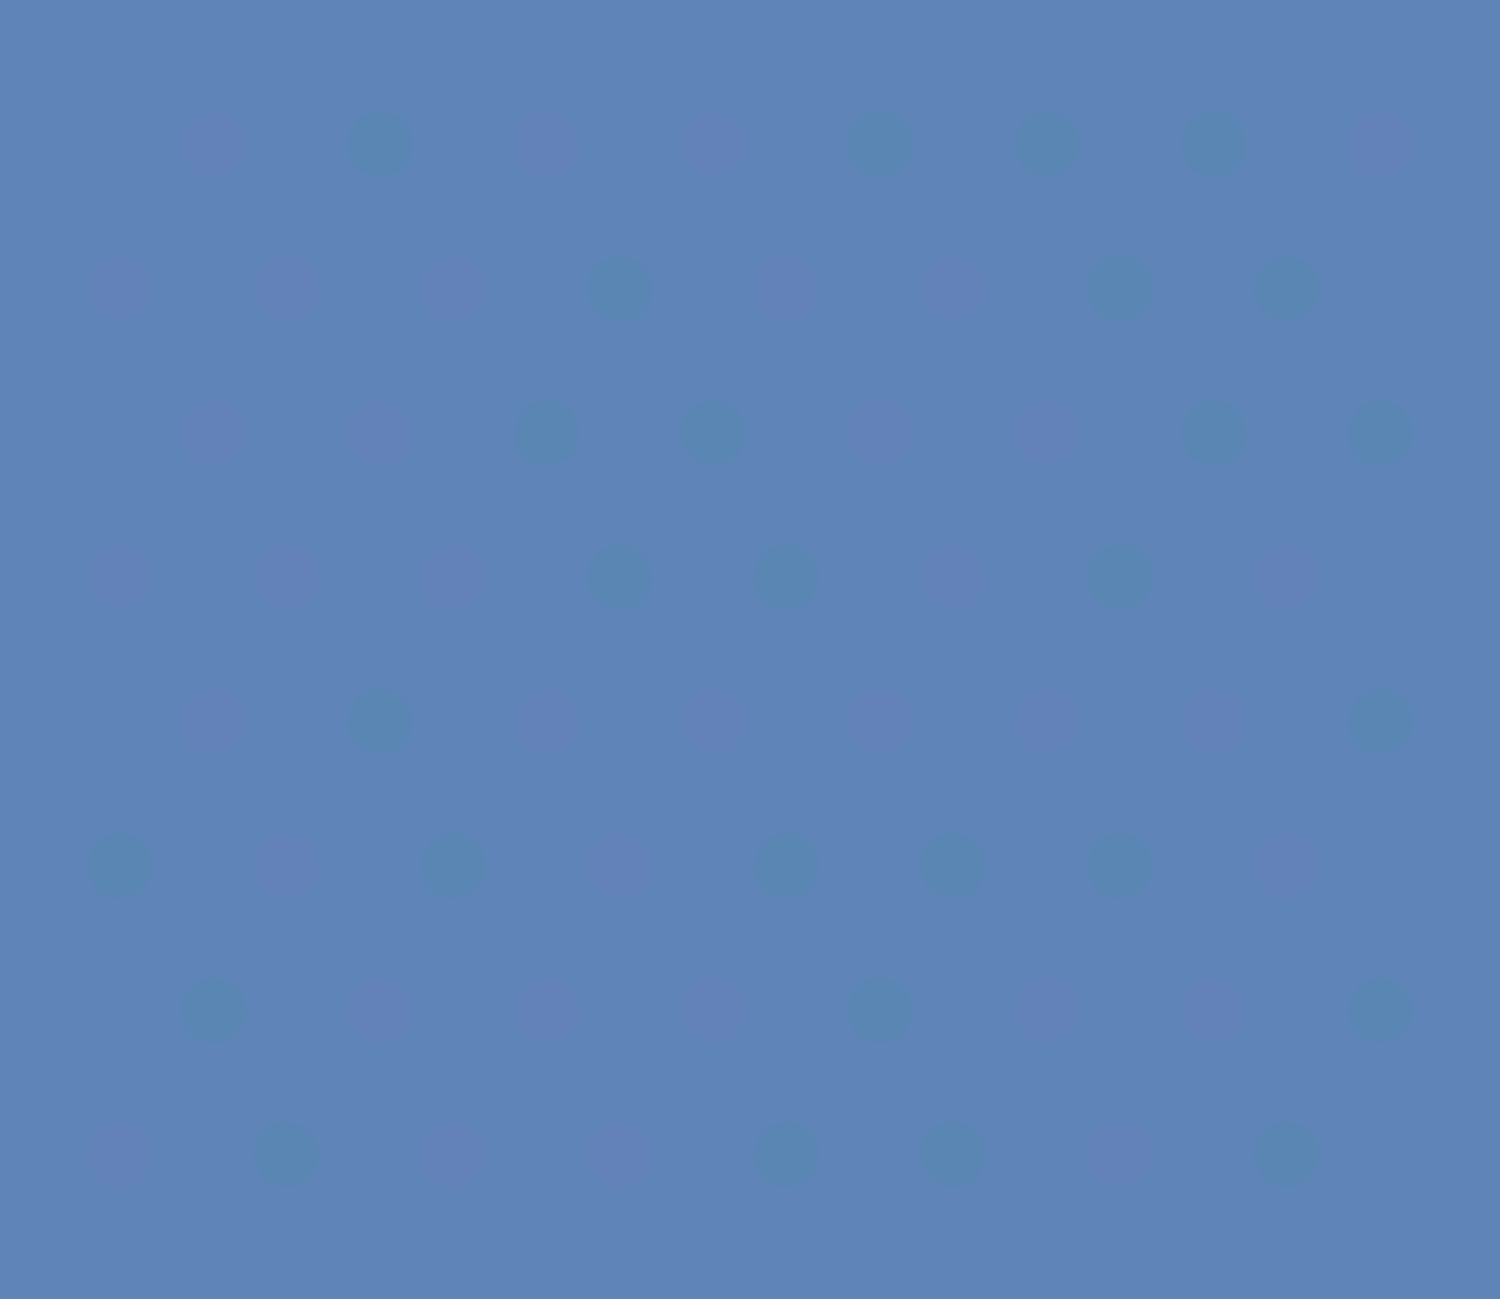

alpha_=6.62e-01


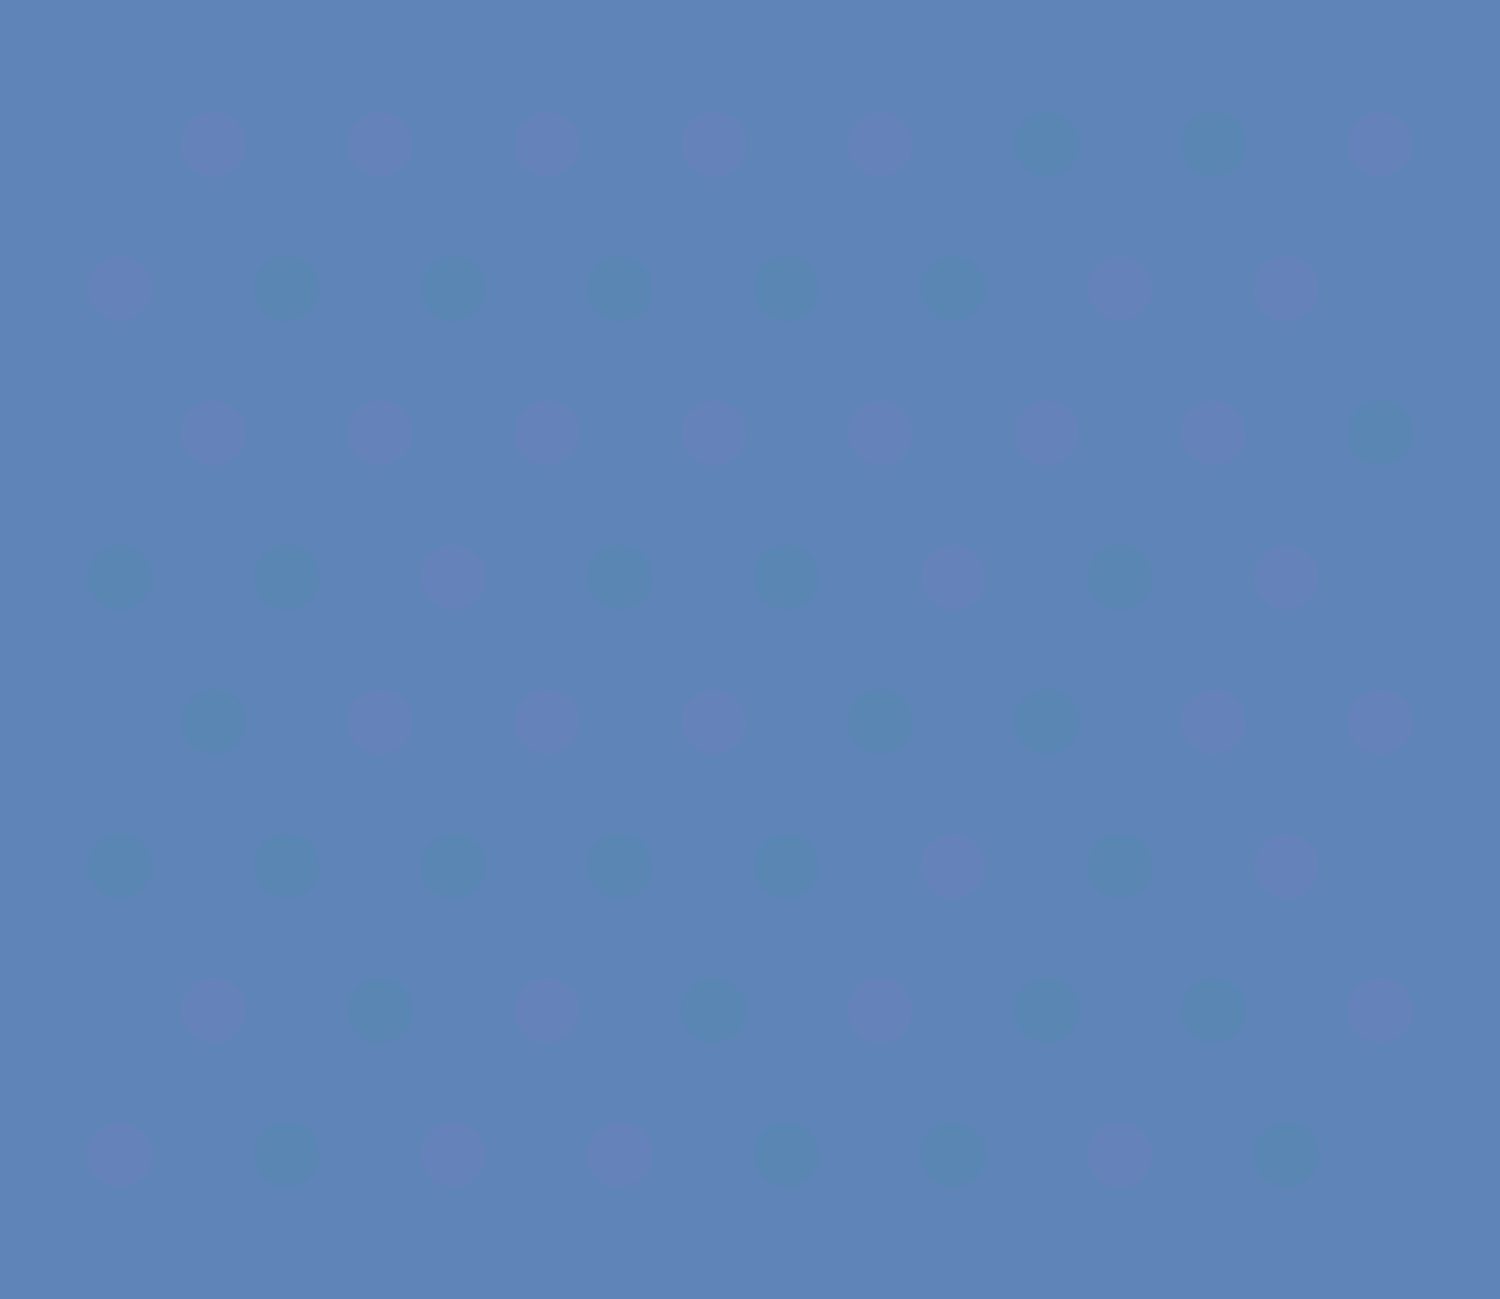

alpha_=7.75e-01


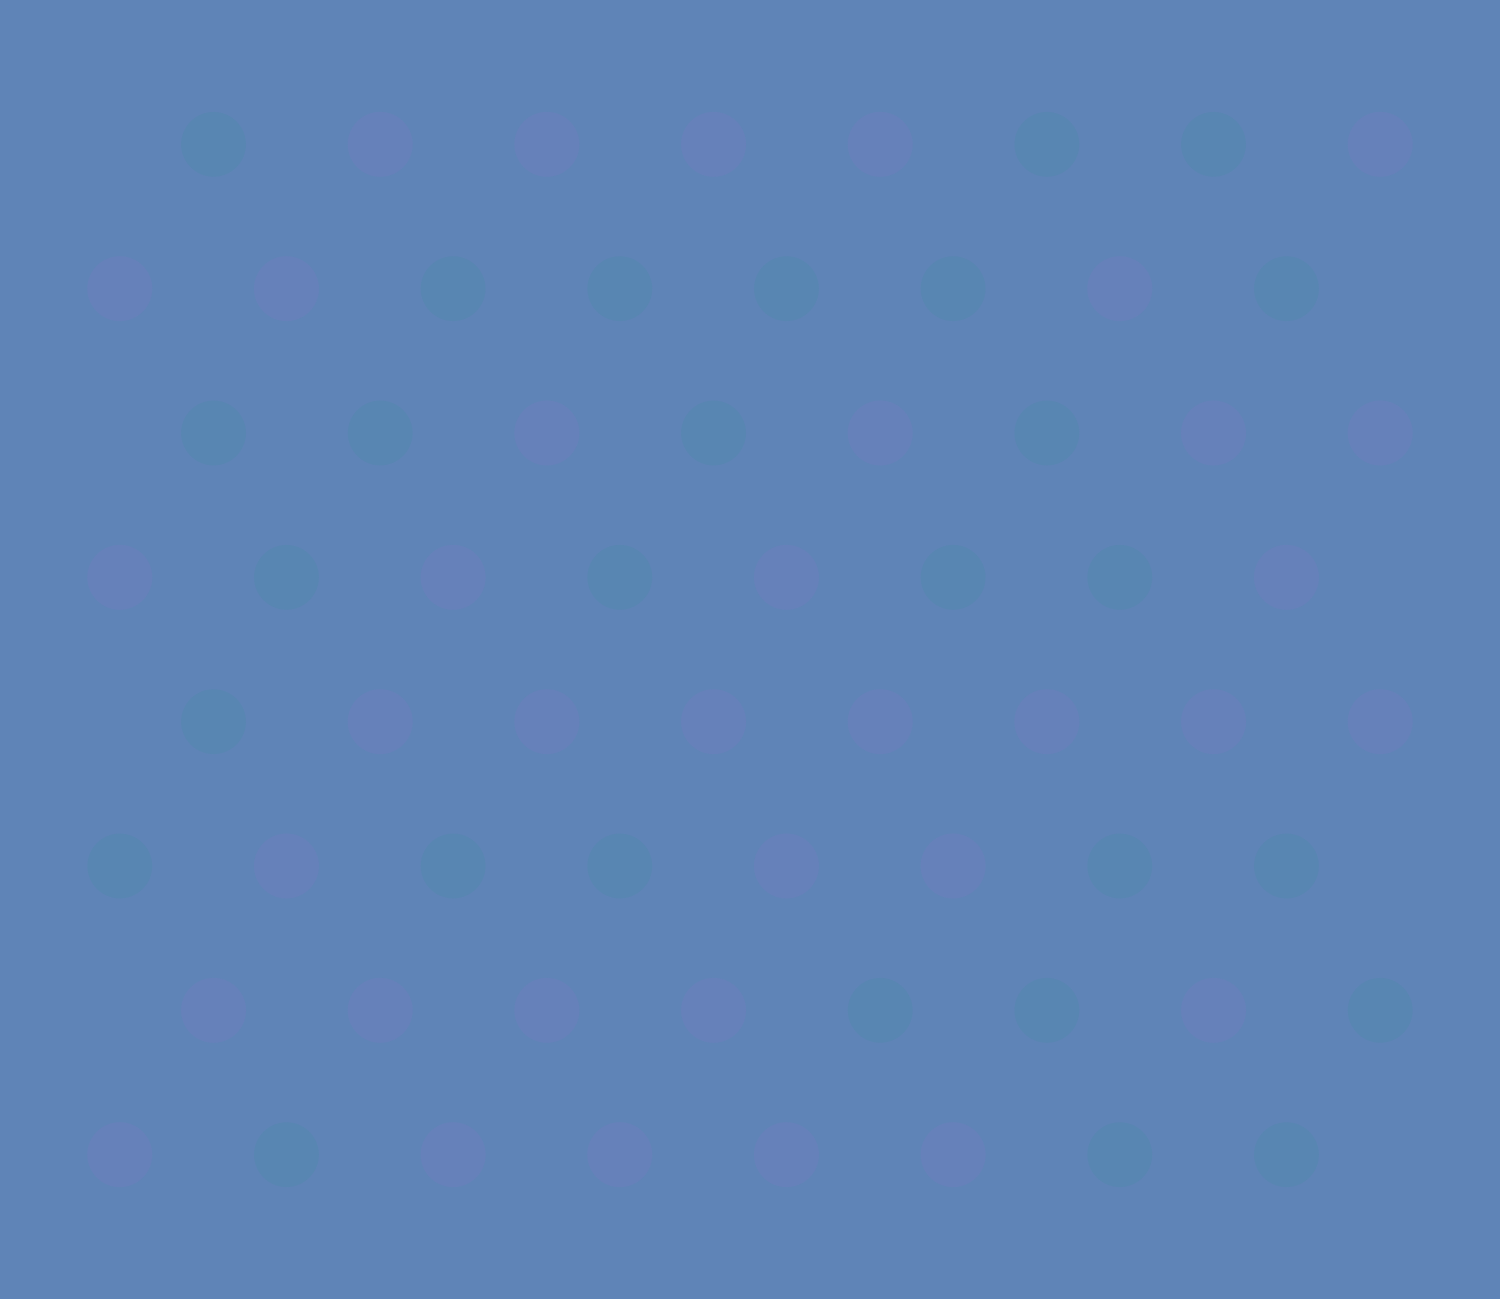

alpha_=8.87e-01


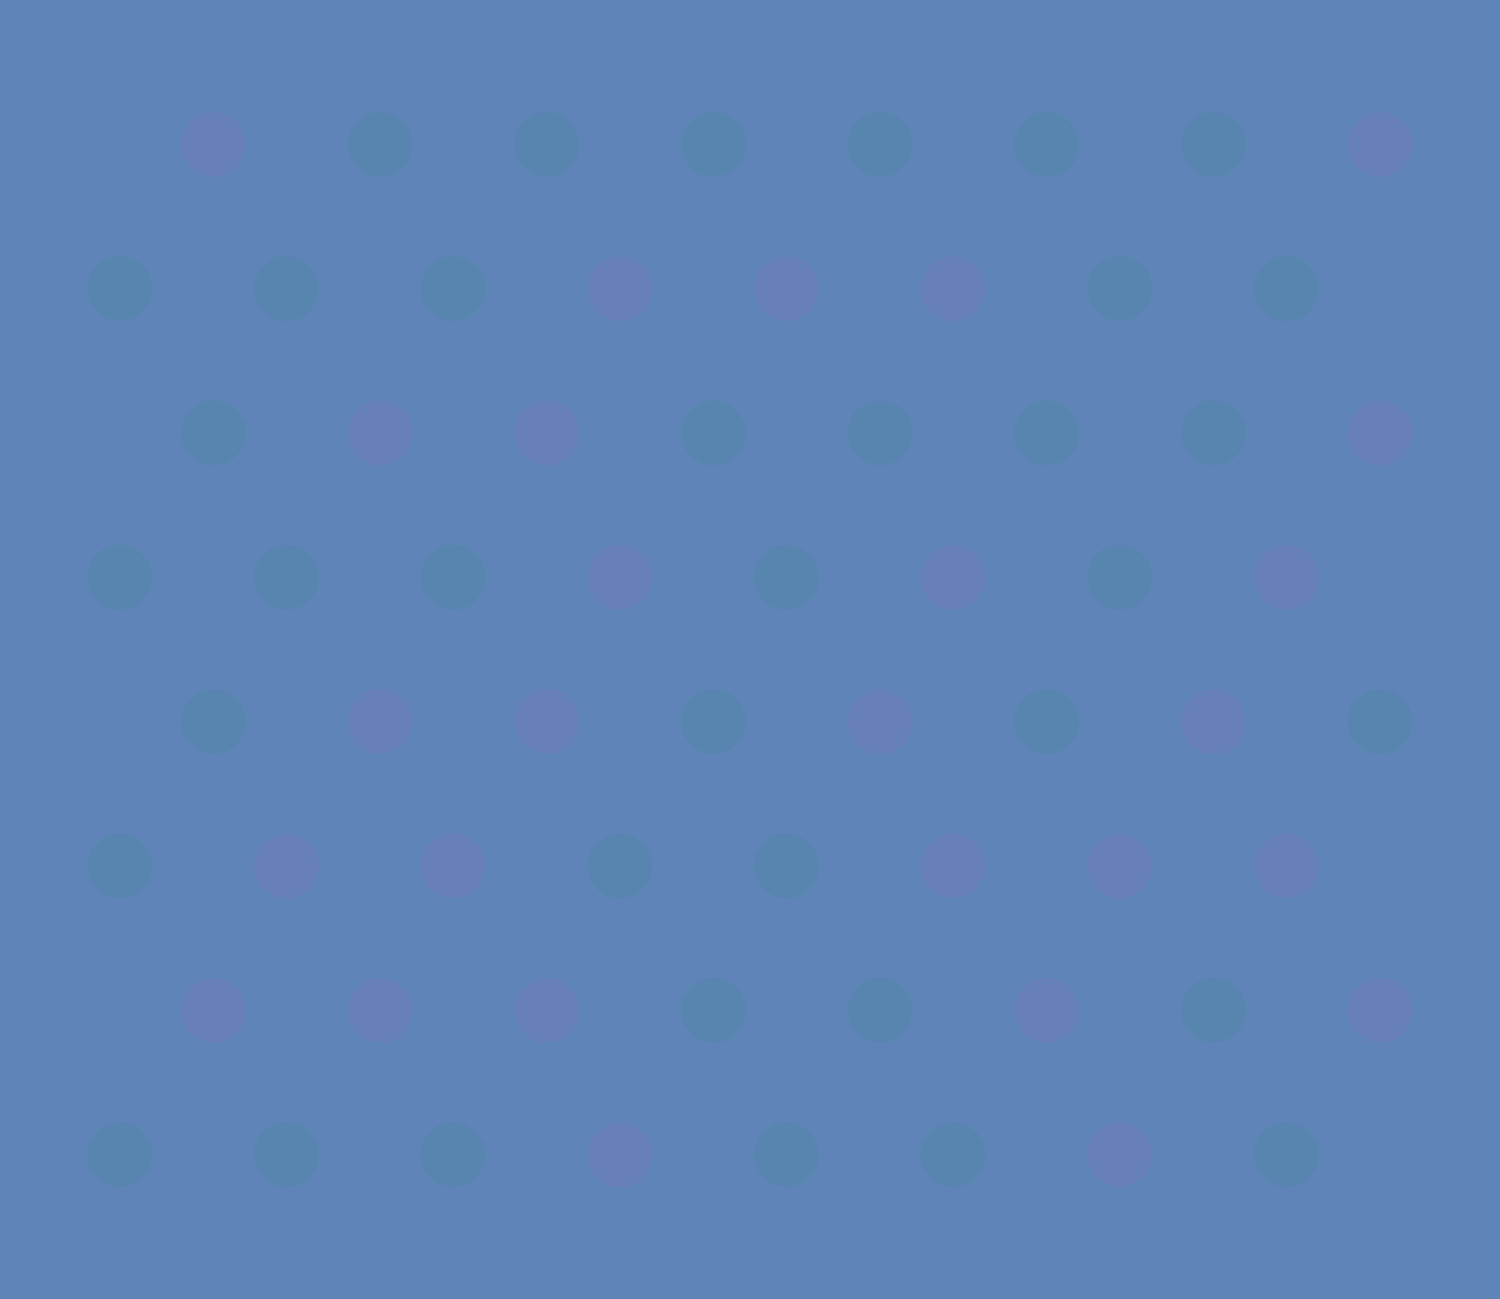

alpha_=1.00e+00


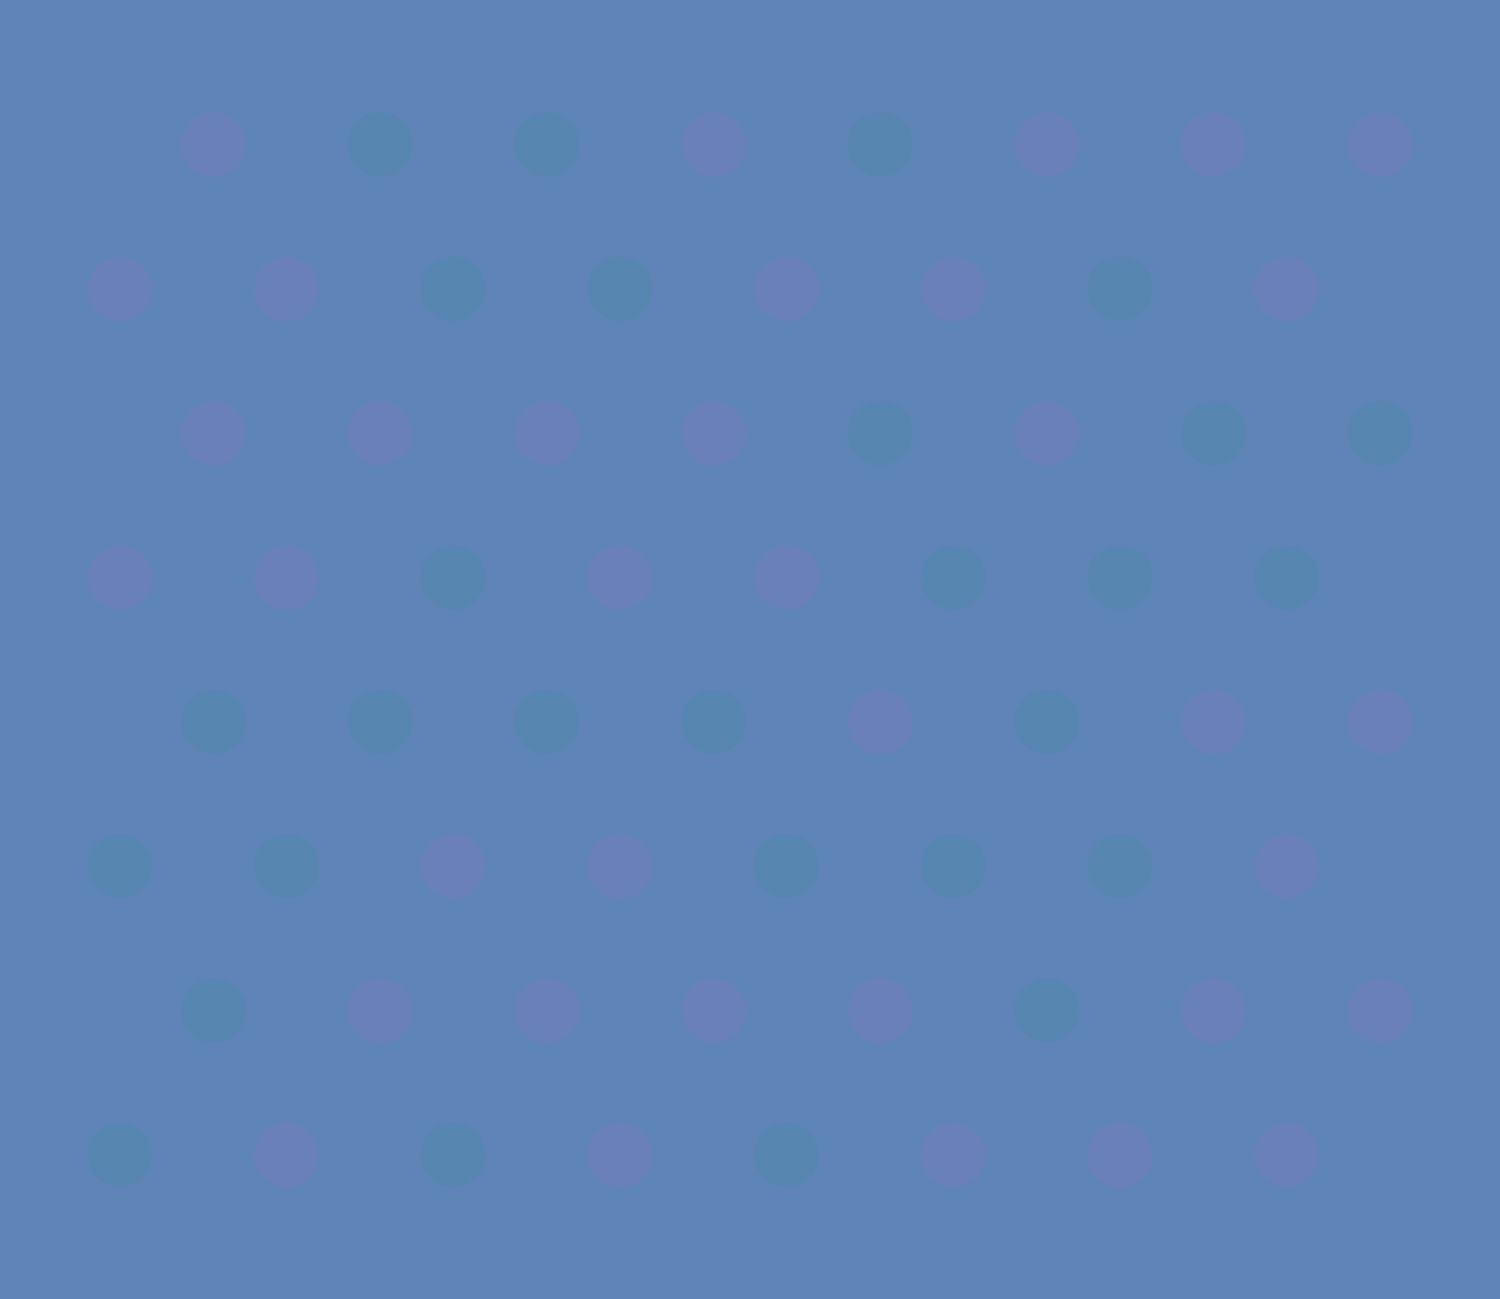

In [11]:
opts_ = opts.copy()
for alpha_ in np.linspace(0.1, 1., N_scan, endpoint=True): 
    opts_.update(alpha=alpha_)
    print(f'{alpha_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


## c_mean

c_mean_=0.00


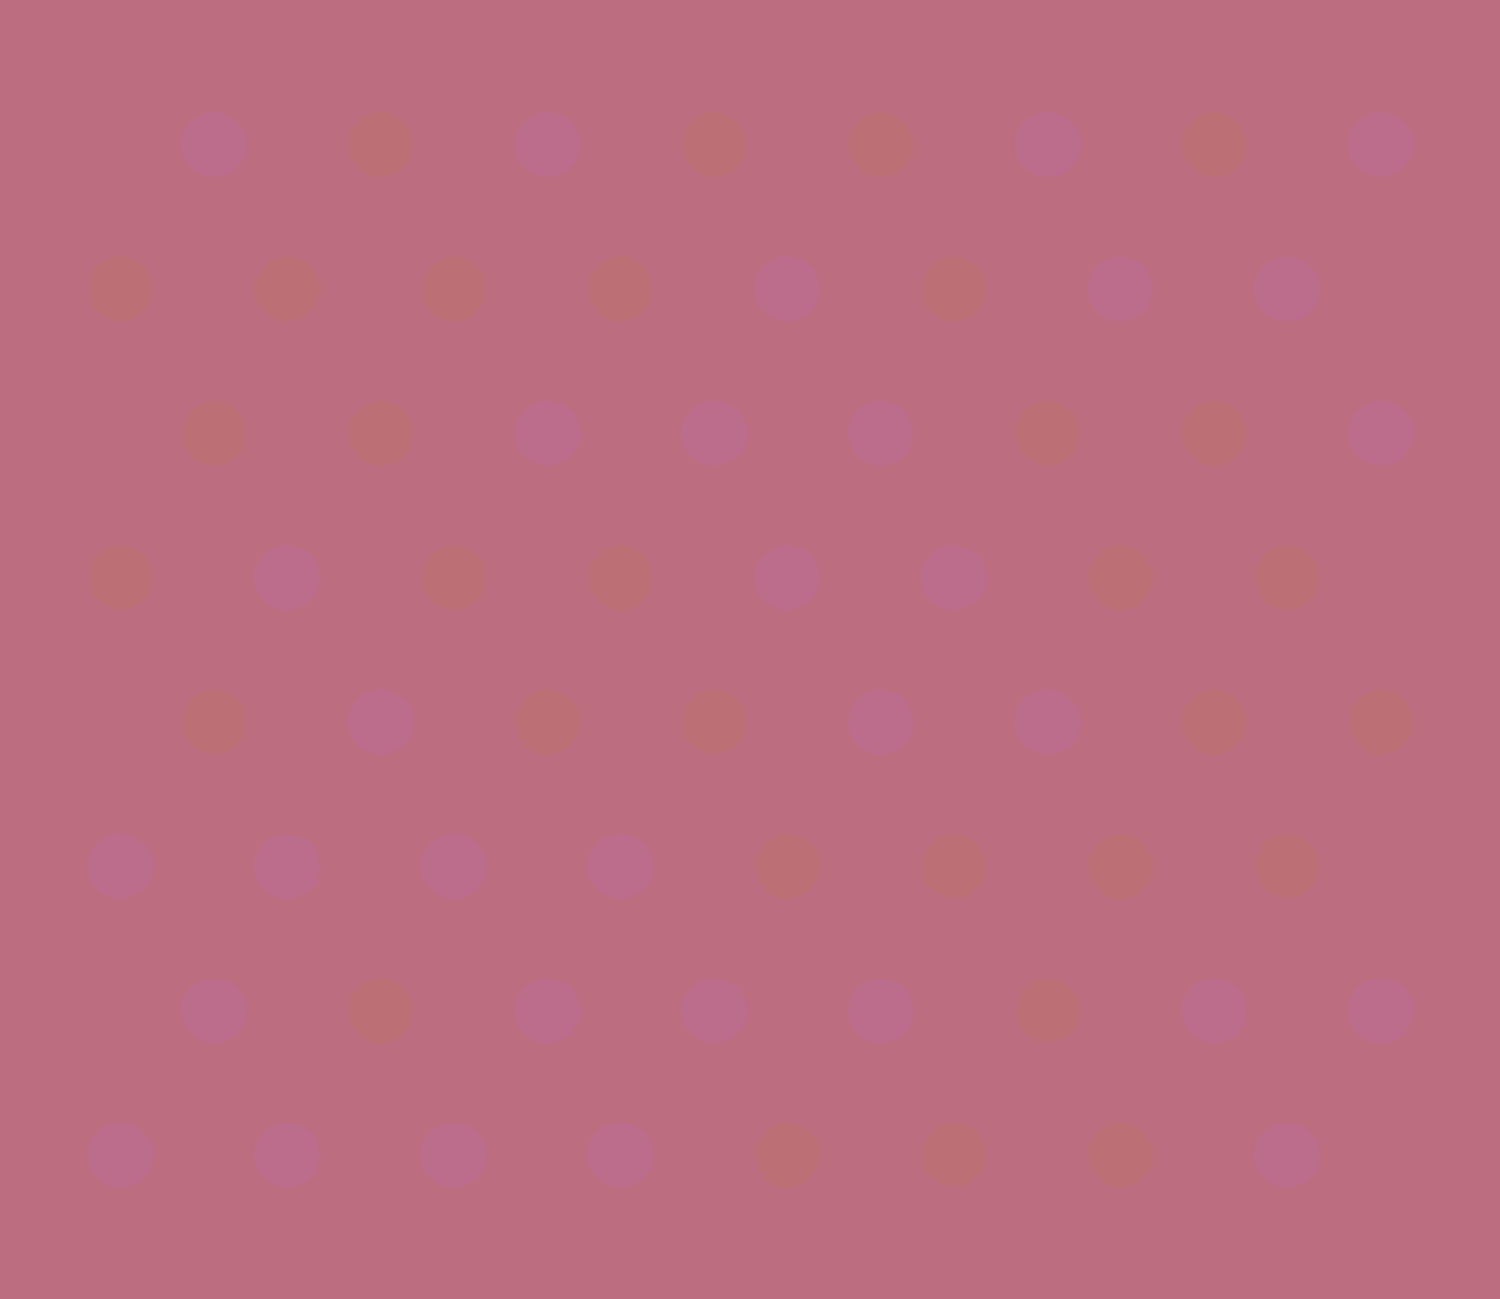

c_mean_=40.00


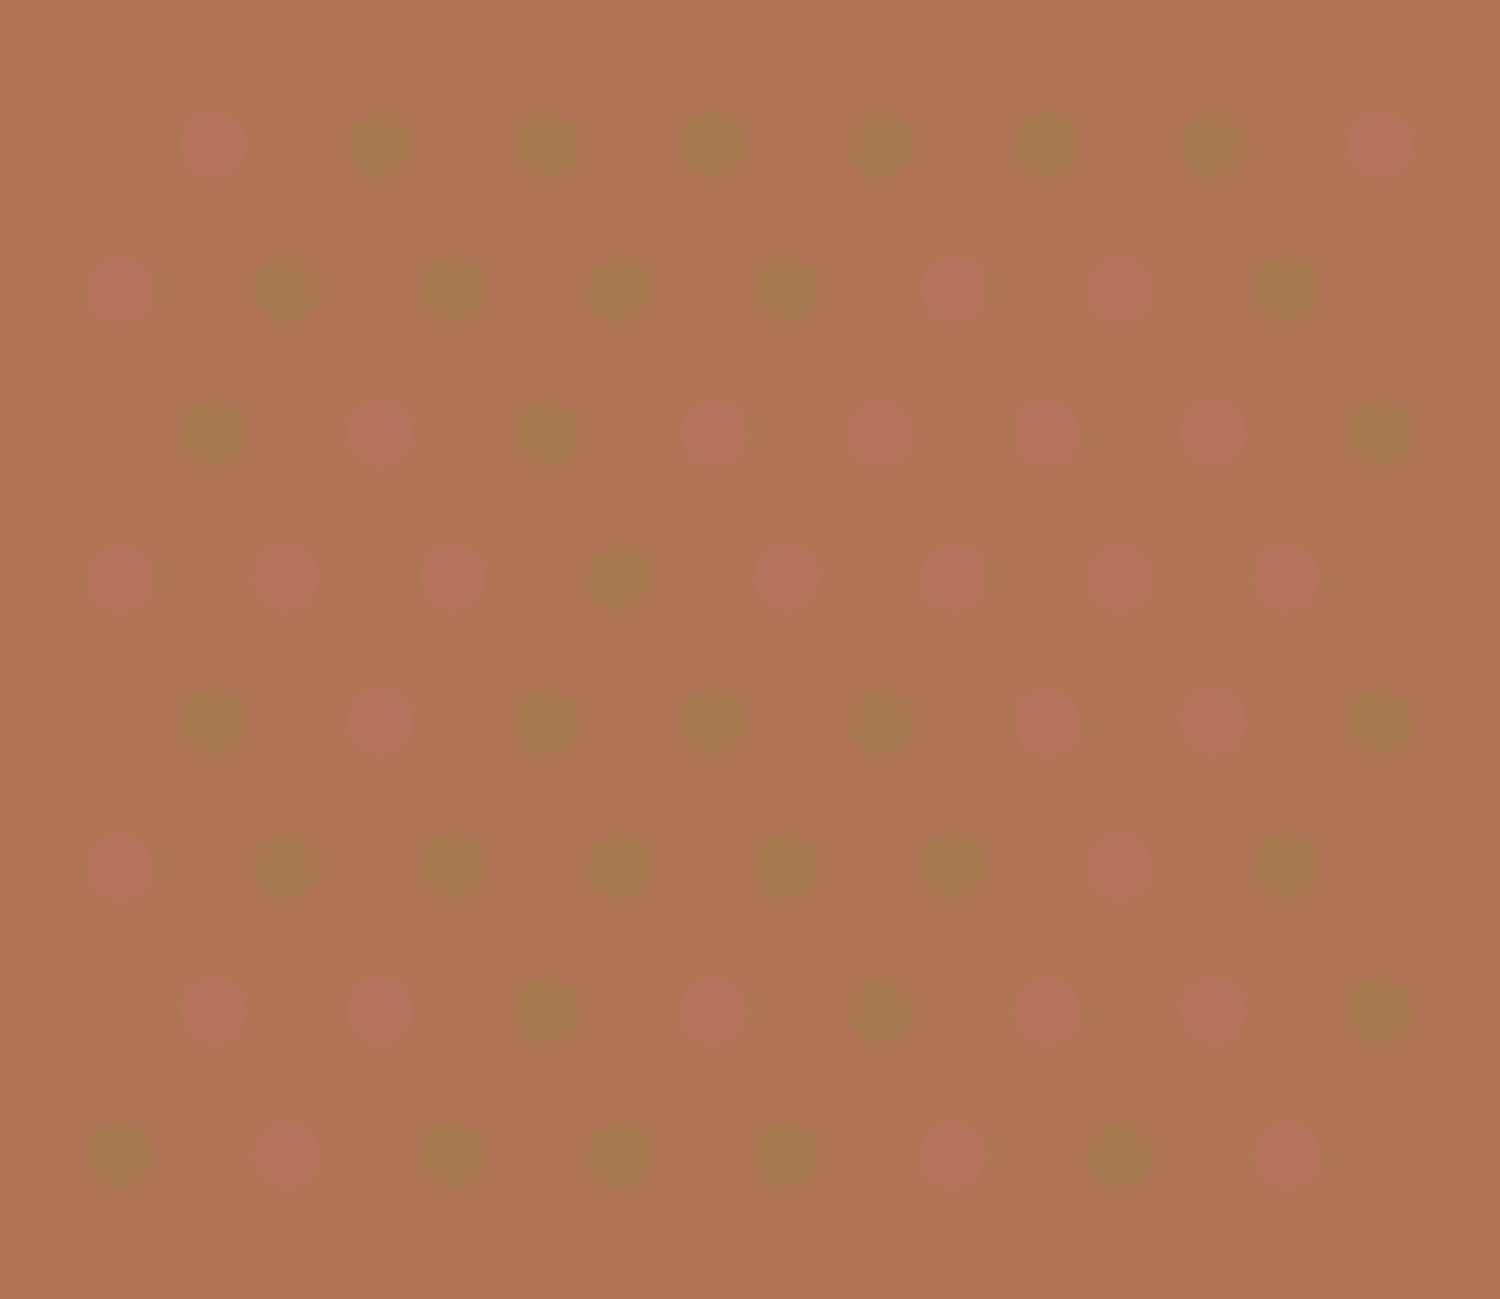

c_mean_=80.00


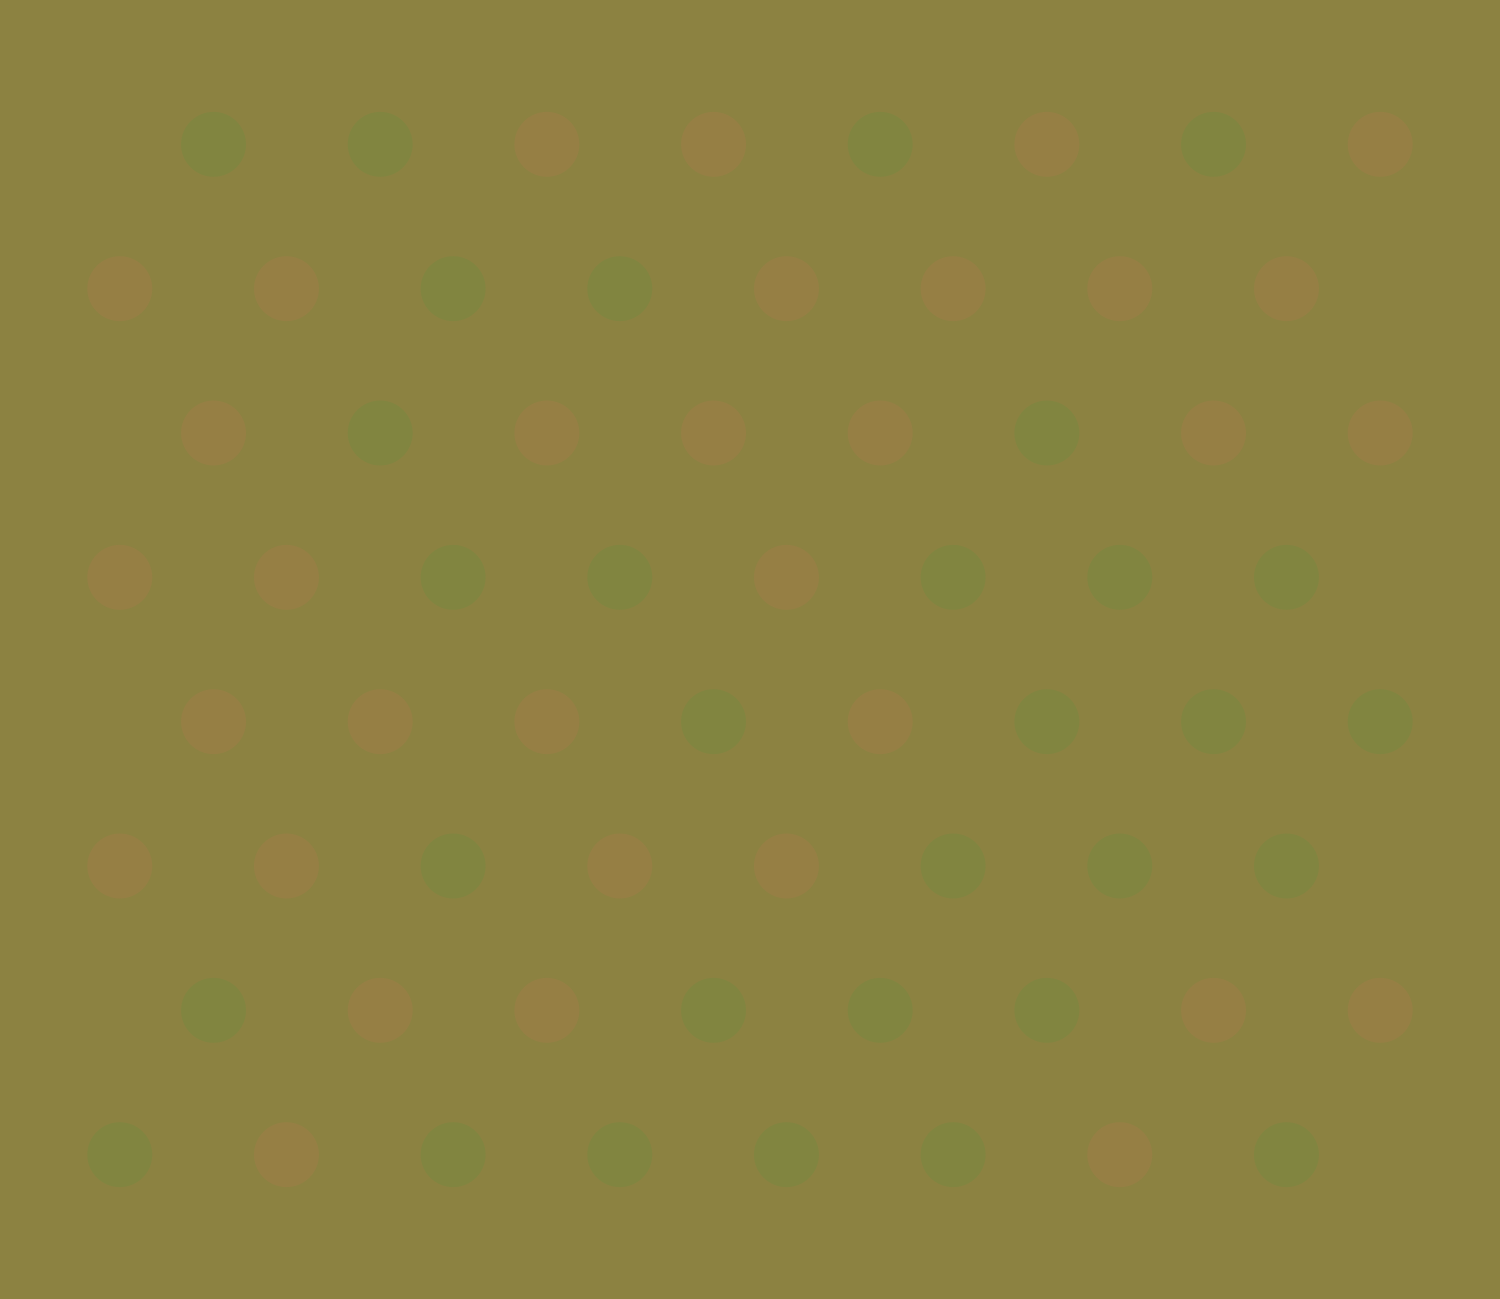

c_mean_=120.00


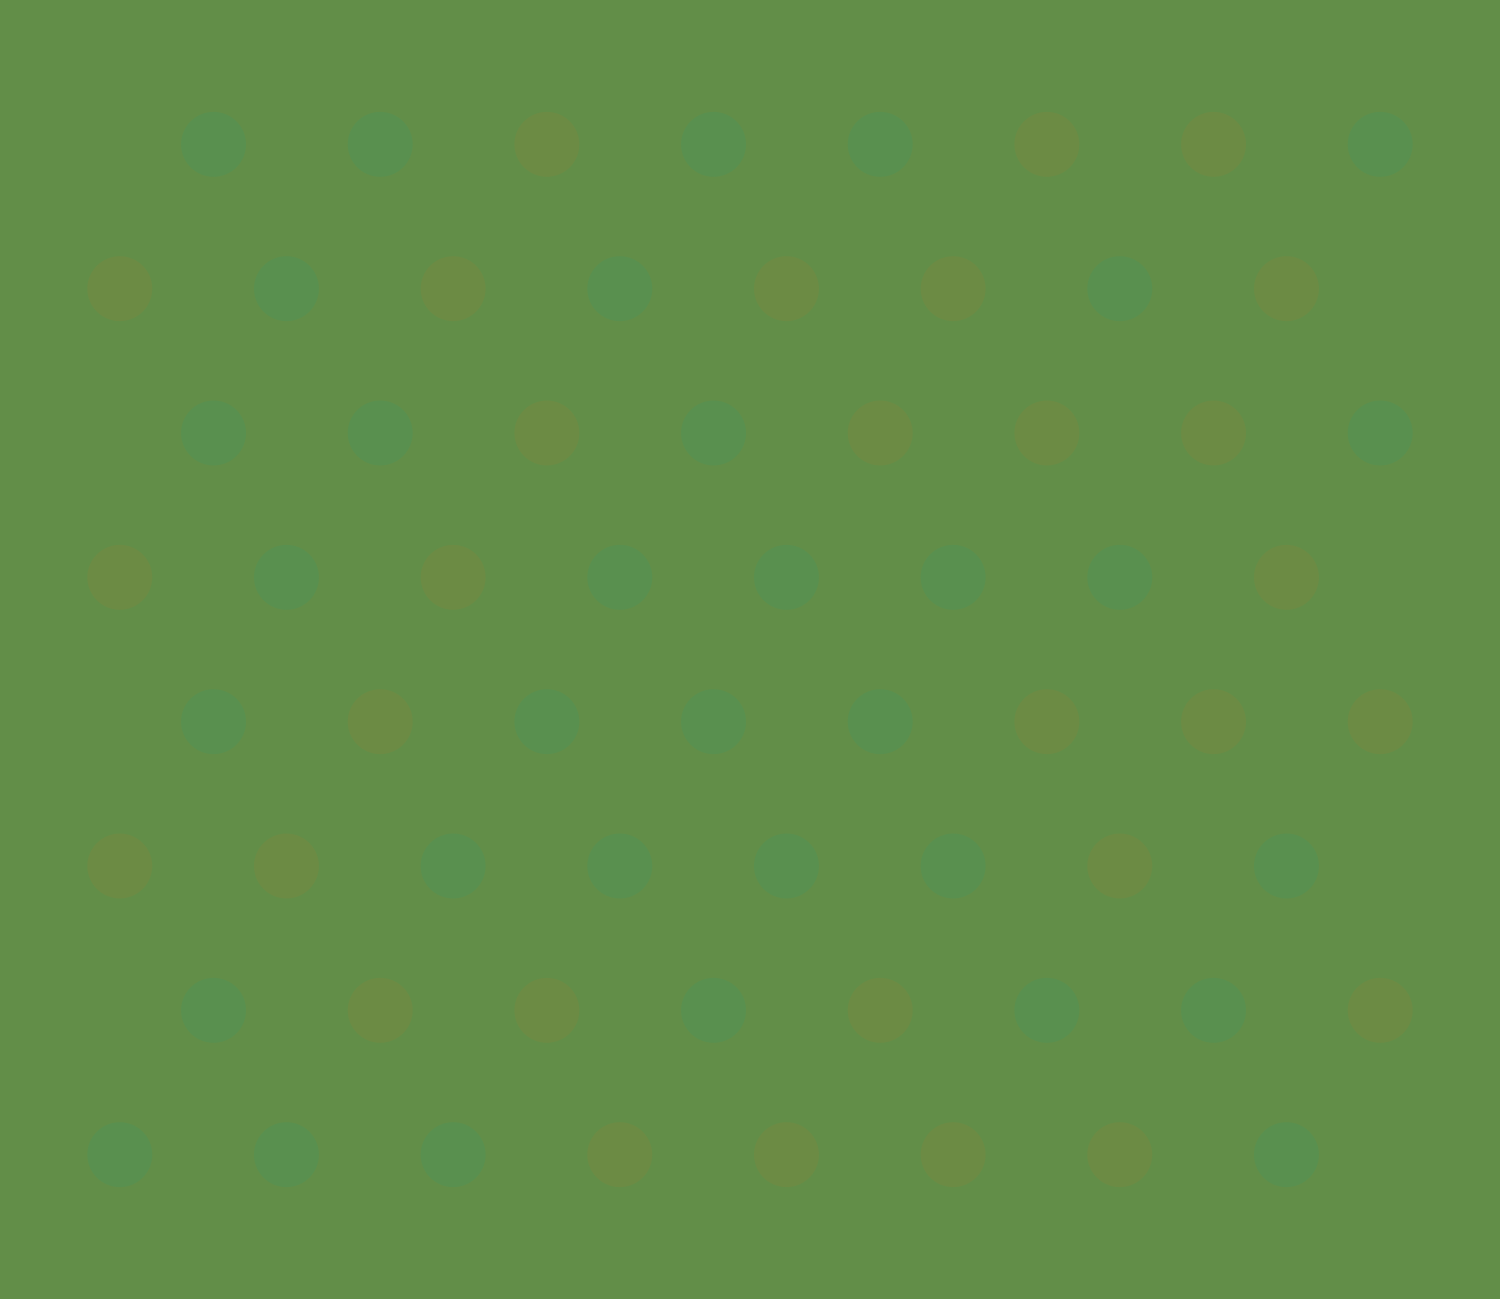

c_mean_=160.00


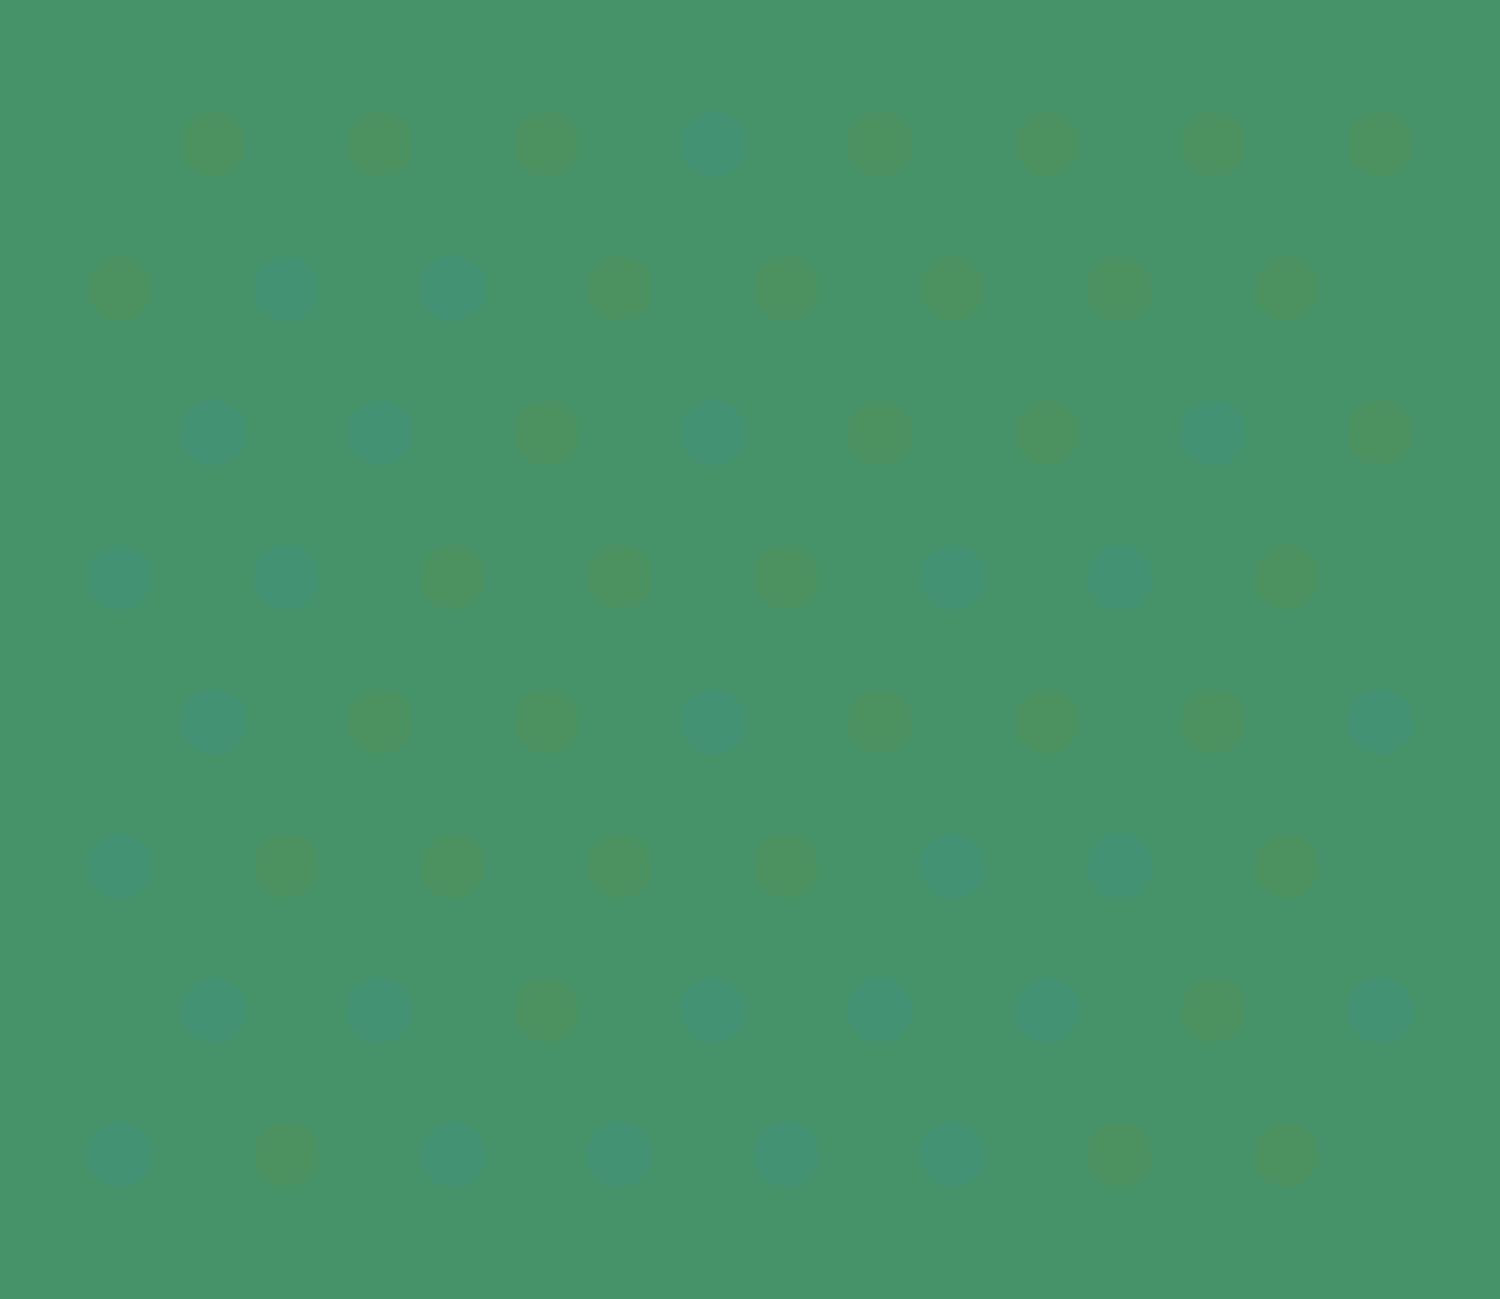

c_mean_=200.00


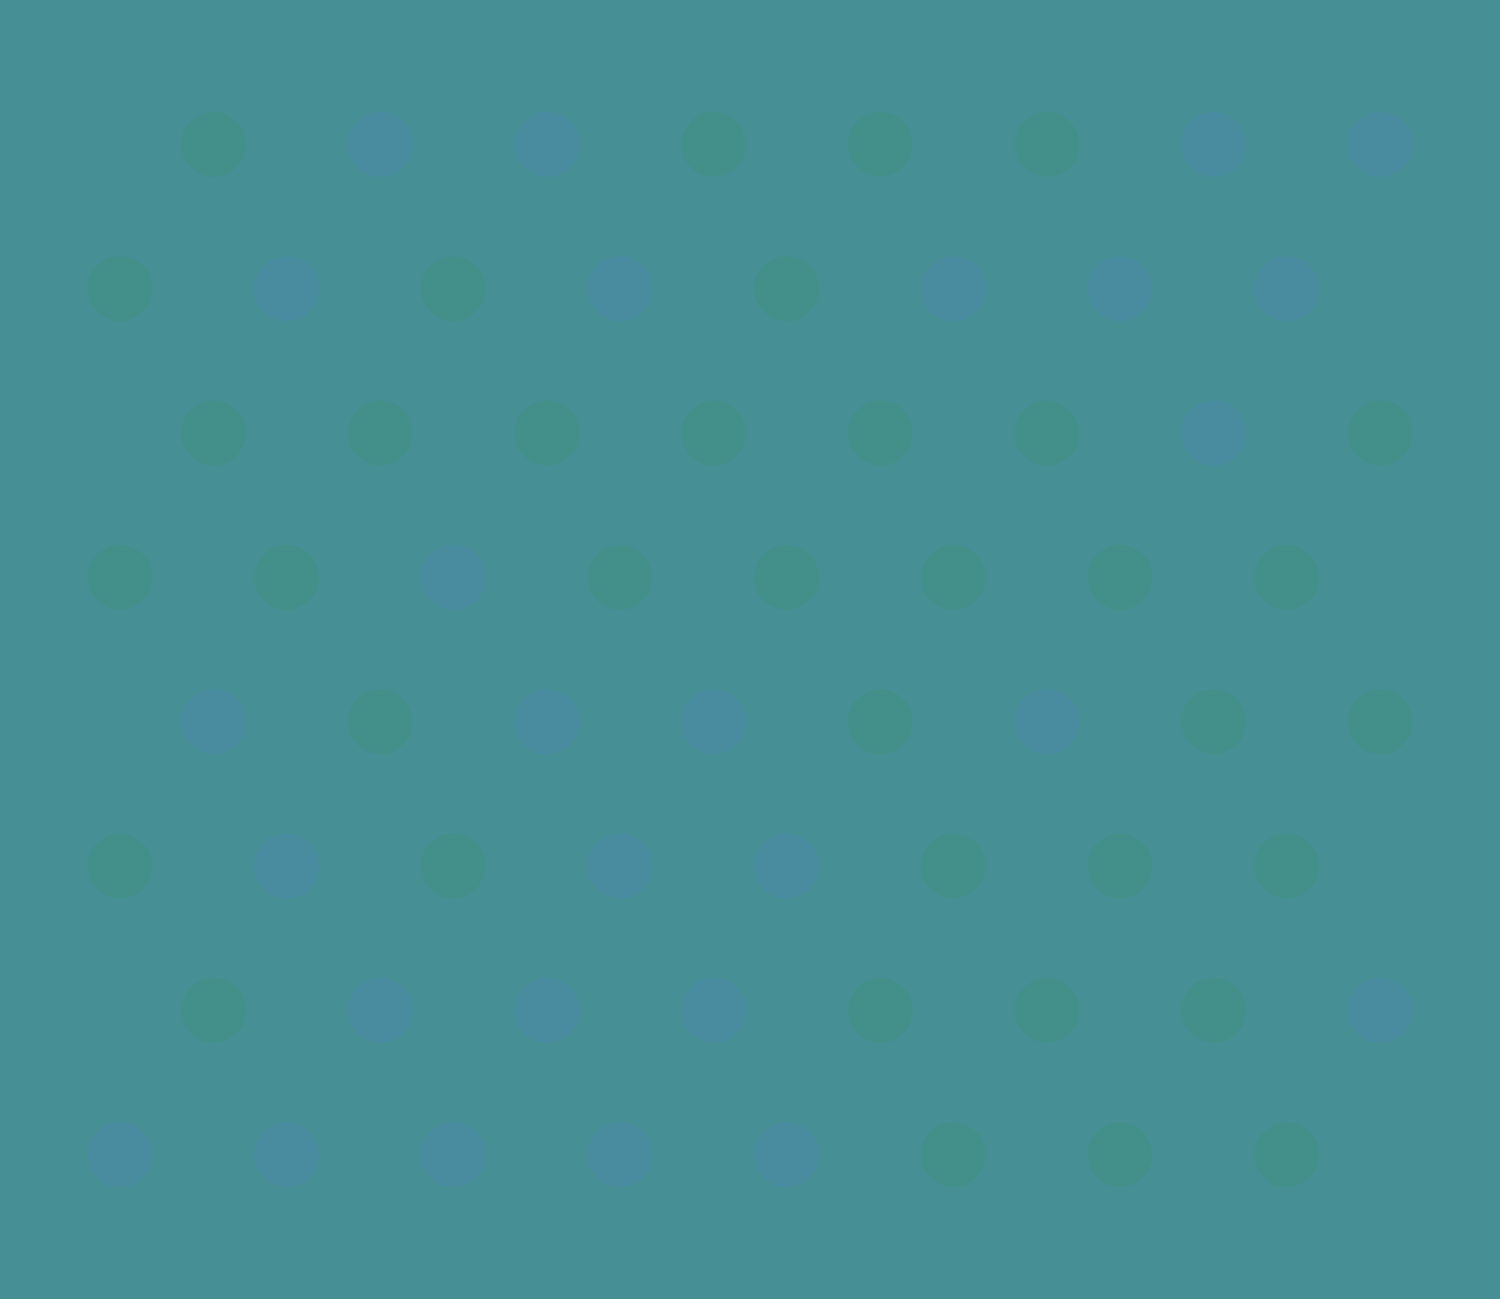

c_mean_=240.00


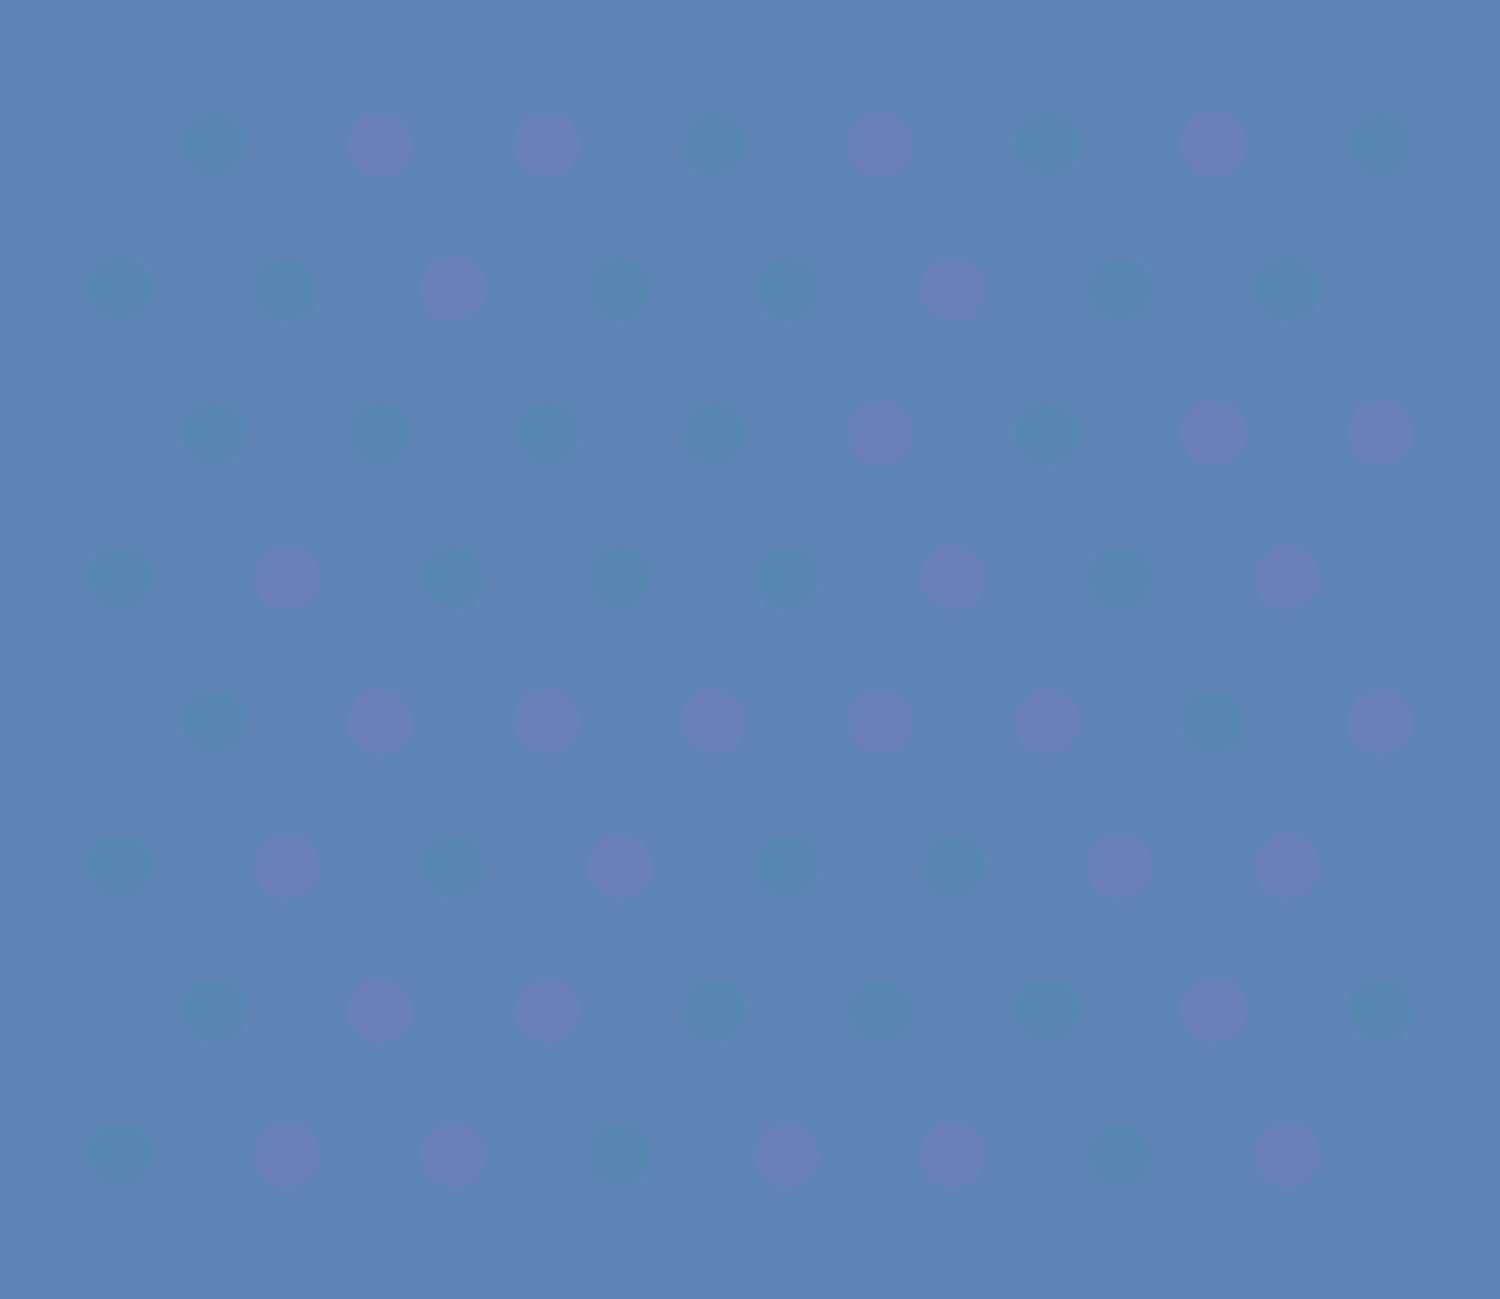

c_mean_=280.00


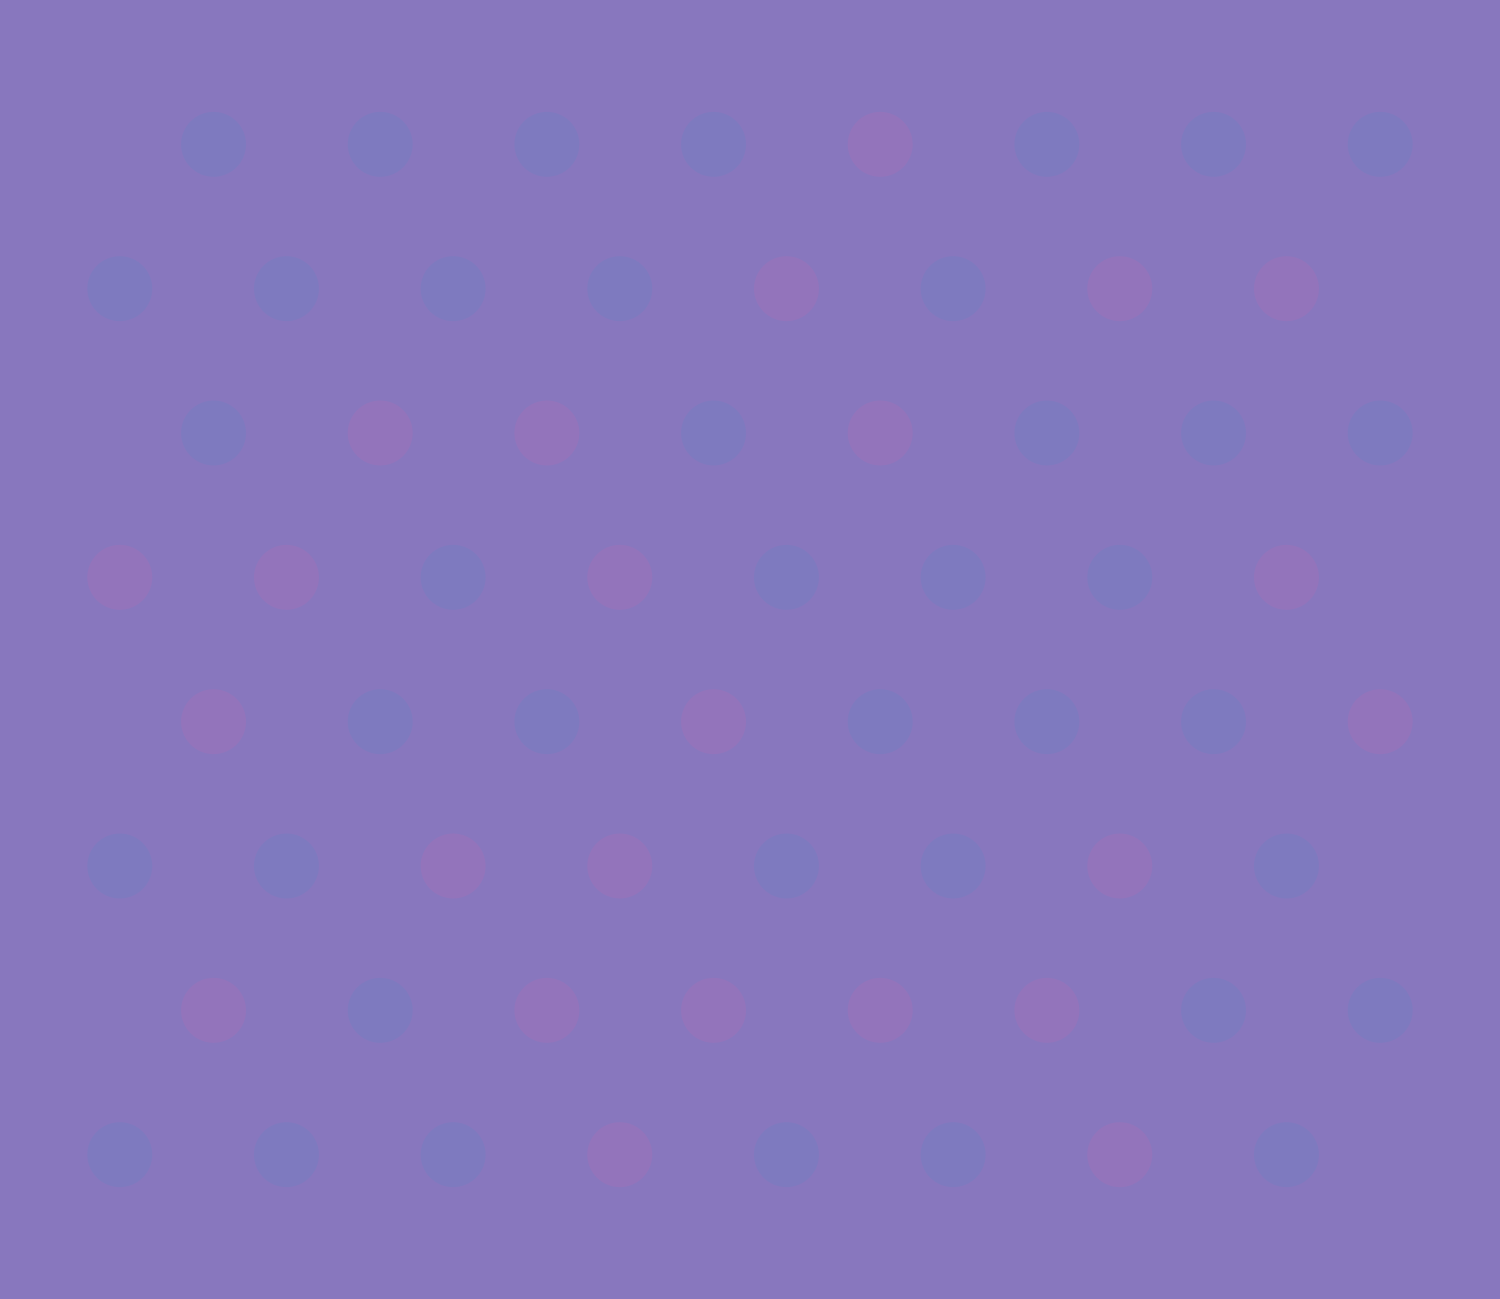

c_mean_=320.00


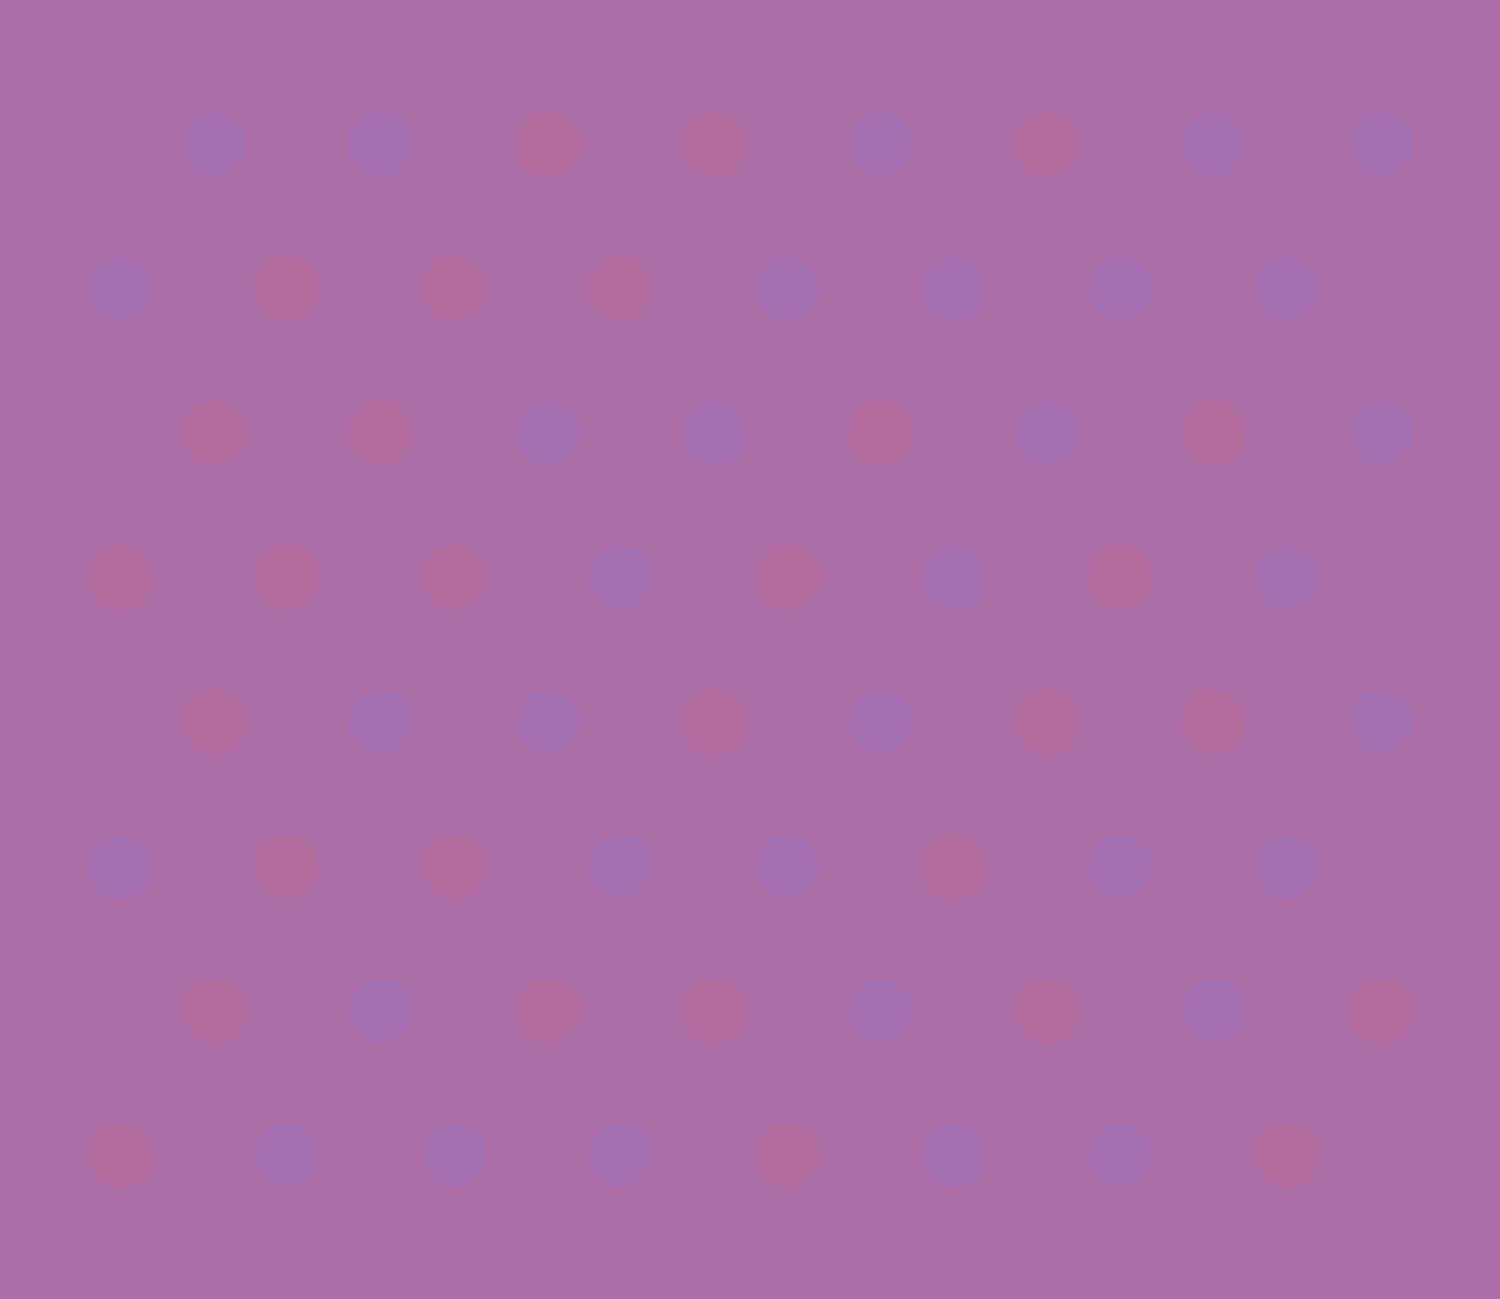

In [12]:
opts_ = opts.copy()
for c_mean_ in np.linspace(0., 360., N_scan, endpoint=False): 
    opts_.update(c_mean=c_mean_, c_std=c_std)
    print(f'{c_mean_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


## color around blue

c_std=0.00e+00


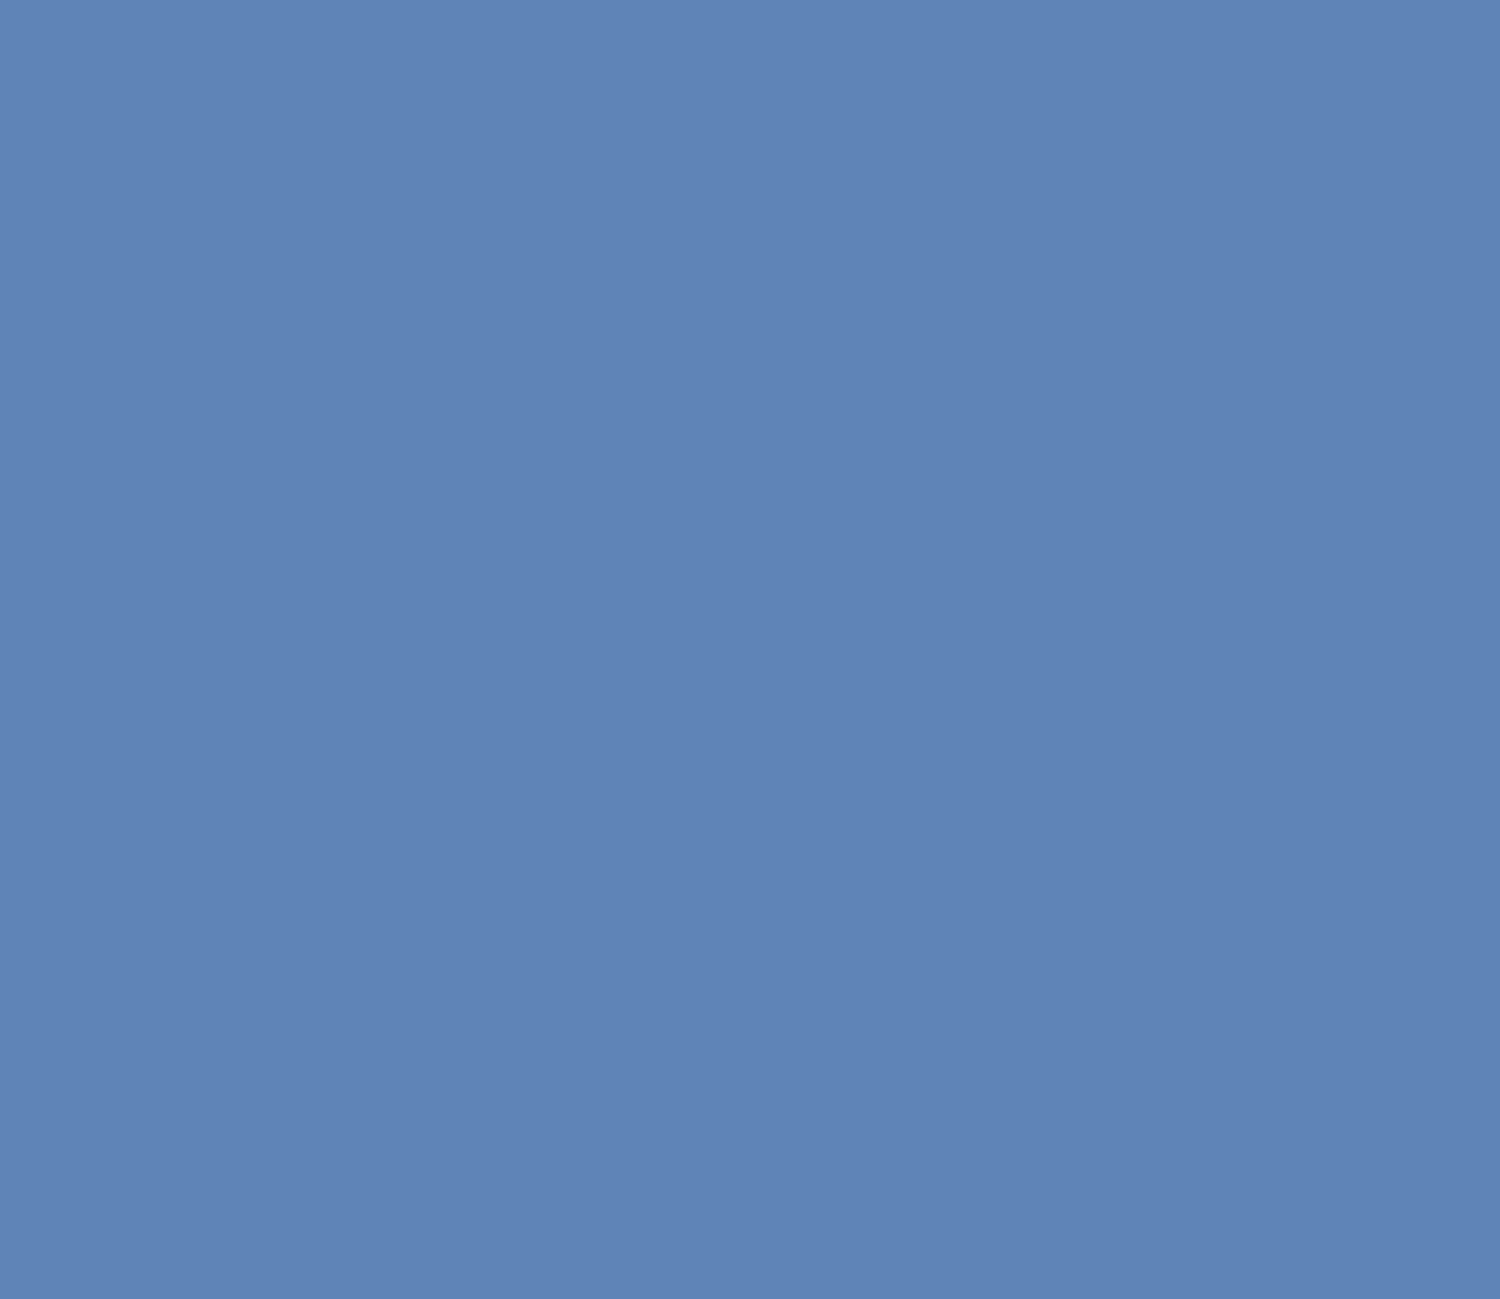

c_std=3.33e+00


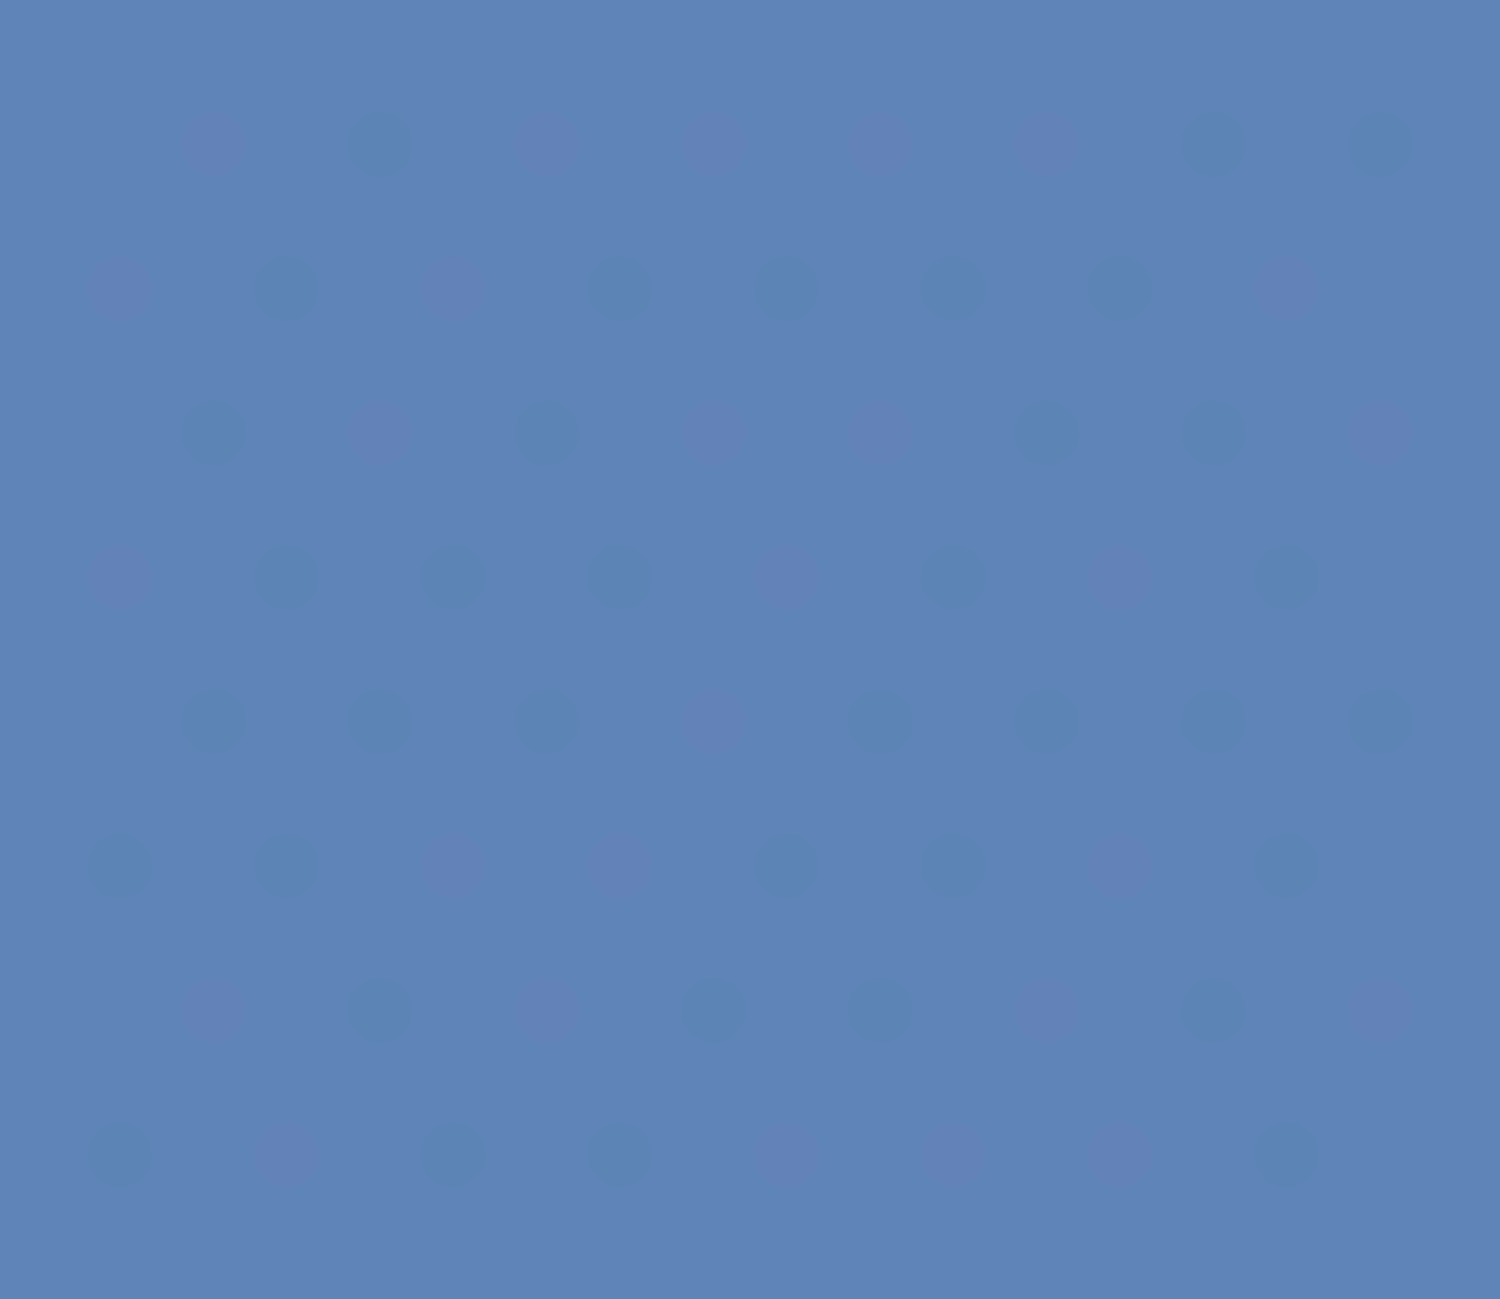

c_std=6.67e+00


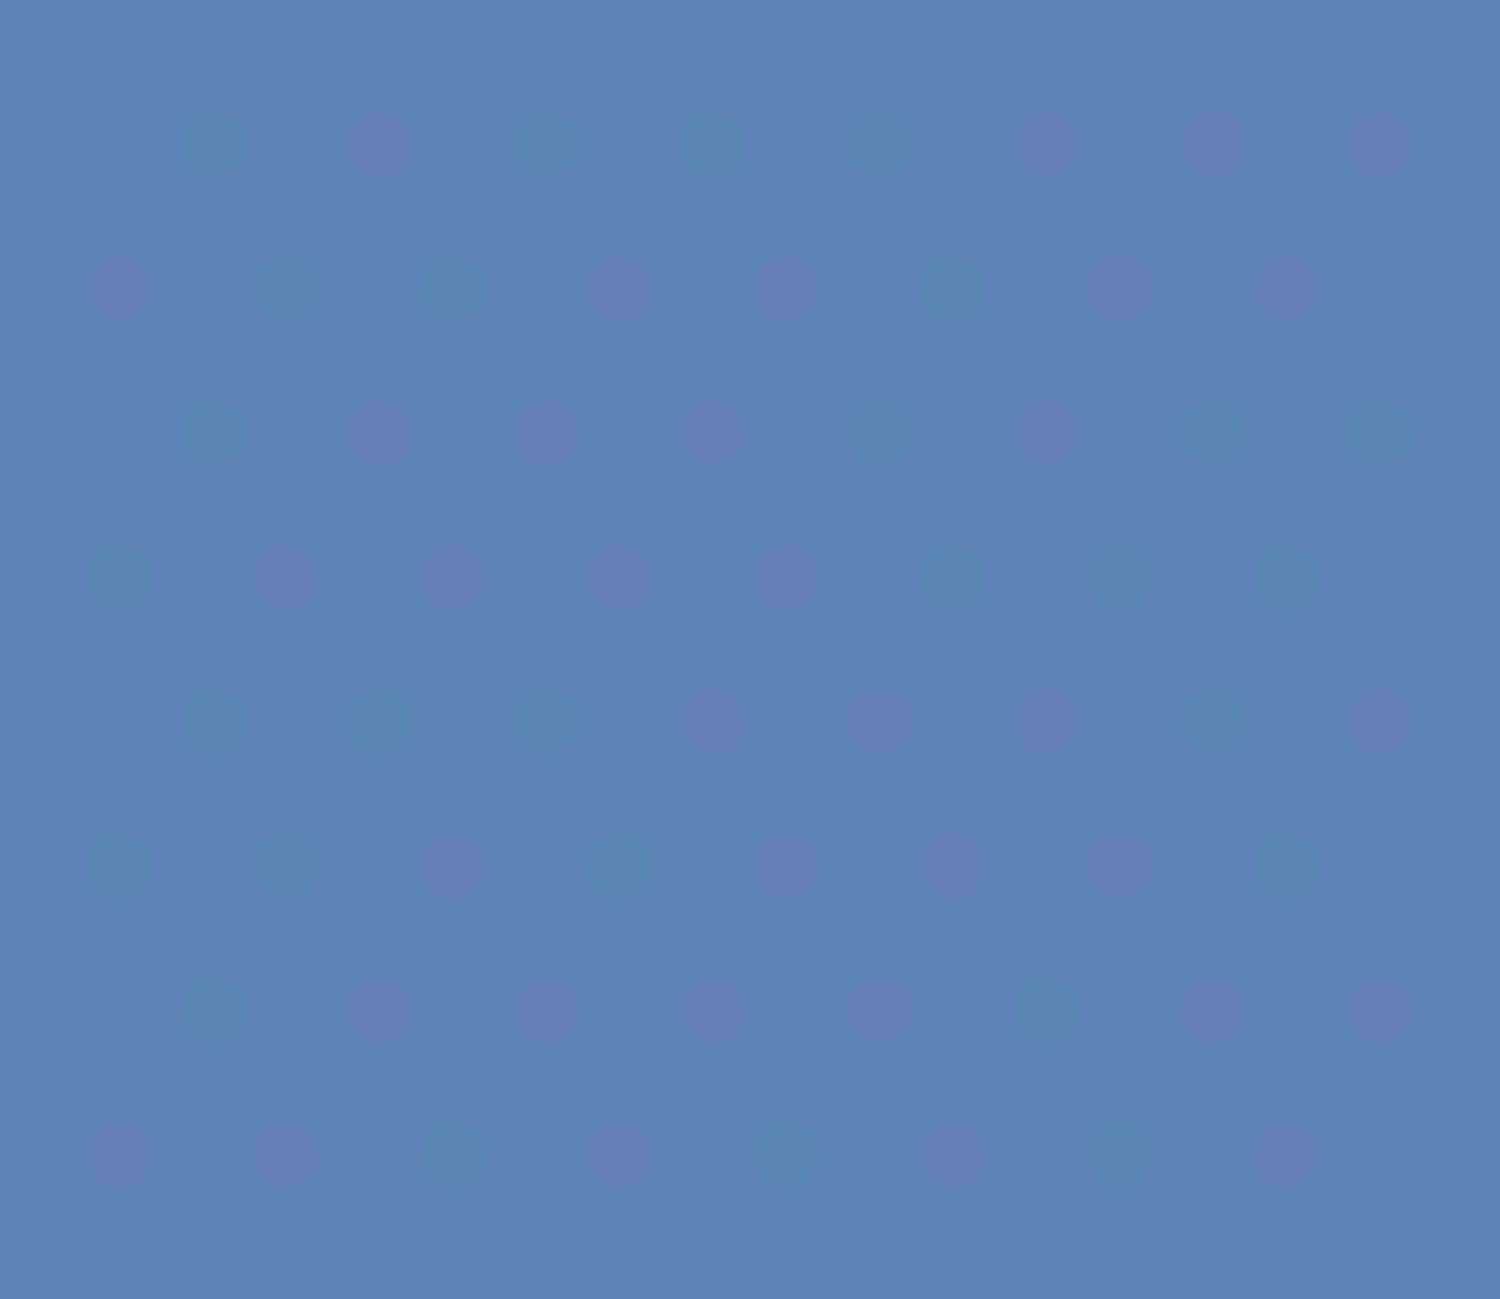

c_std=1.00e+01


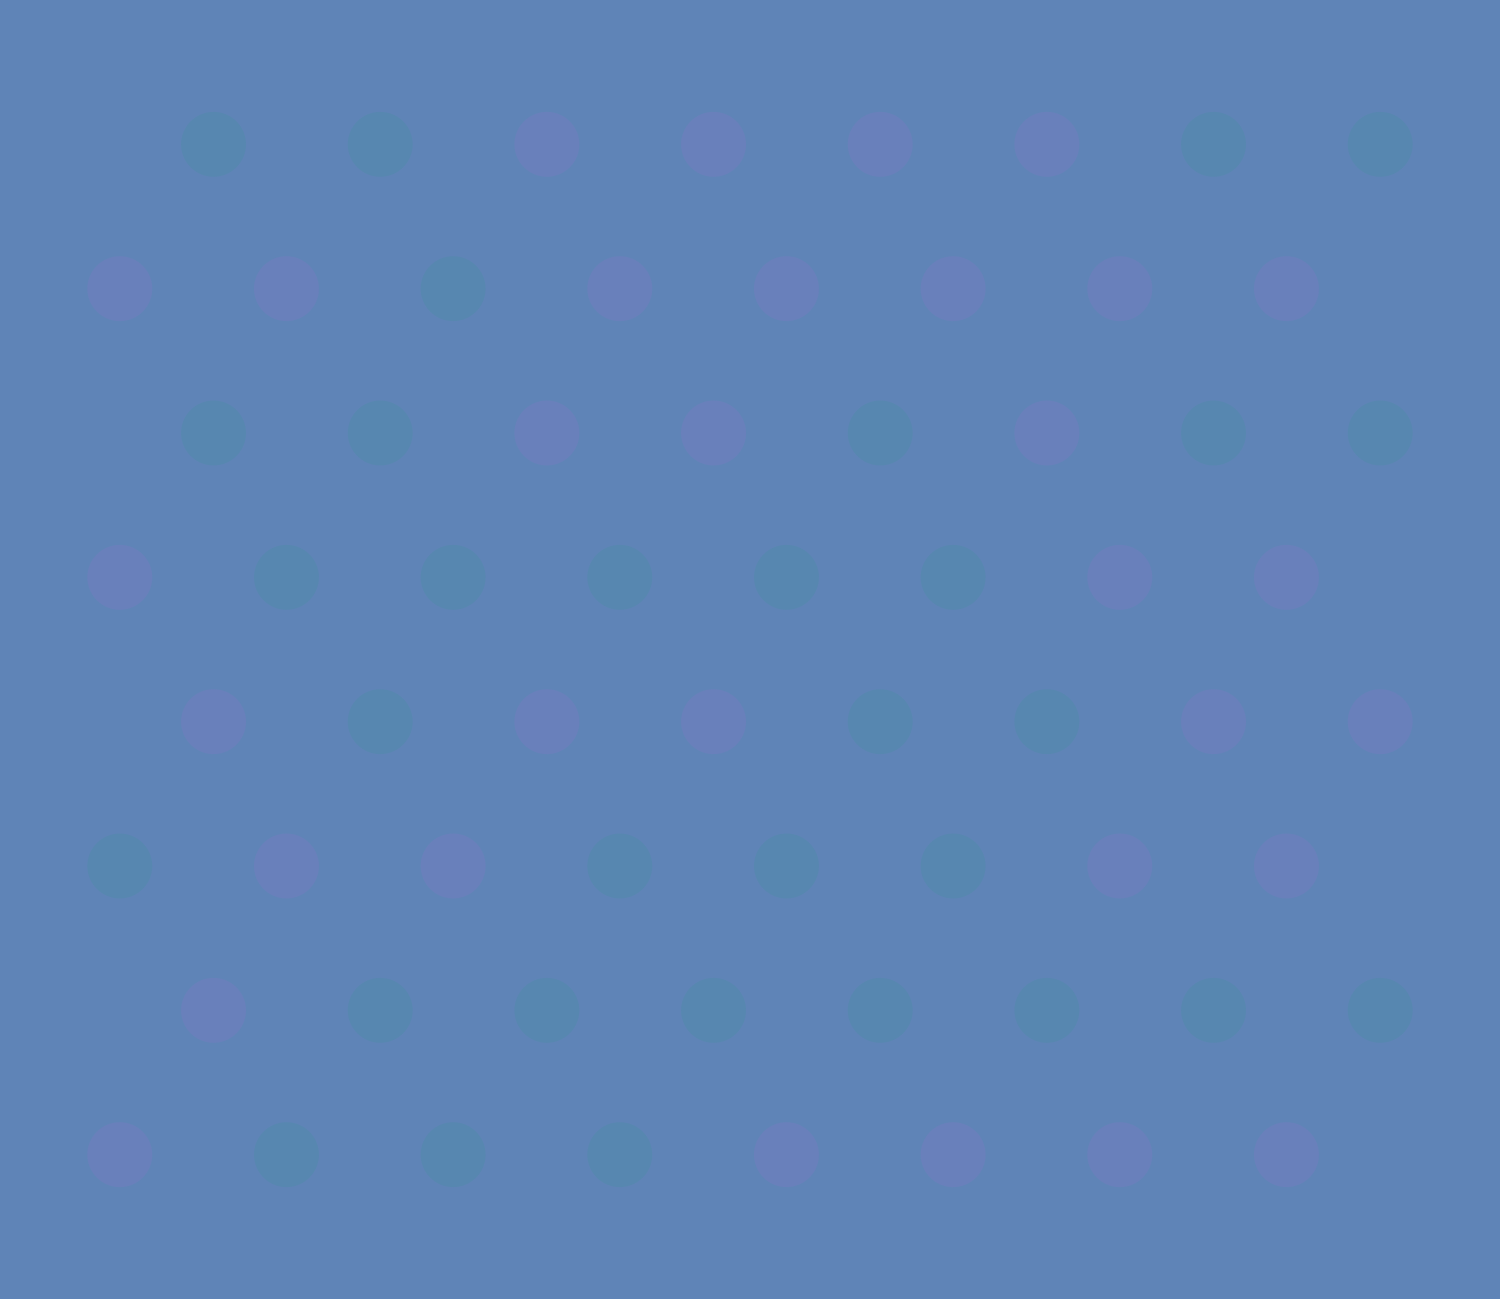

c_std=1.33e+01


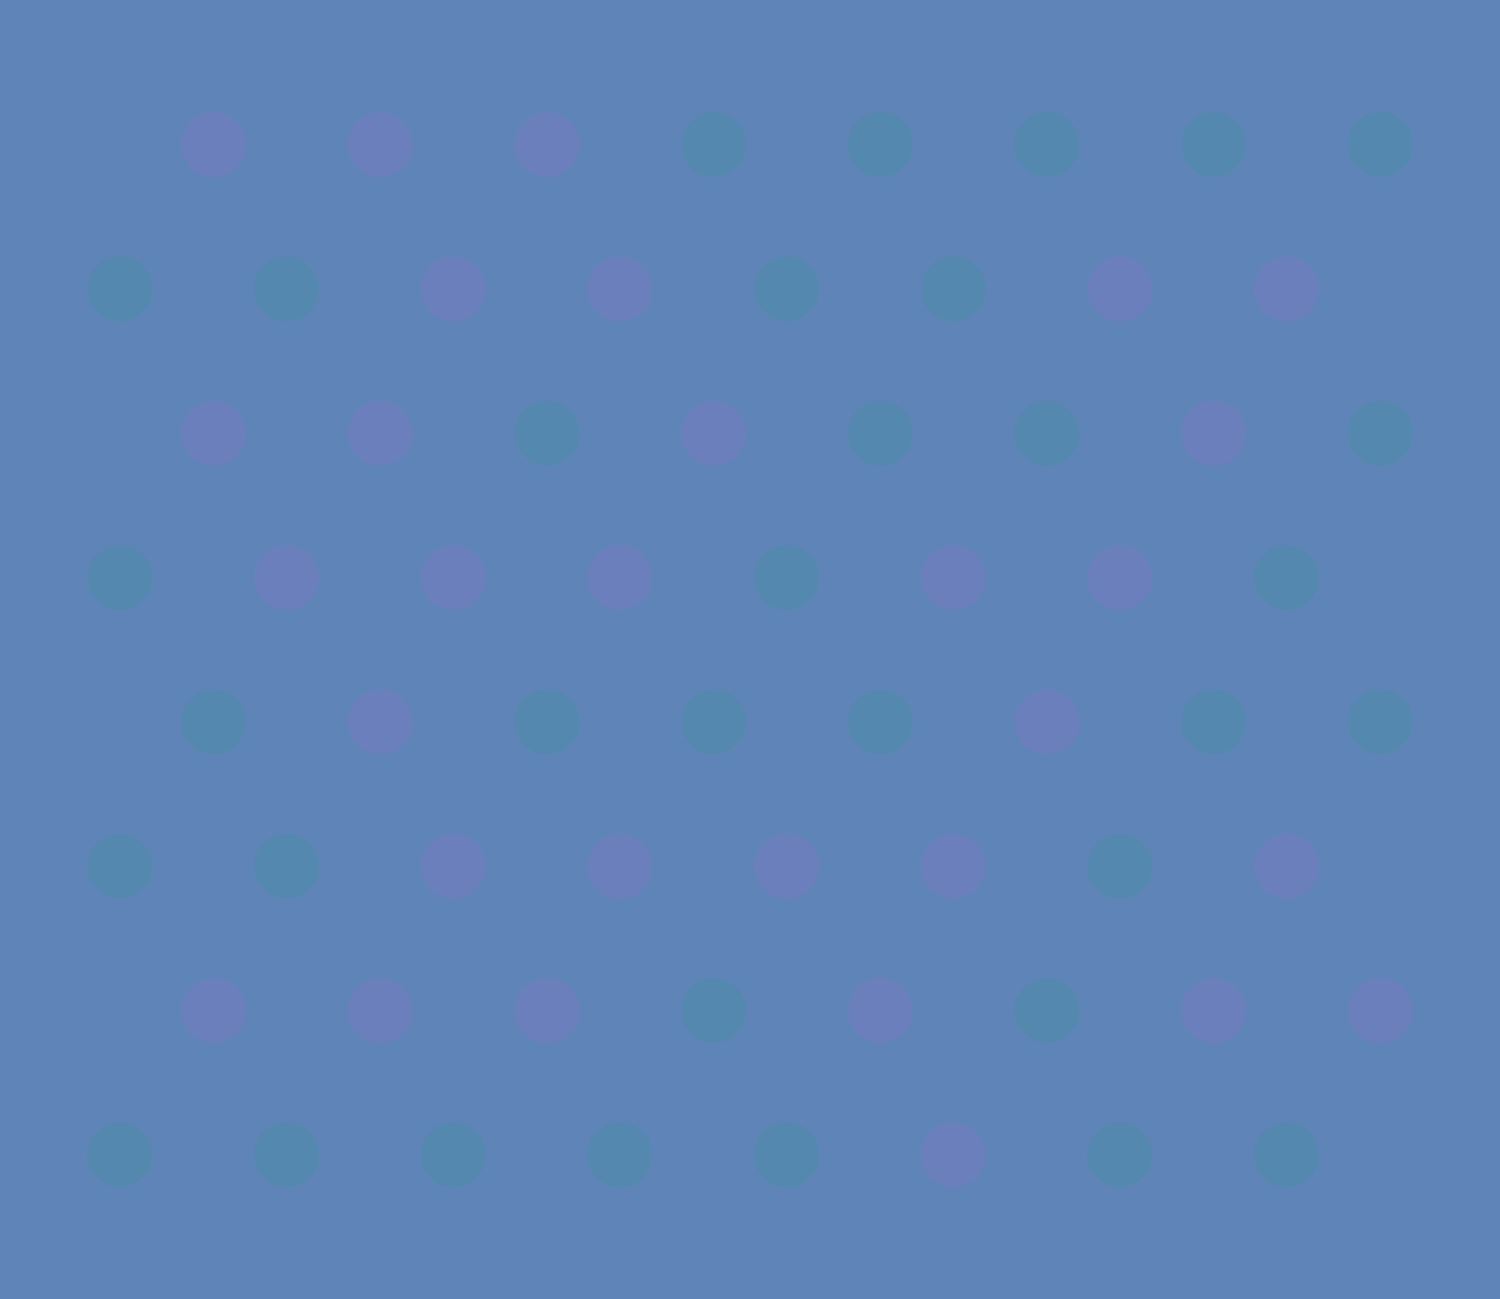

c_std=1.67e+01


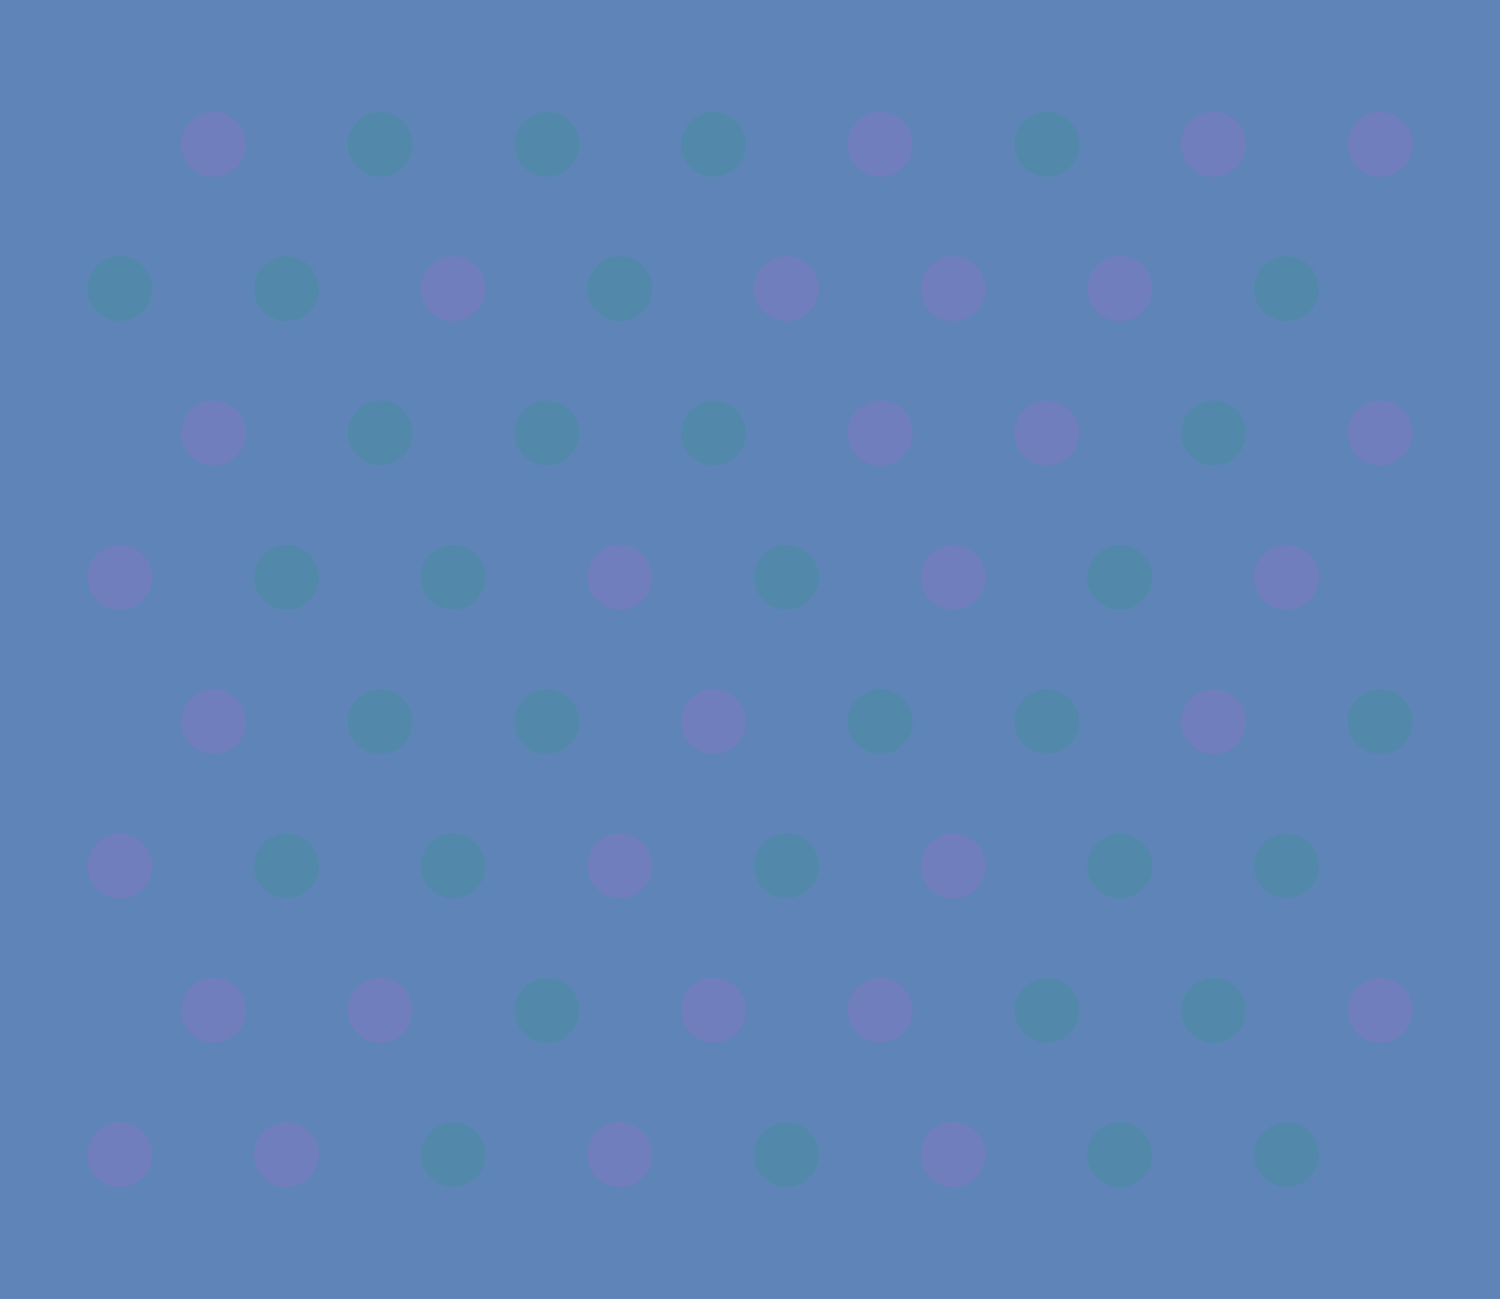

c_std=2.00e+01


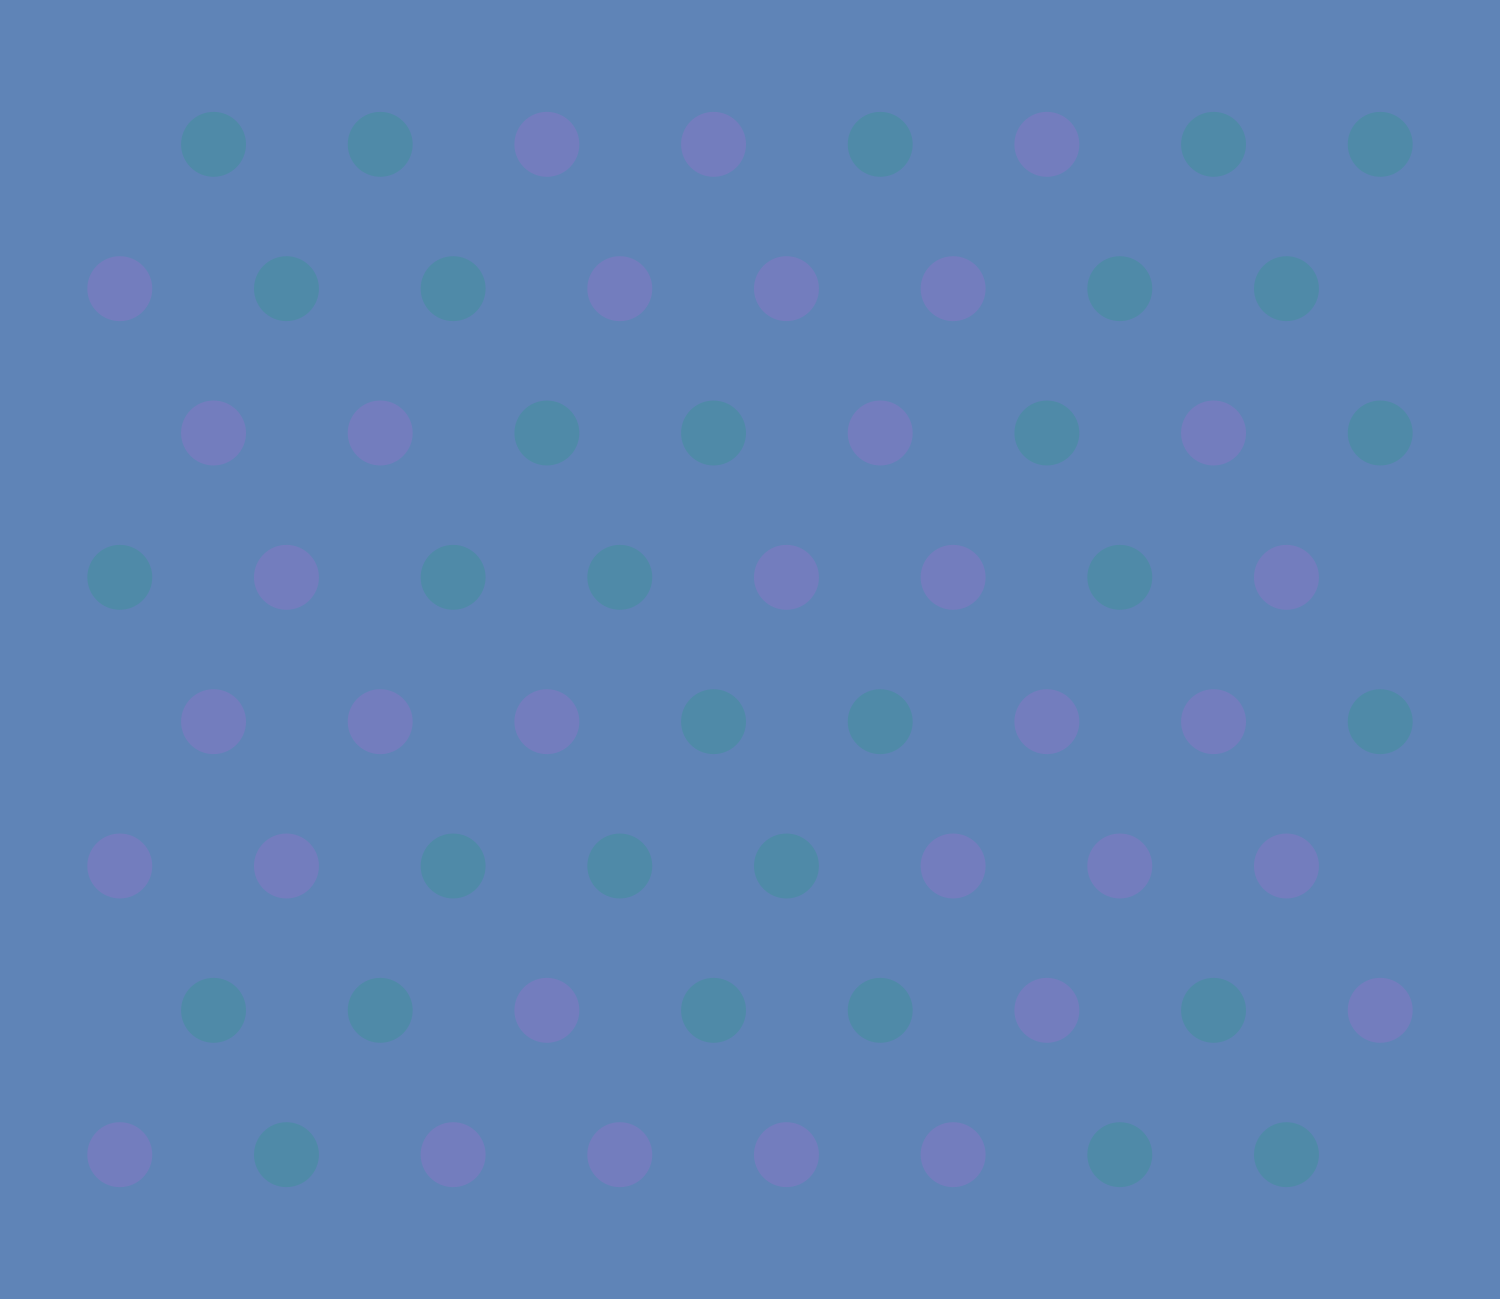

c_std=2.33e+01


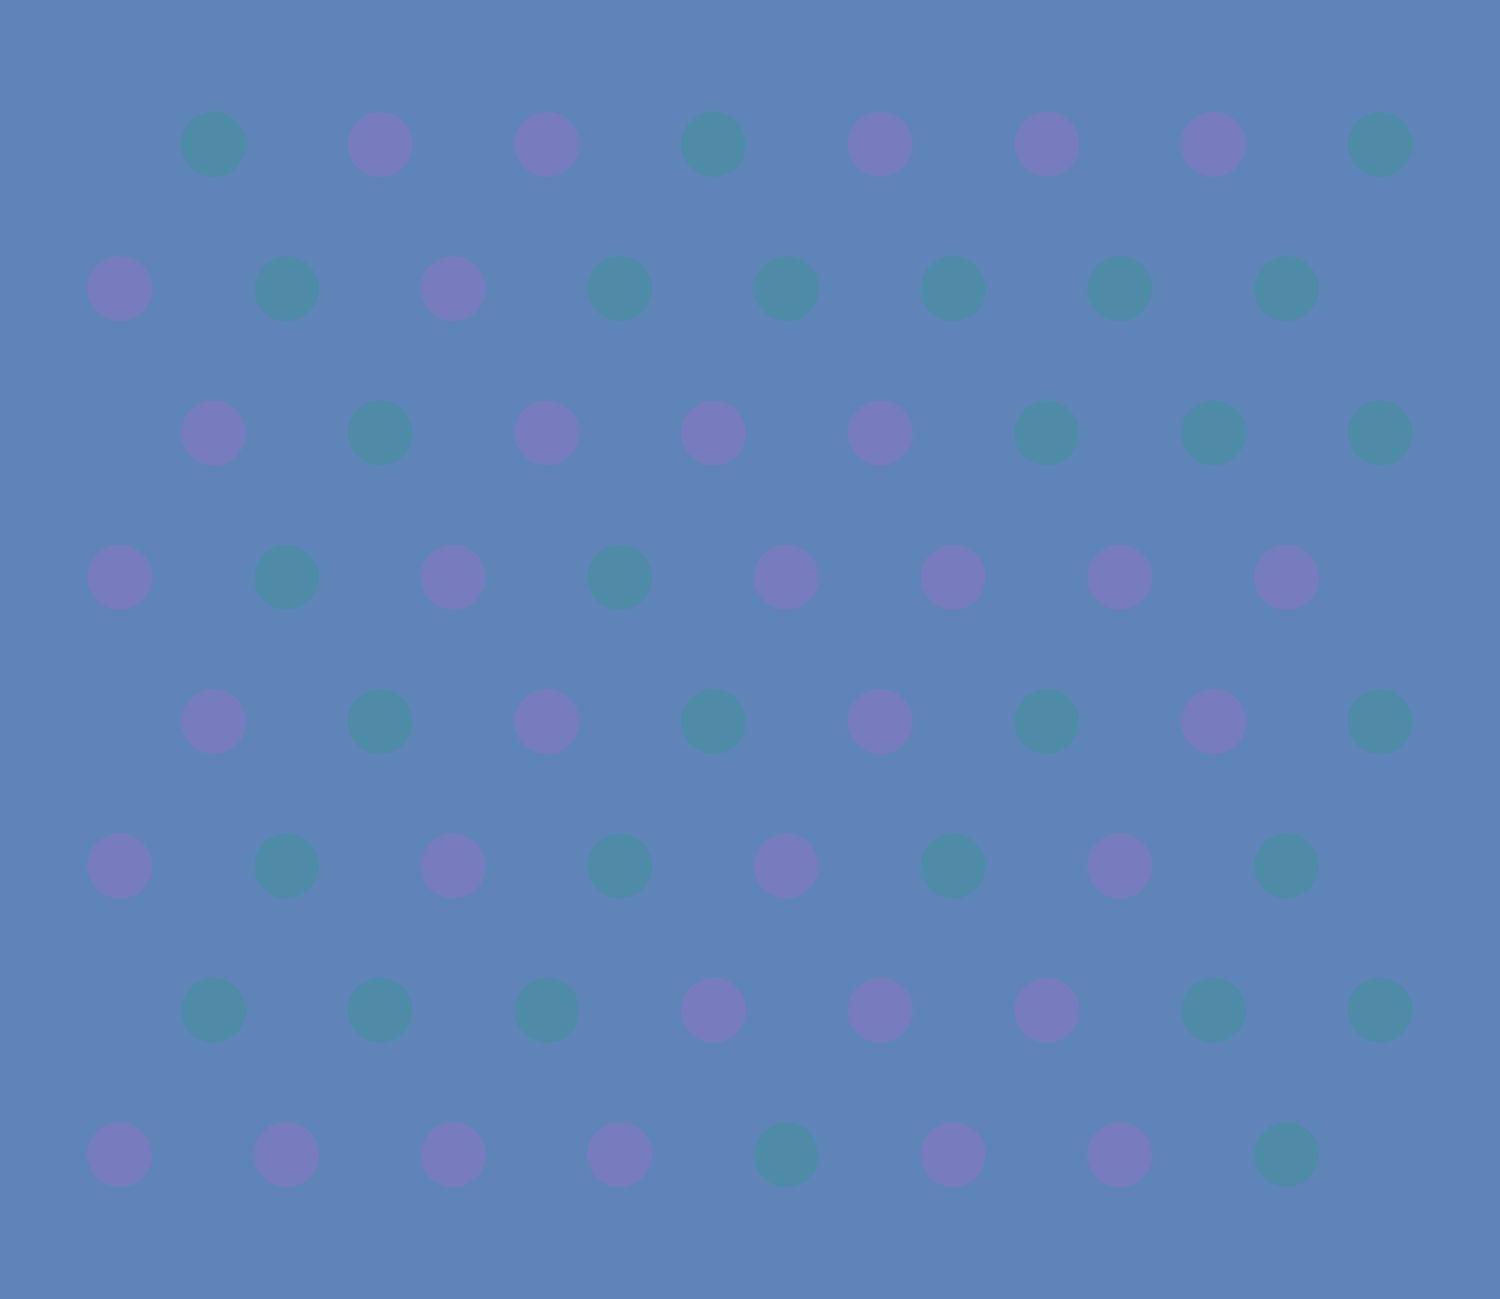

c_std=2.67e+01


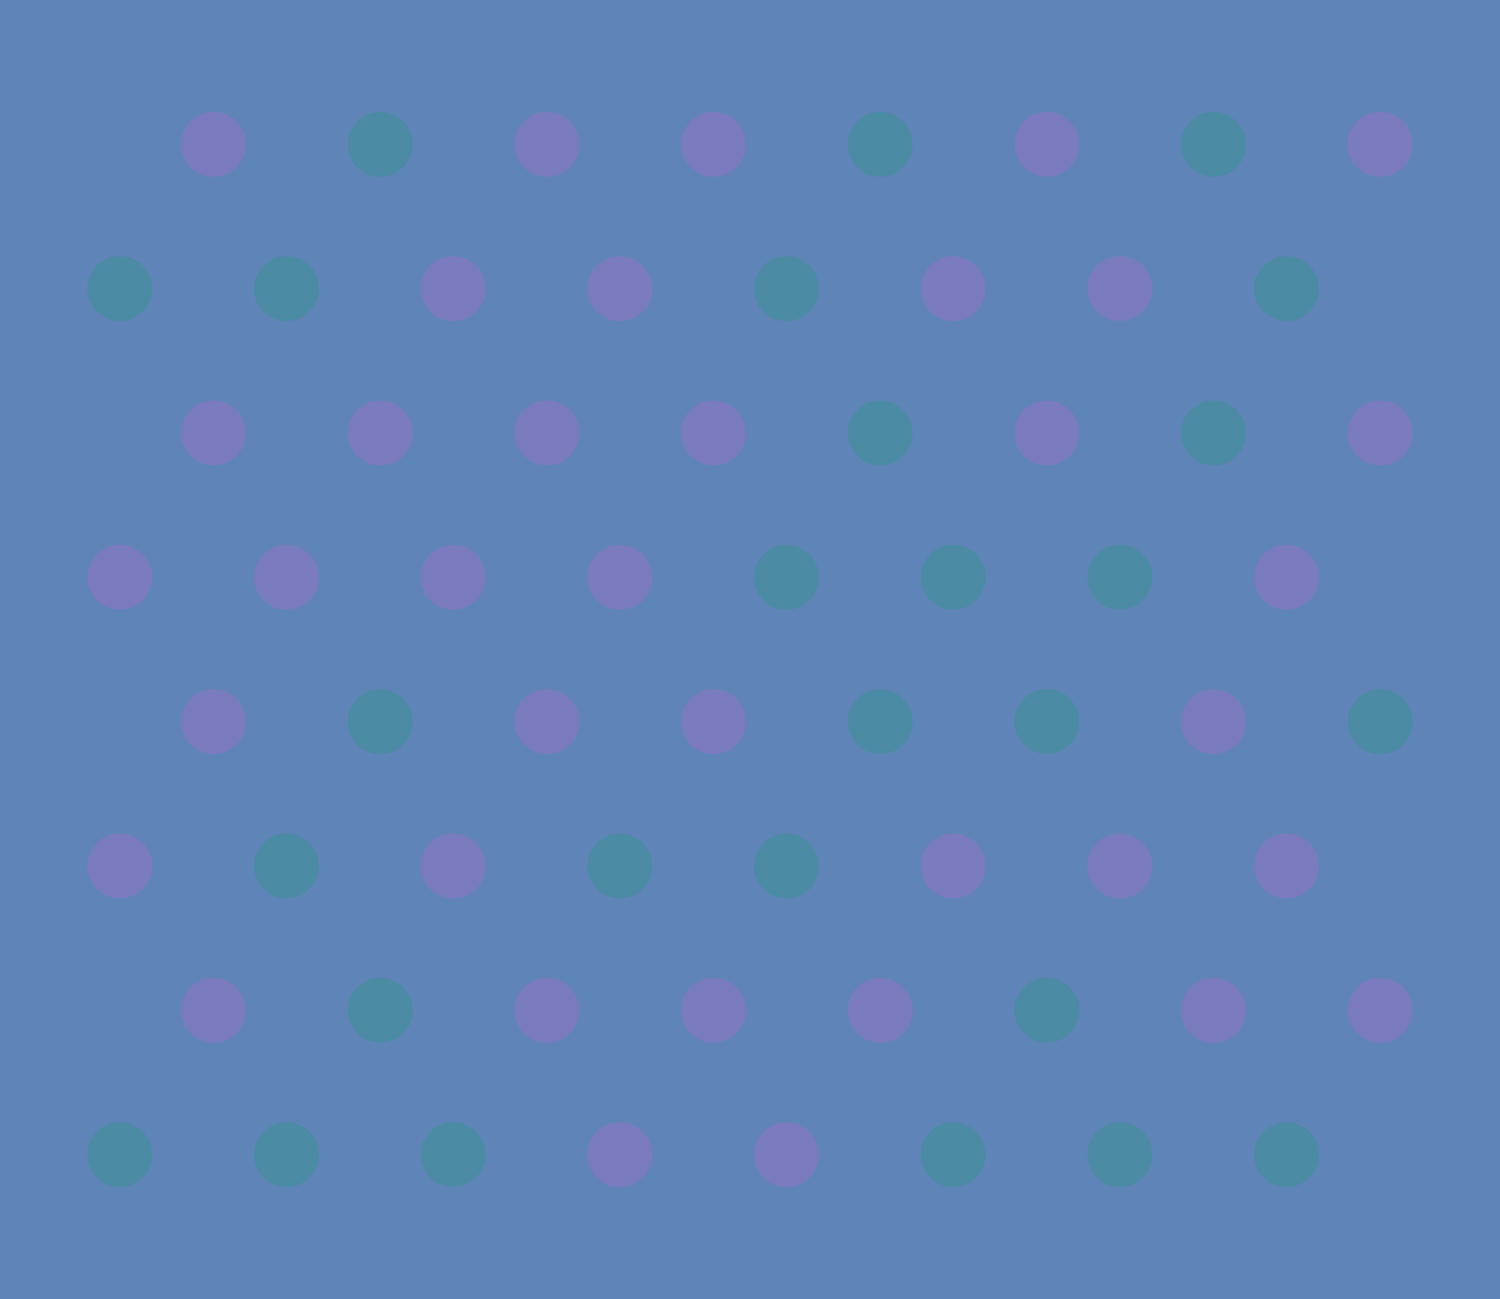

In [13]:
opts_ = opts.copy()
for c_std in np.linspace(0., 30, N_scan, endpoint=False): 
    opts_.update(c_mean=c_blue, c_std=c_std)
    print(f'{c_std=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


## N_H

N_H_=2


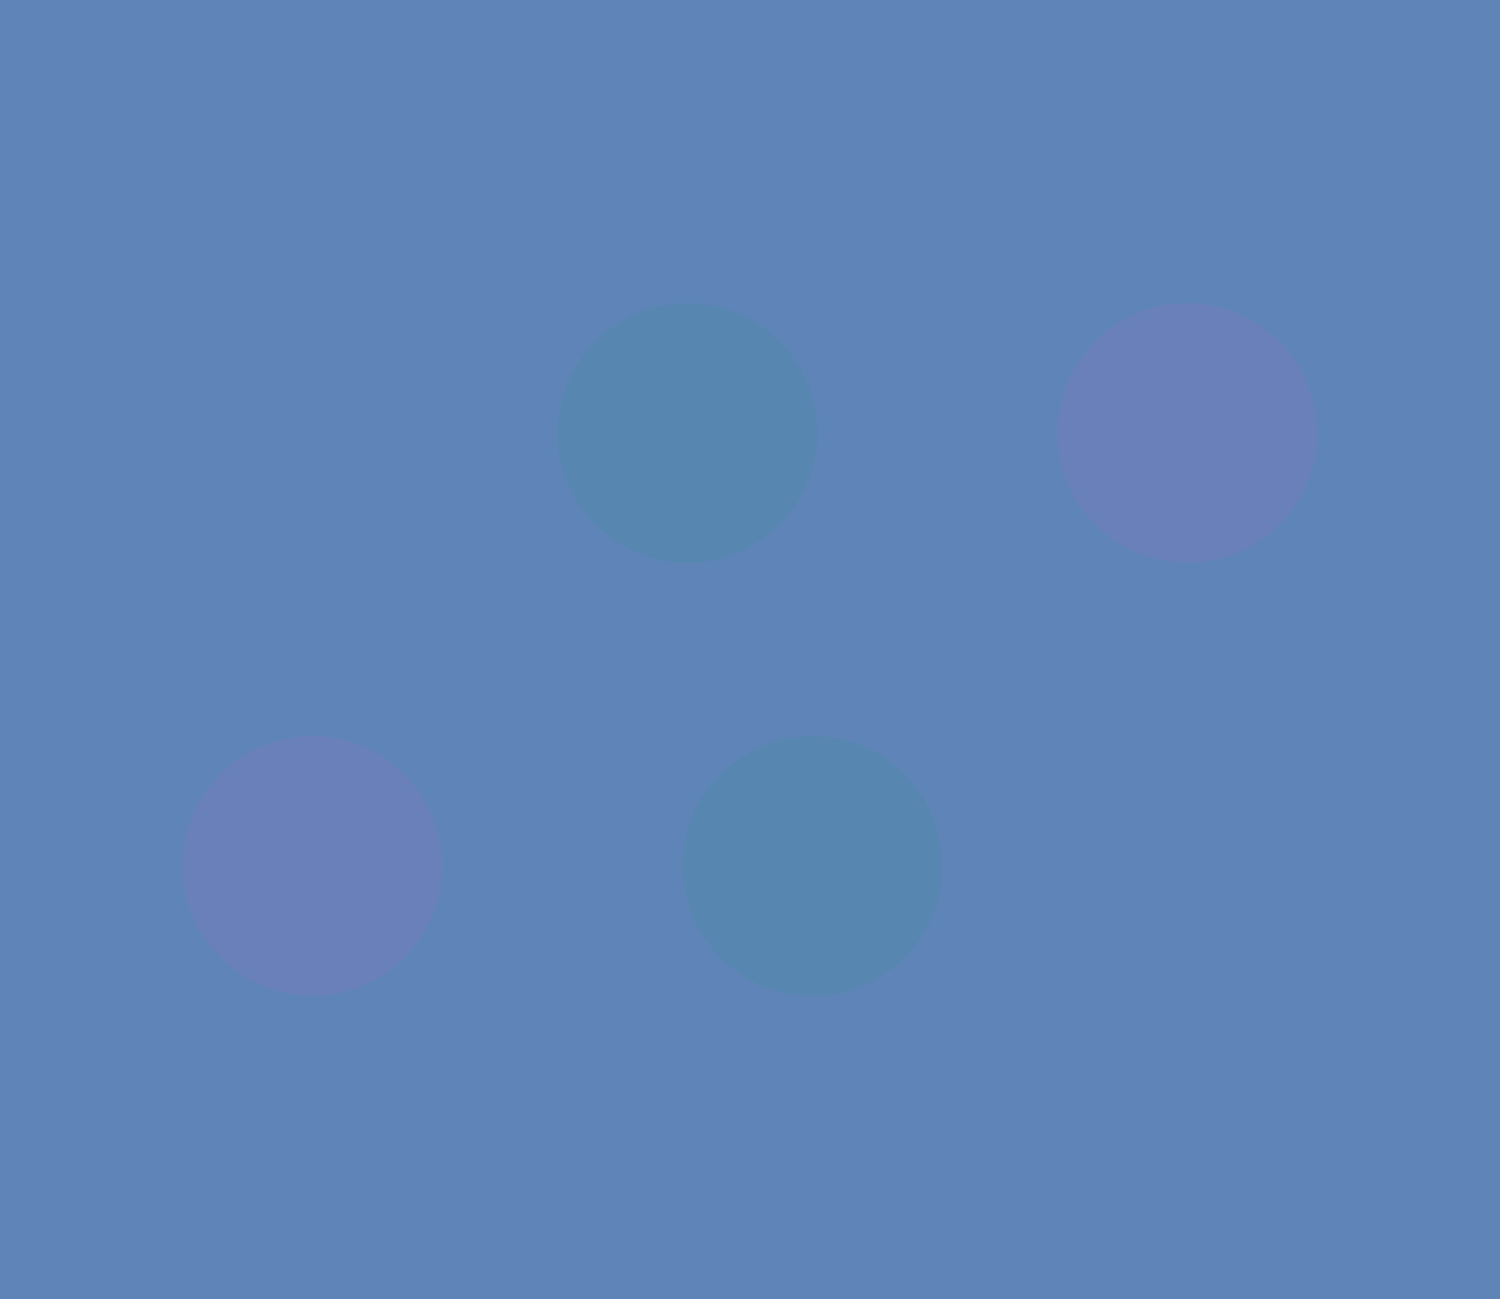

N_H_=3


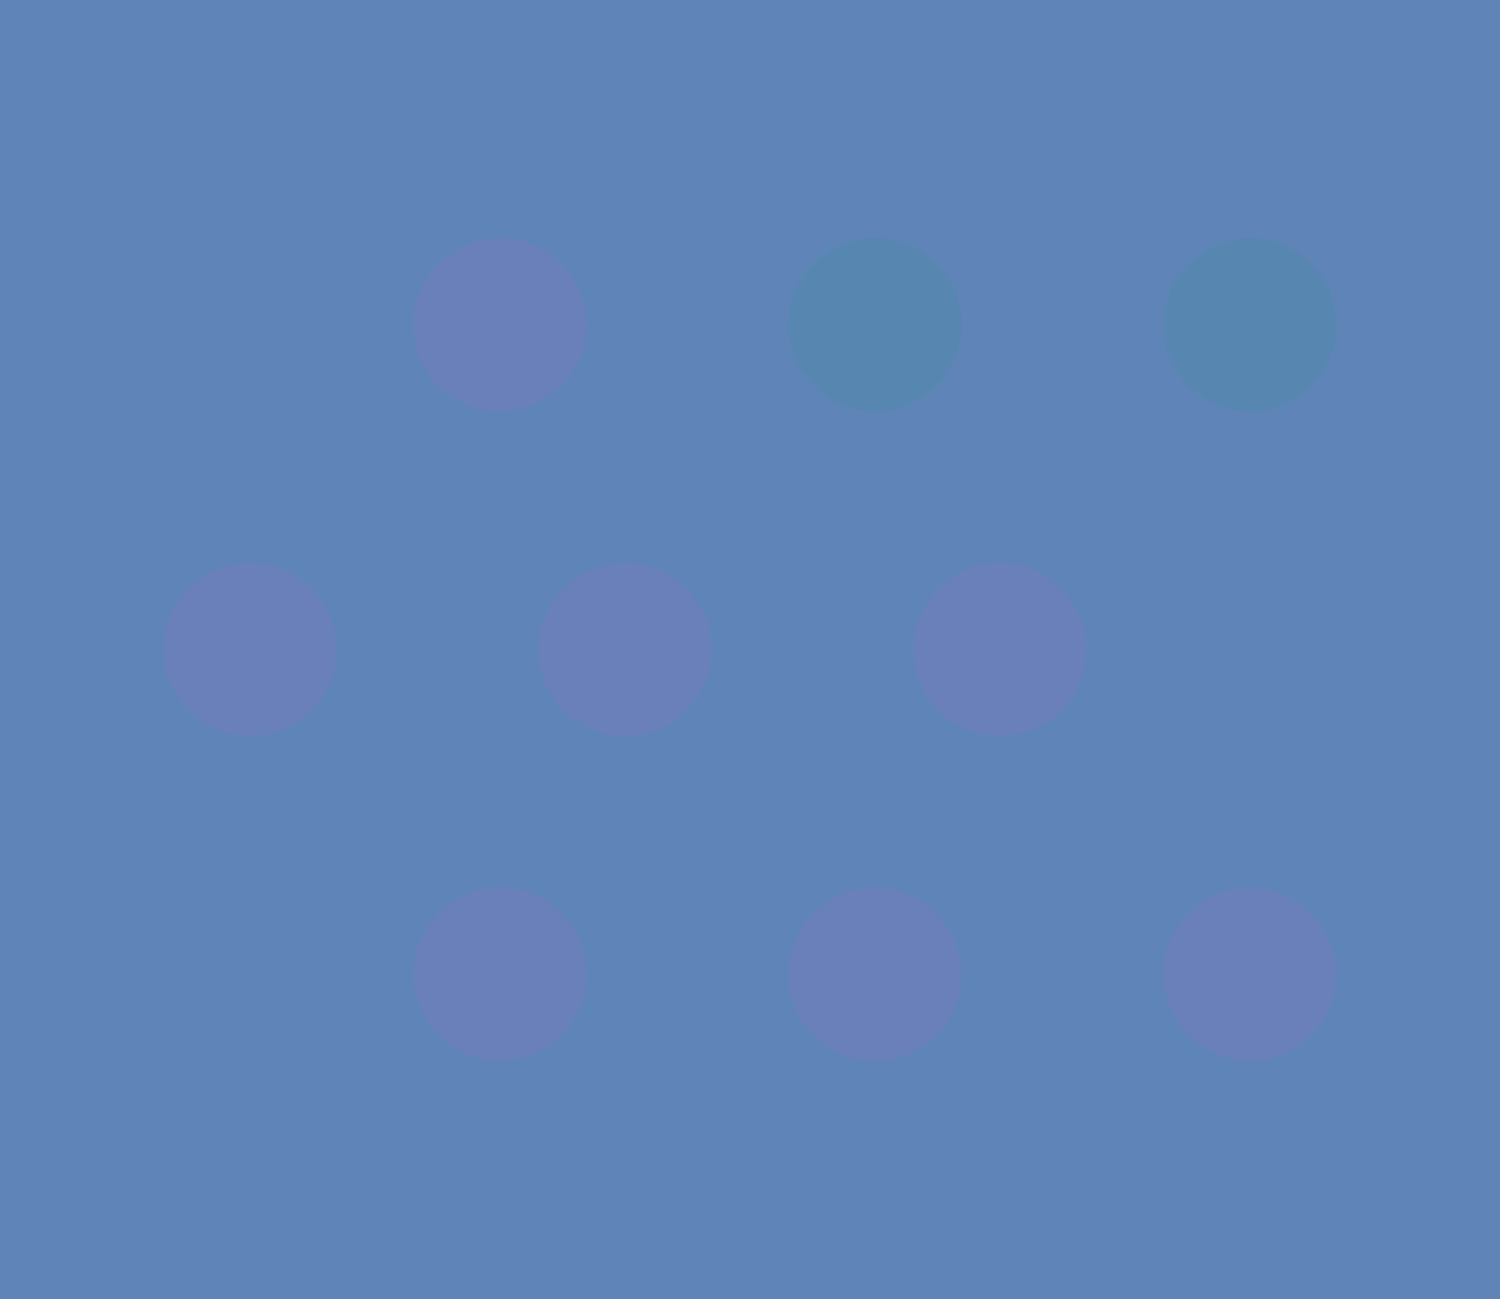

N_H_=4


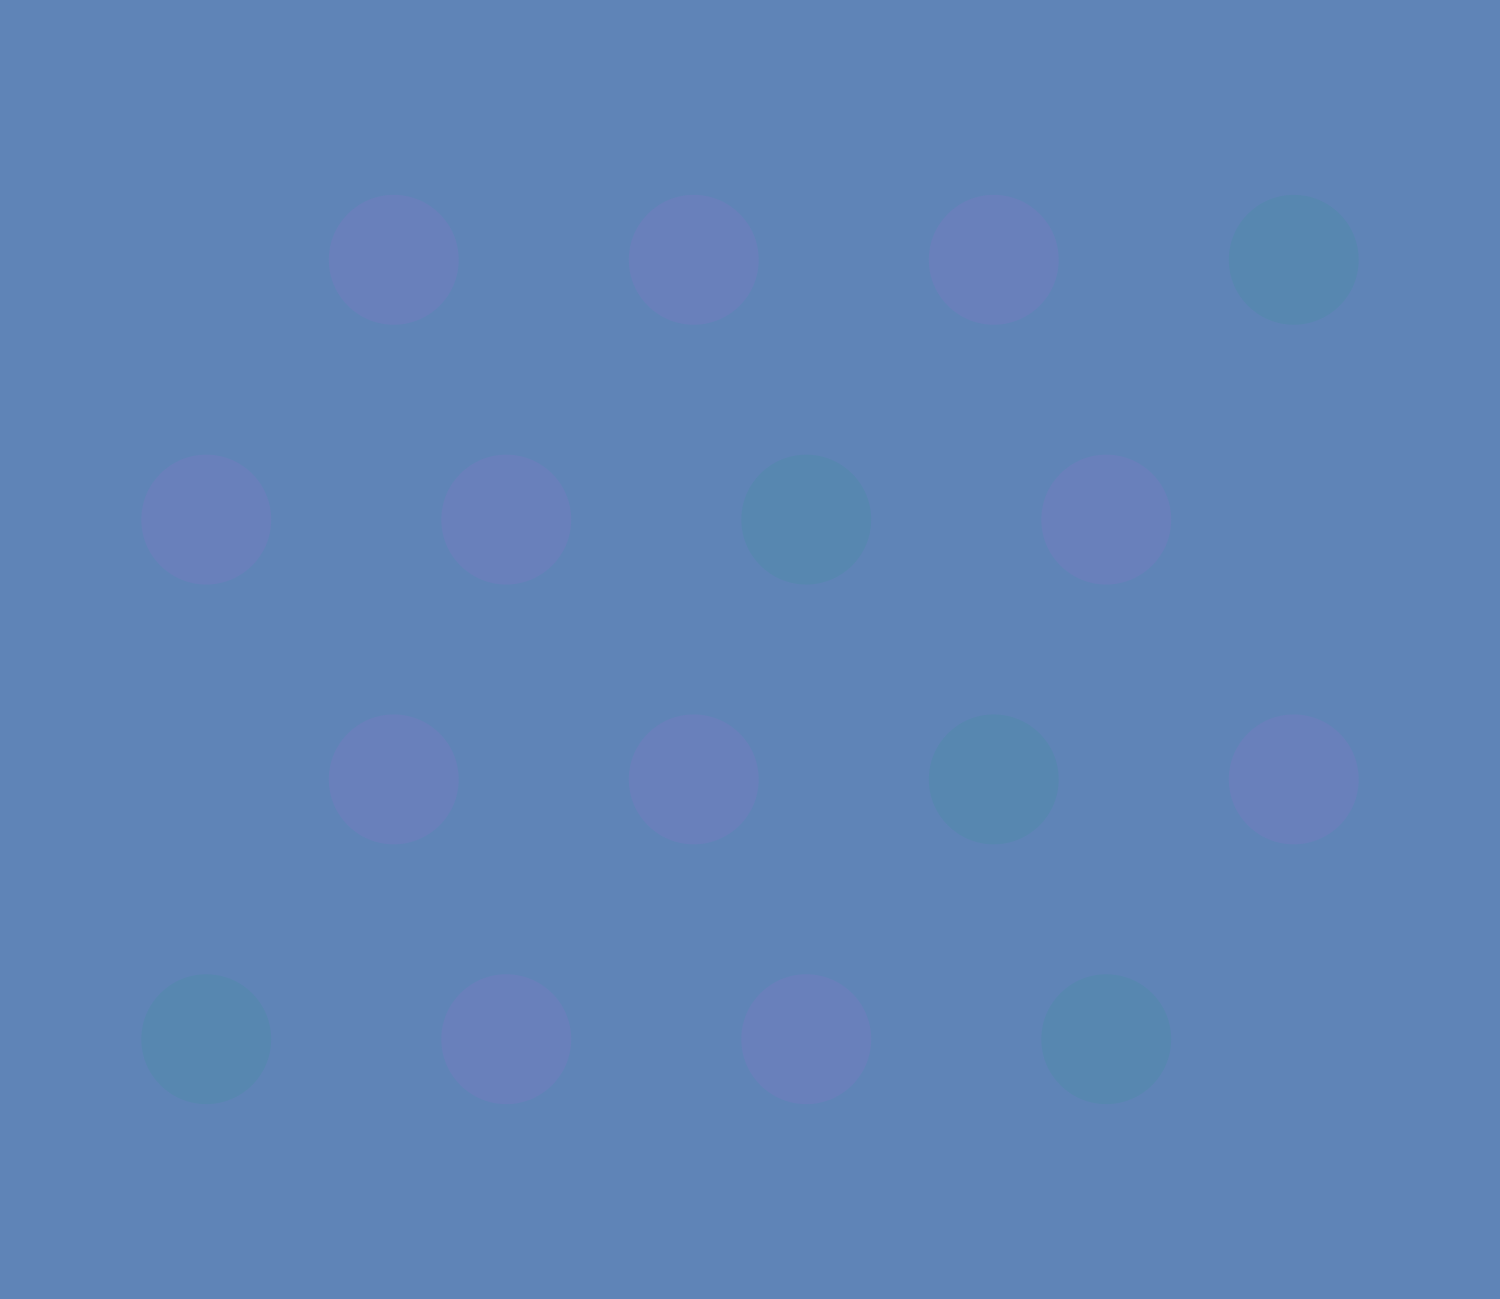

N_H_=6


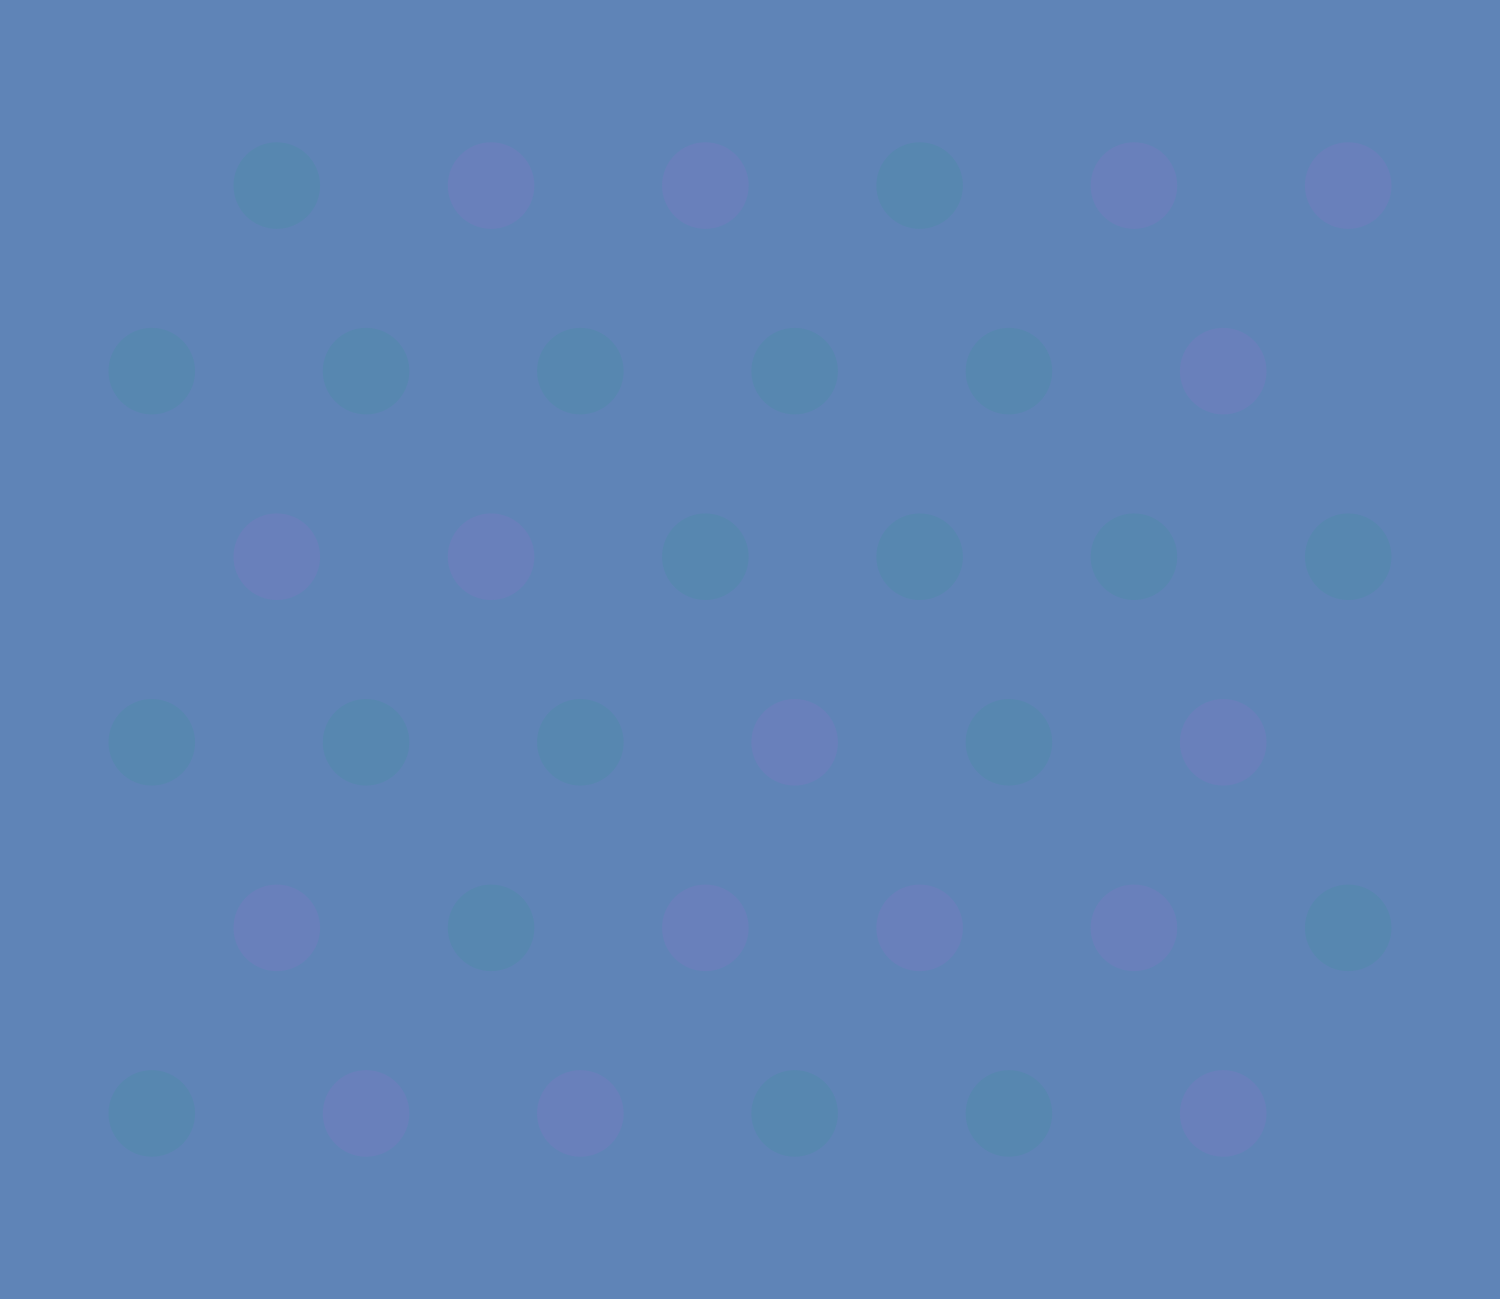

N_H_=8


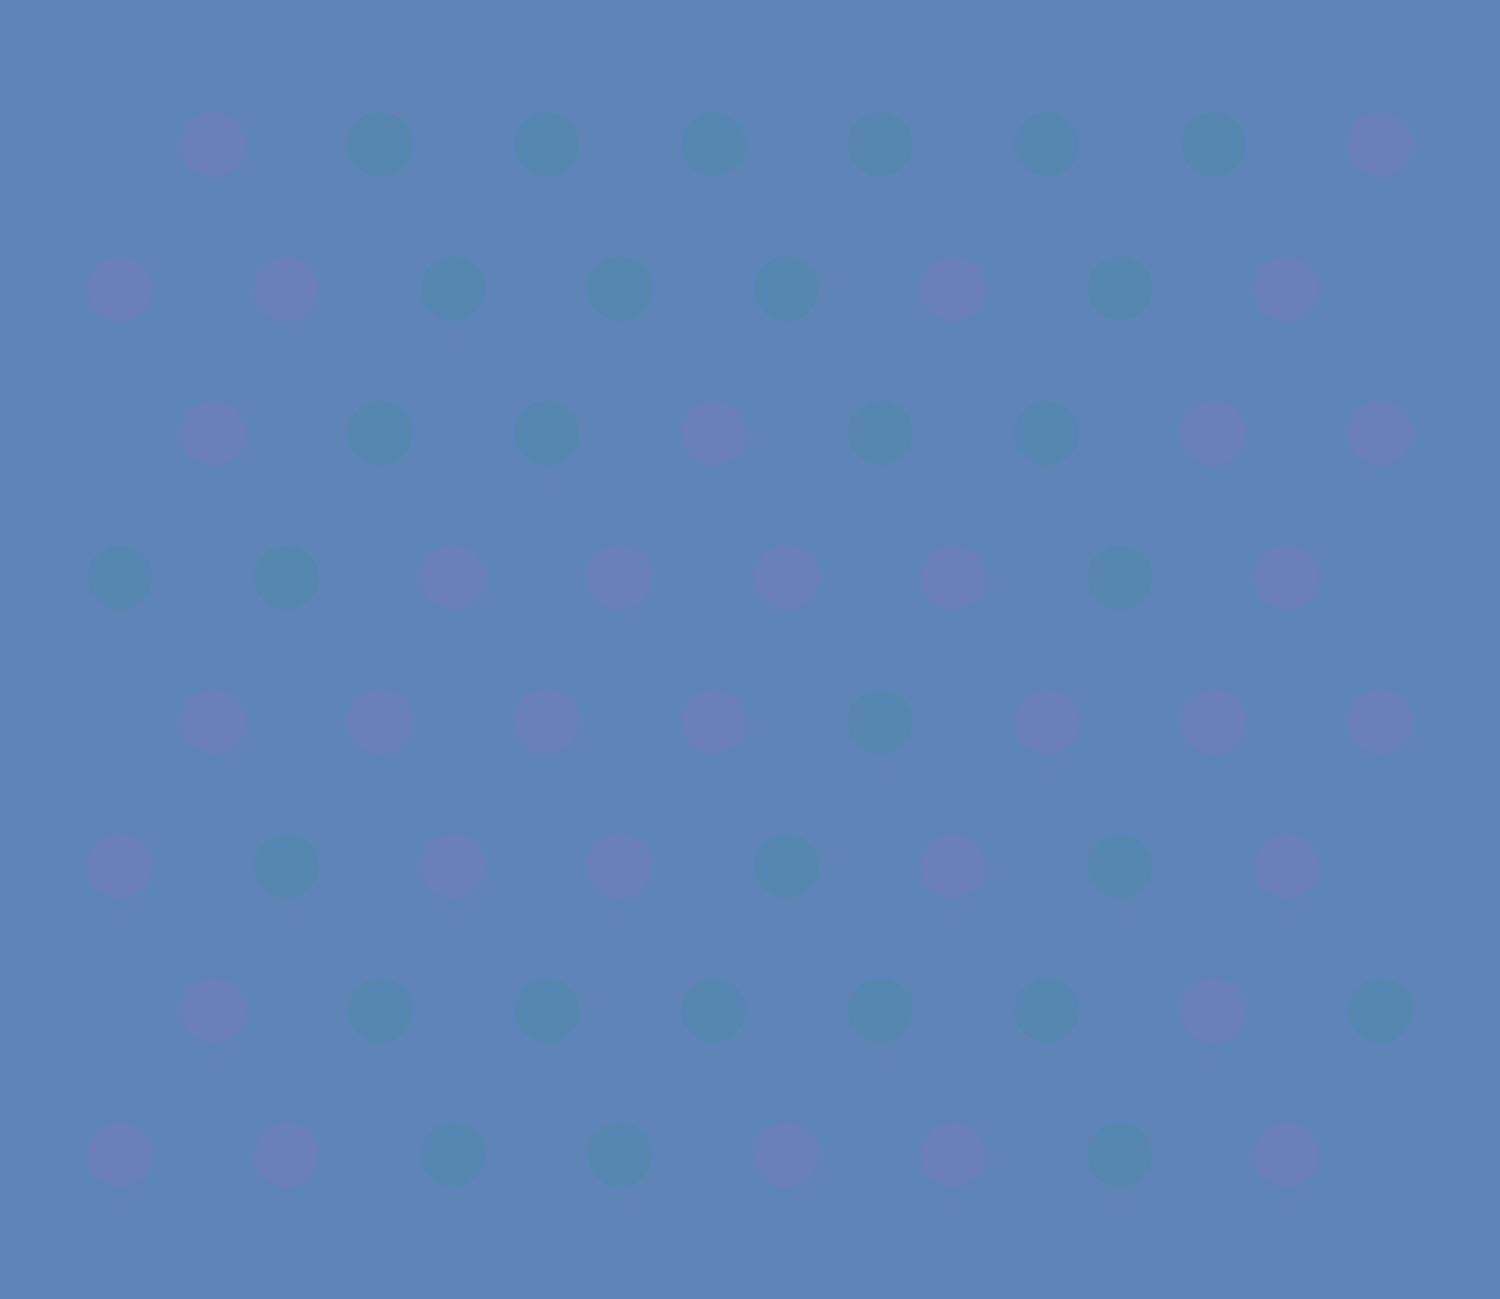

N_H_=10


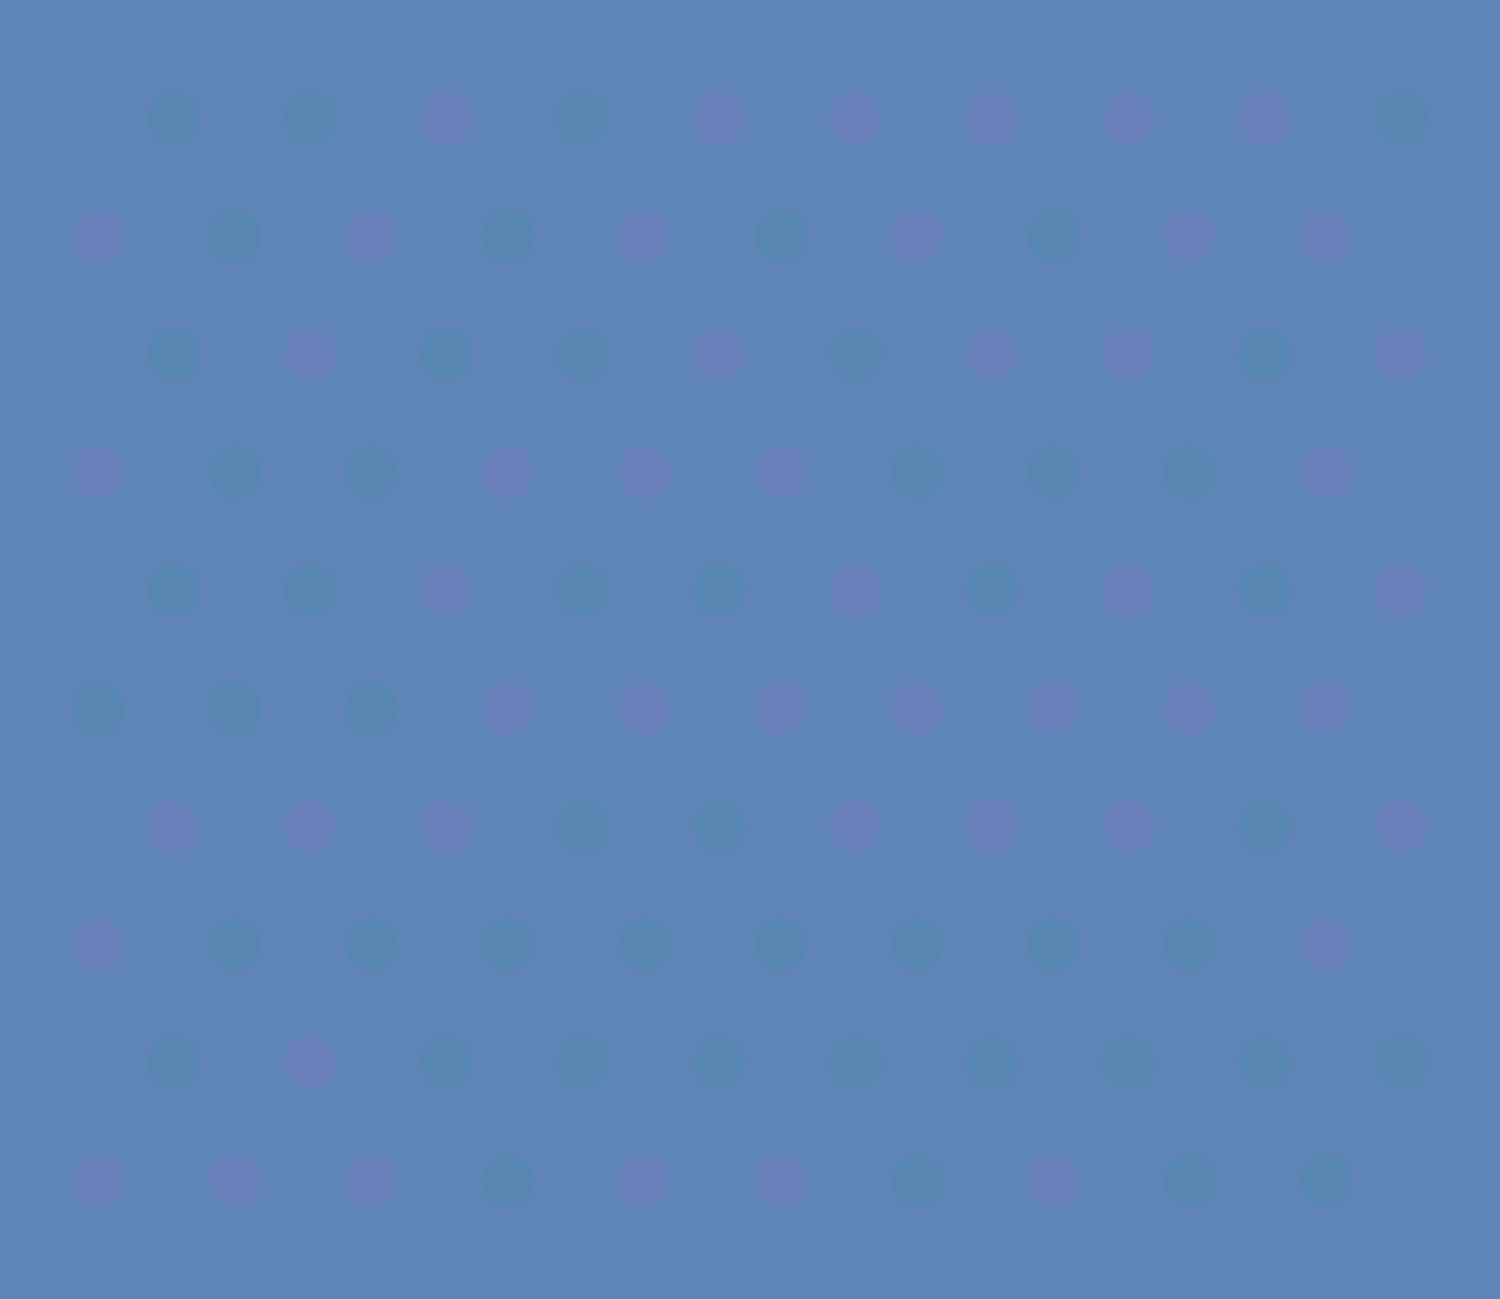

N_H_=13


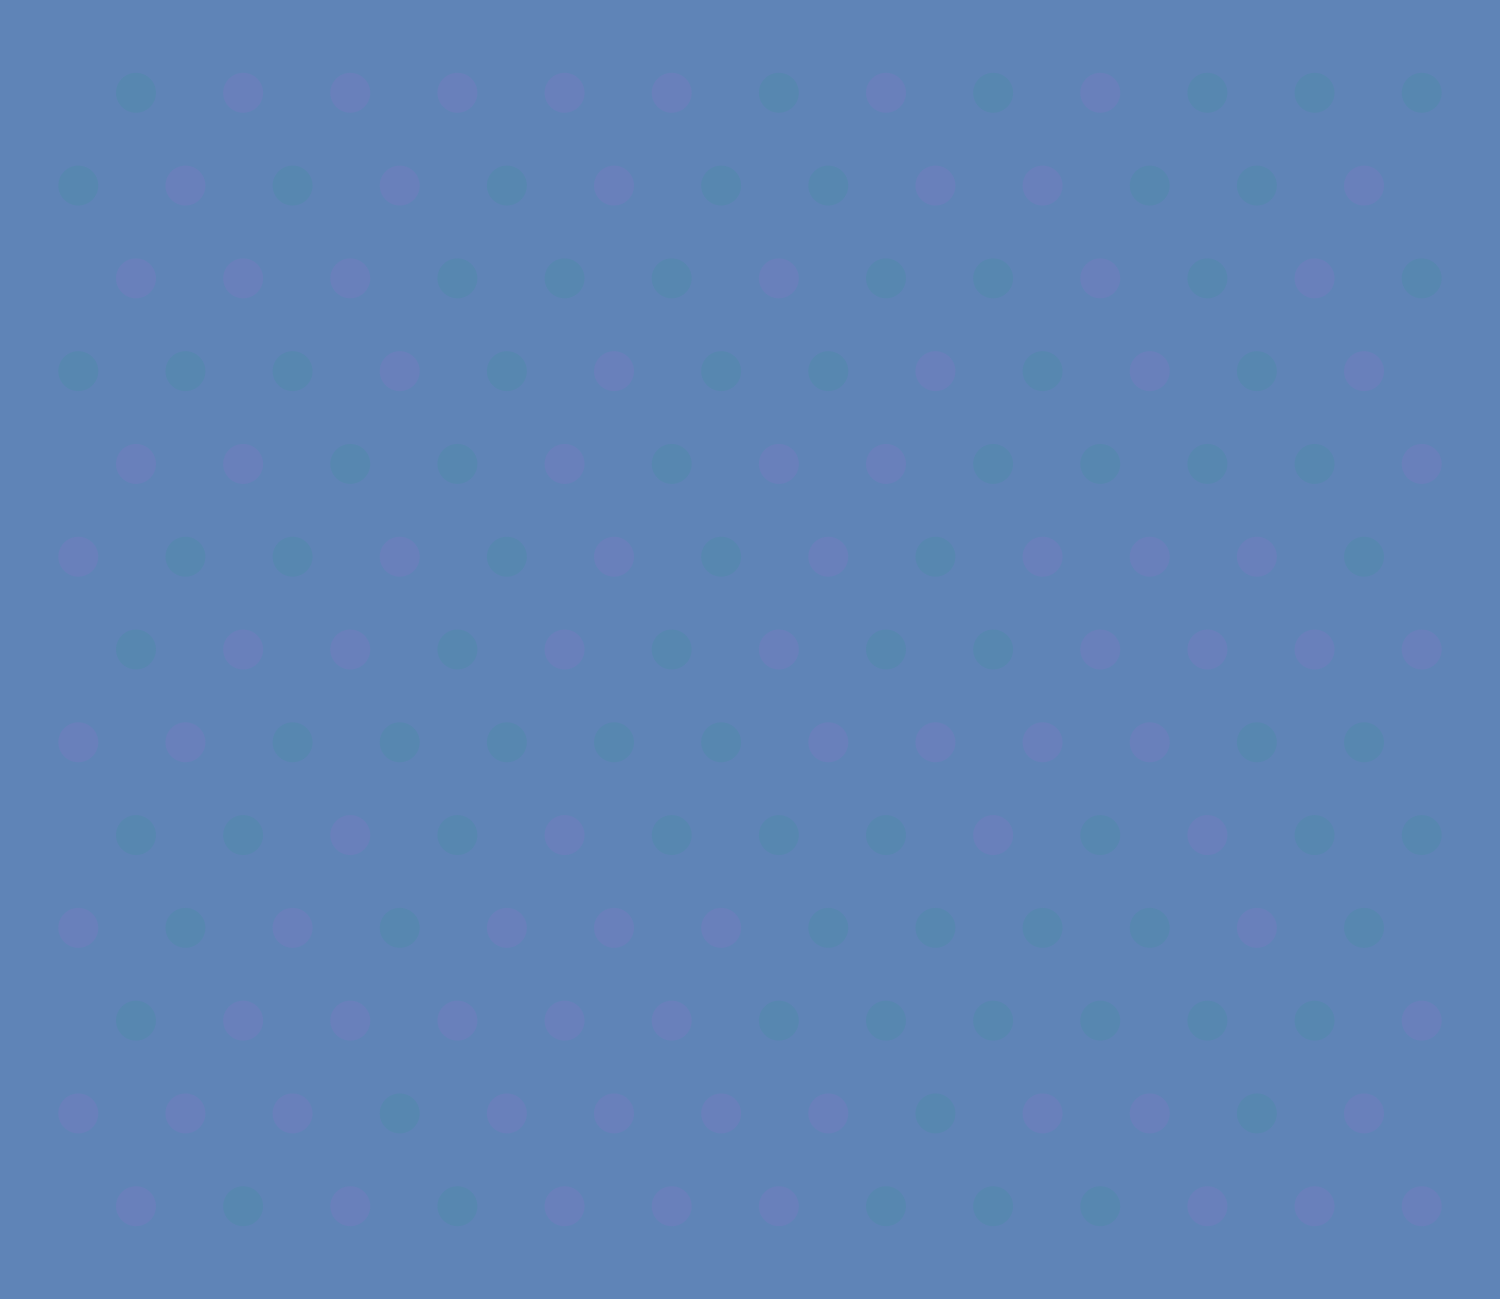

N_H_=18


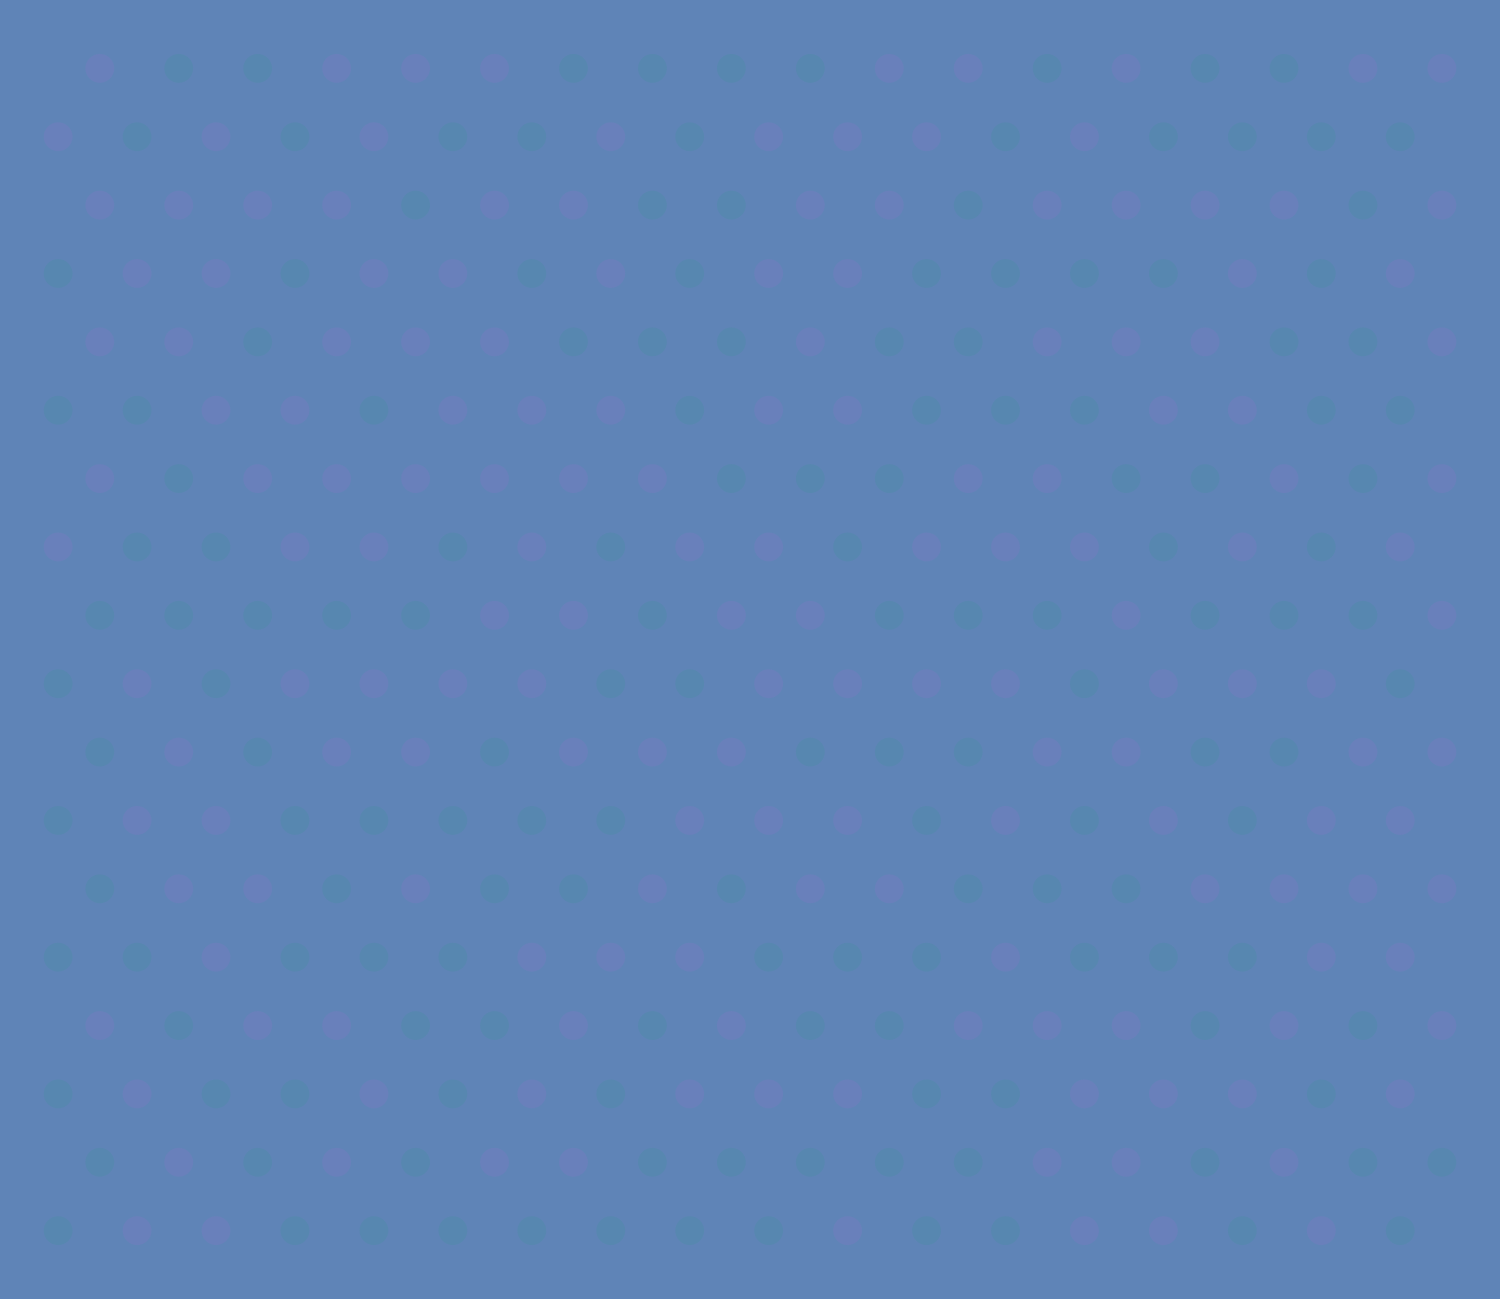

N_H_=24


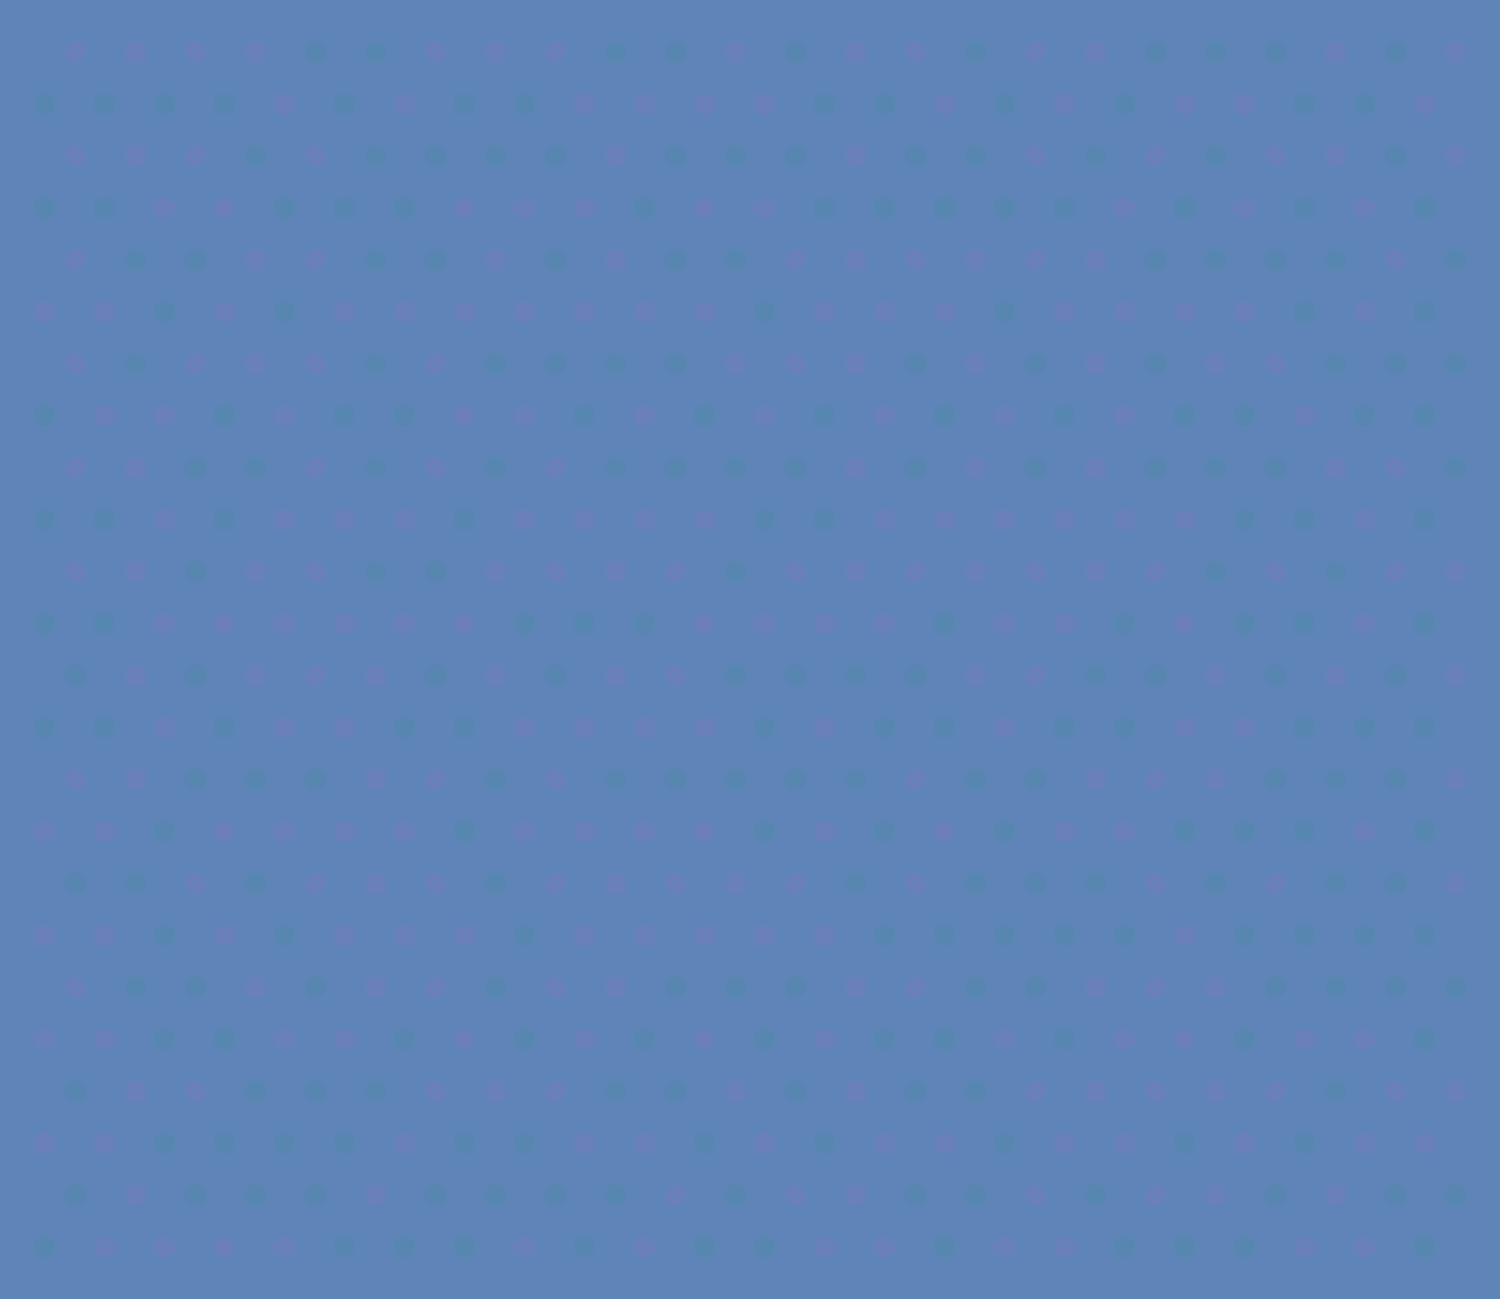

In [21]:
opts_ = opts.copy()
N_Hs = [int(k) for k in N_H * np.logspace(-1, 1, N_scan, base=3, endpoint=True)]
for N_H_ in N_Hs: 
    opts_.update(N_H=N_H_,N_W=N_H_)
    print(f'{N_H_=}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

## N_width

In [15]:
# opts_ = opts.copy()
# N_widths = [int(k) for k in N_width * np.logspace(-1, 1, N_scan, base=1.5, endpoint=True)]
# for N_width_ in N_widths: 
#     opts_.update(N_width=N_width_)
#     print(f'{N_width_=}')
#     @disp
#     def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

## `cairo.OPERATOR_*`

In [16]:
cairo.OPERATOR_MULTIPLY

cairo.Operator.MULTIPLY

0


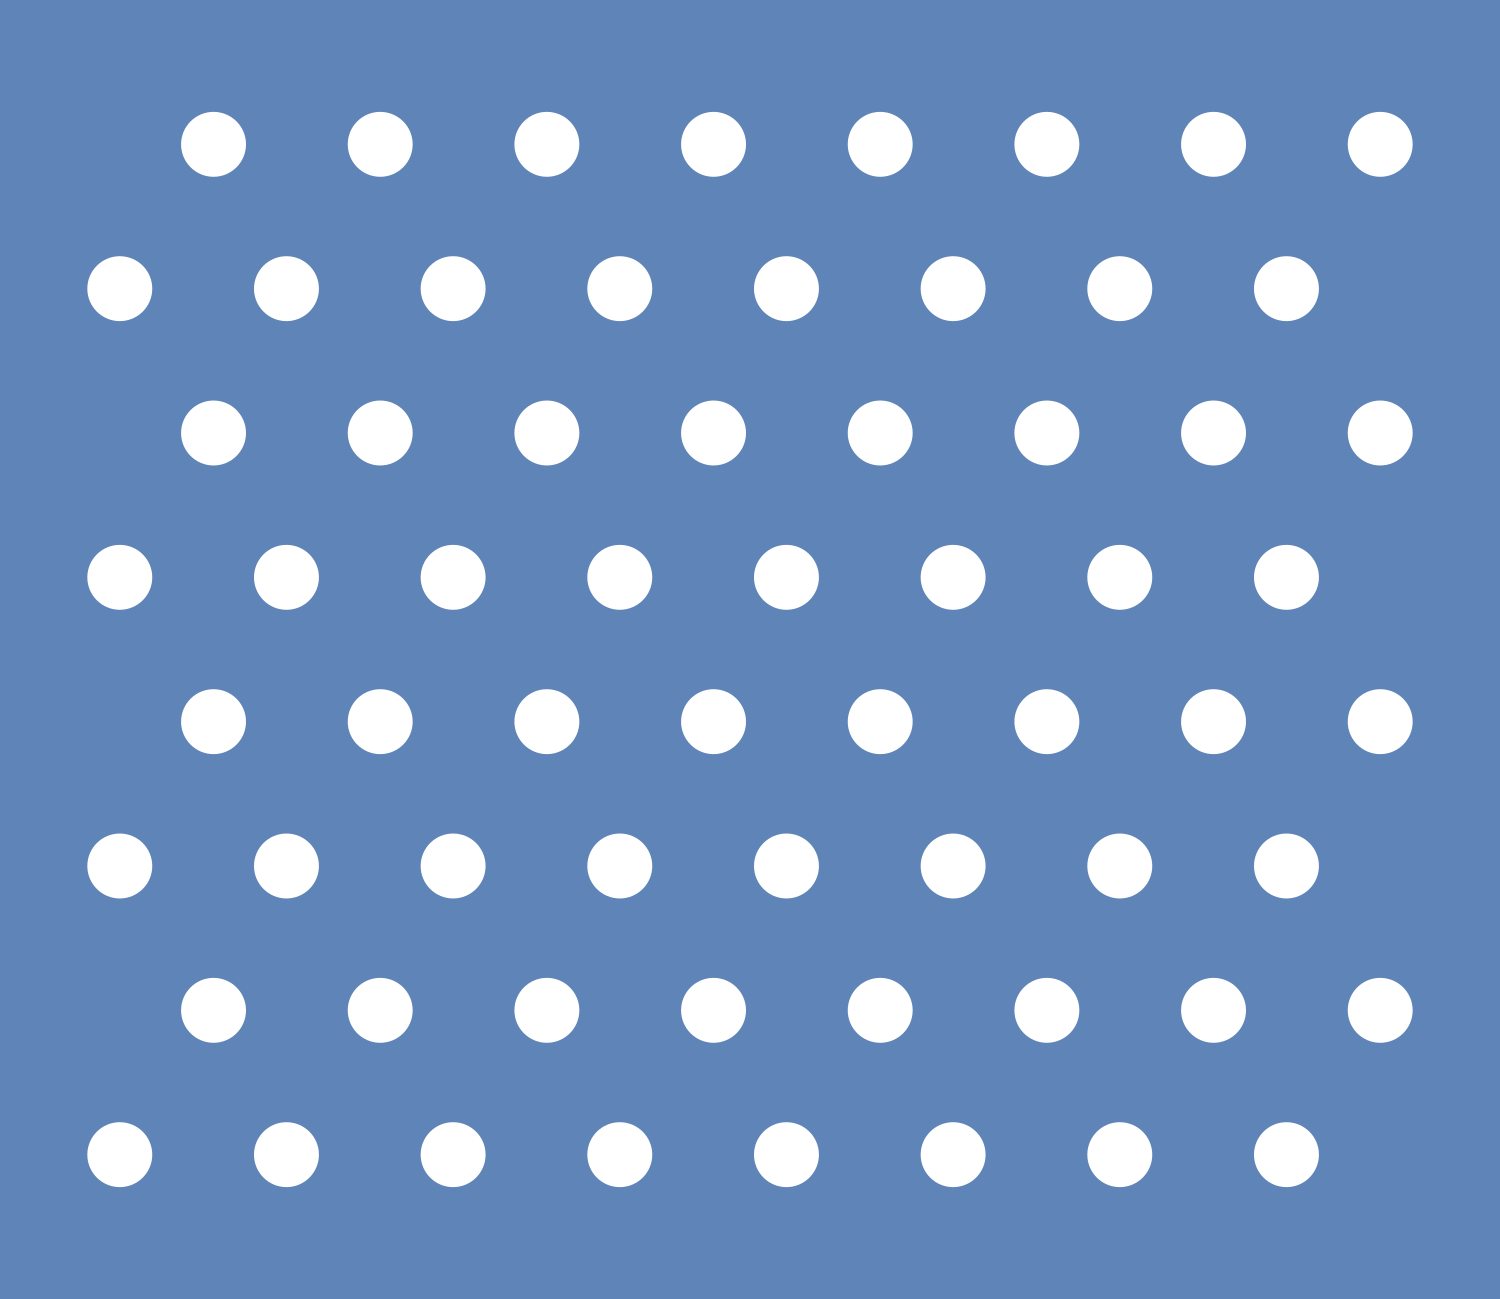

12


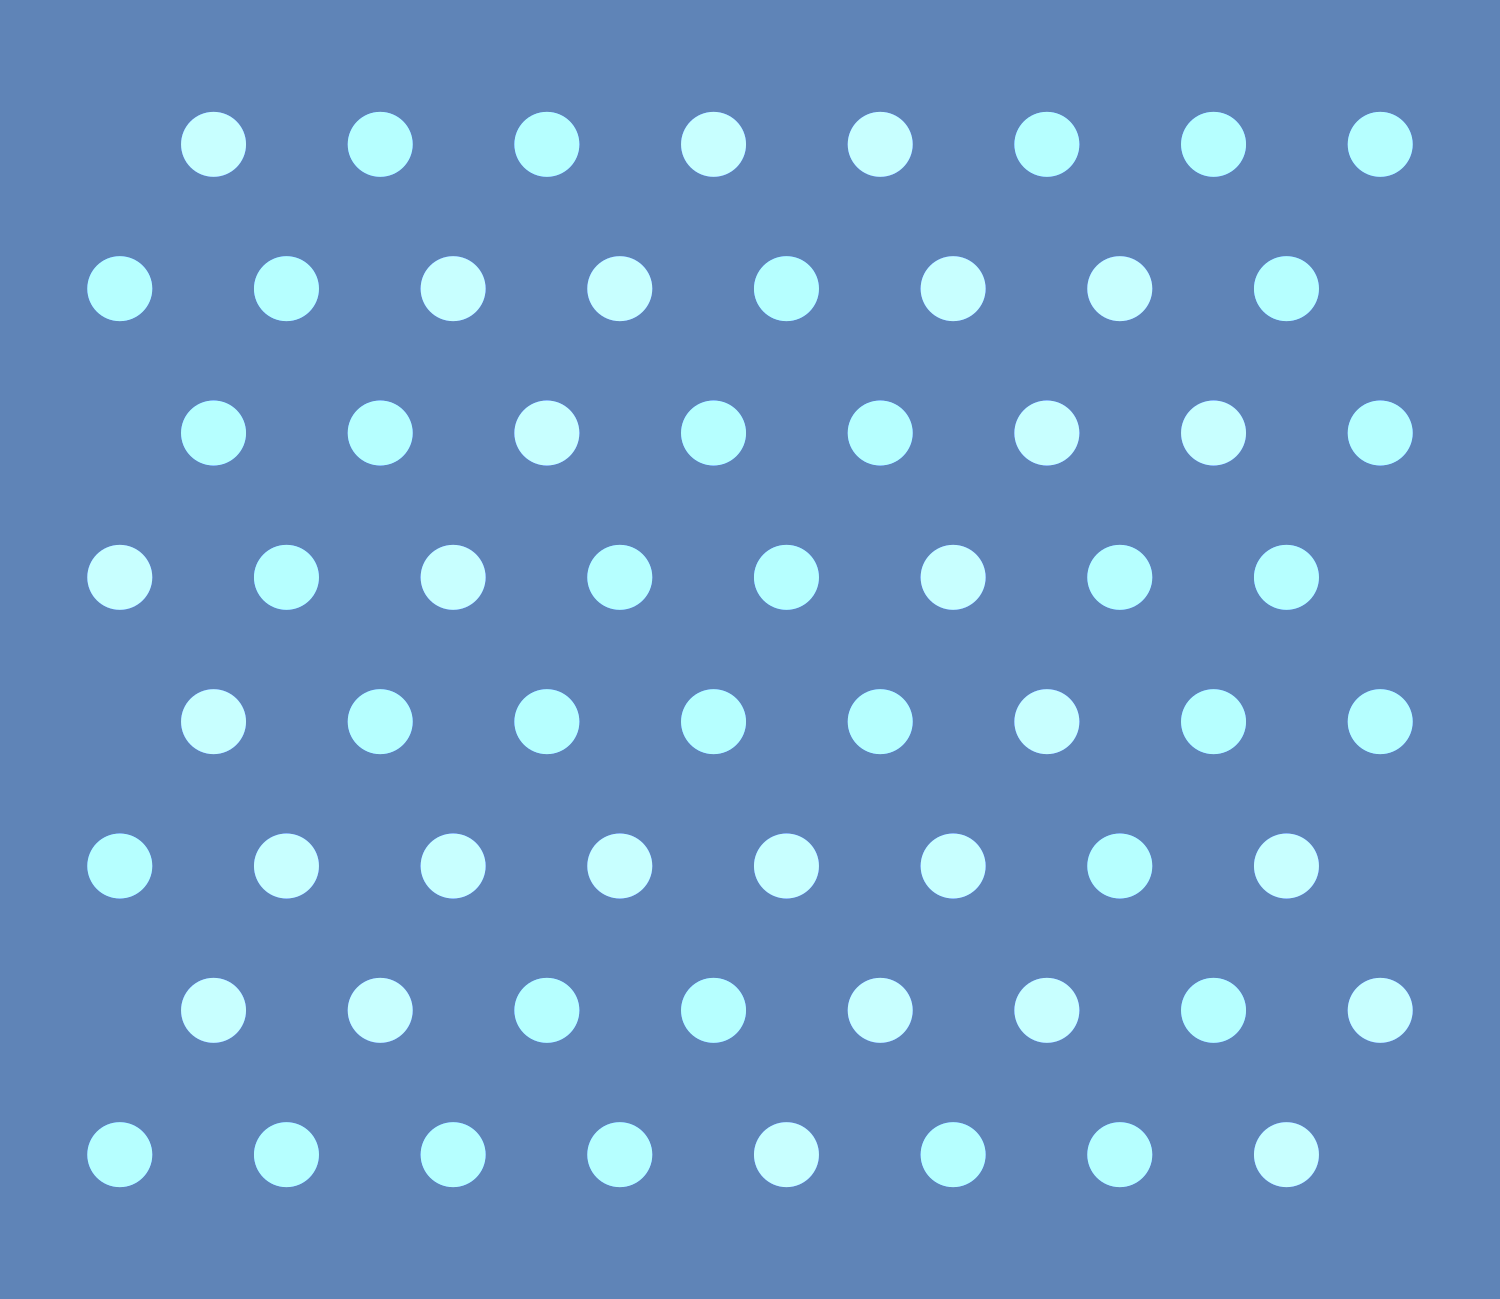

1


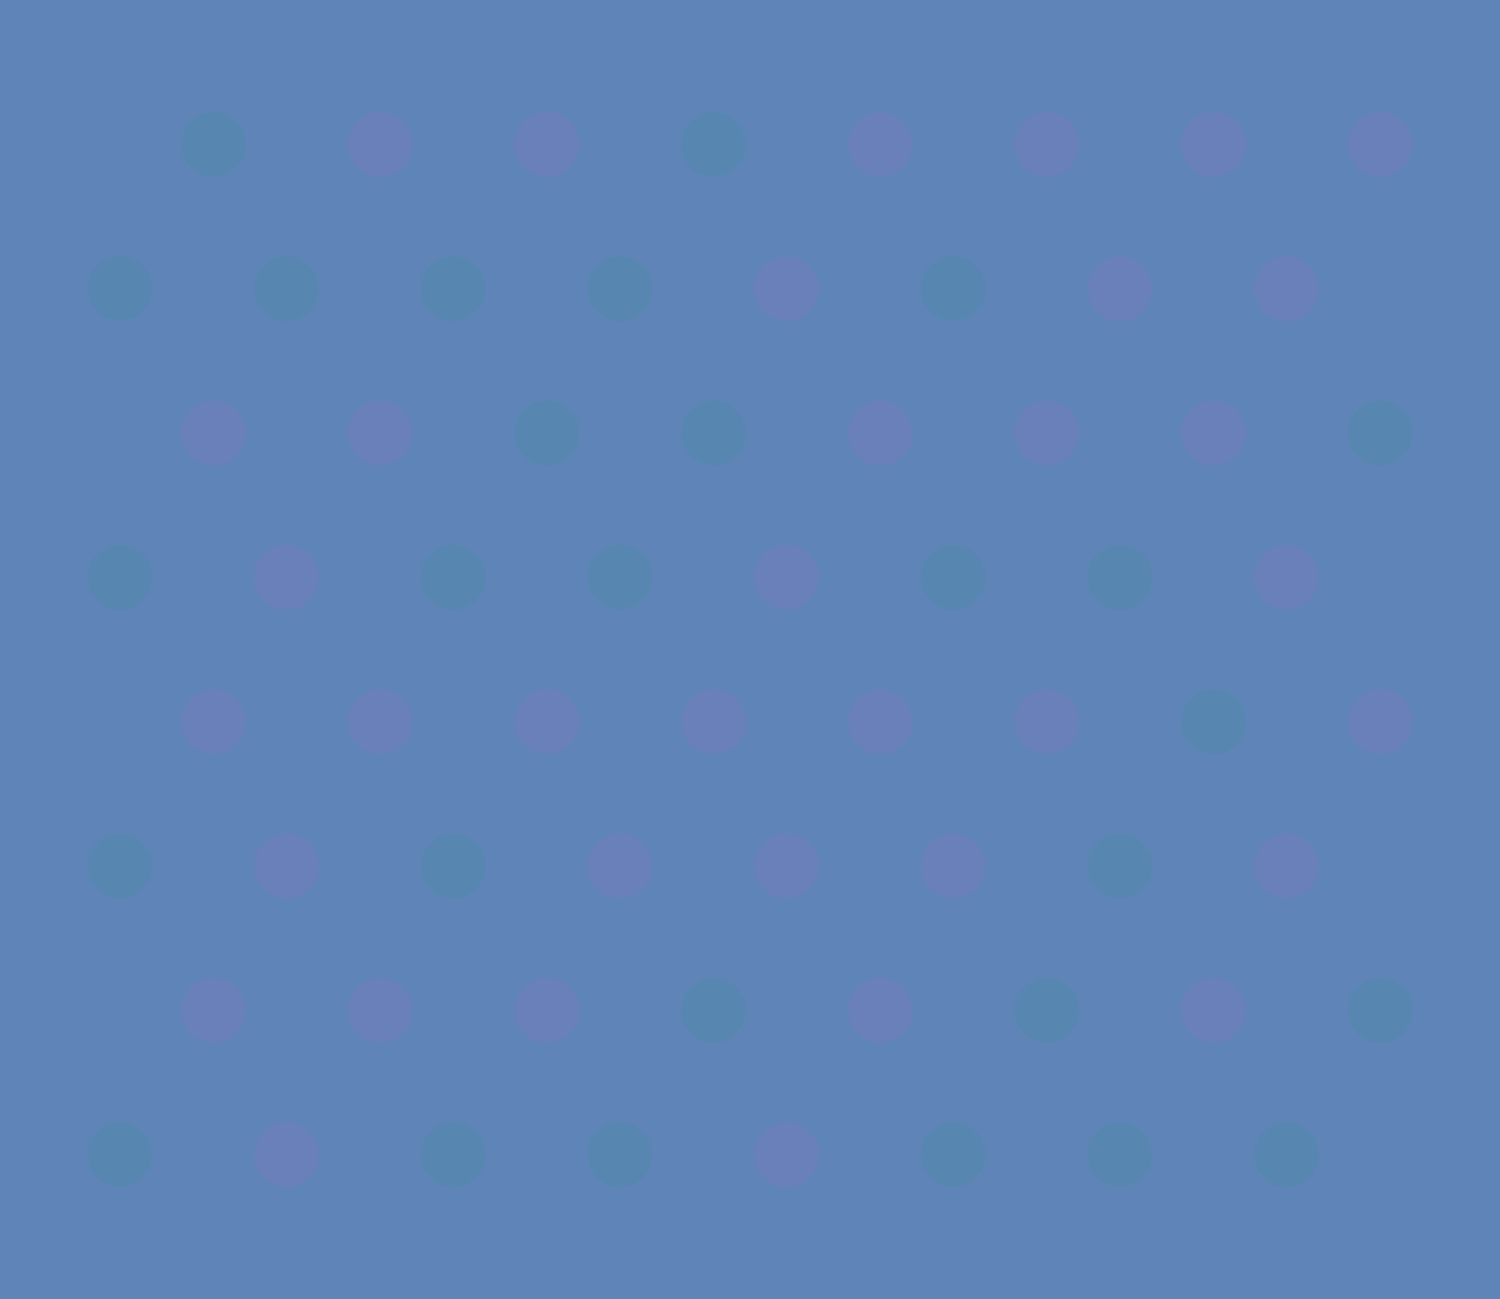

2


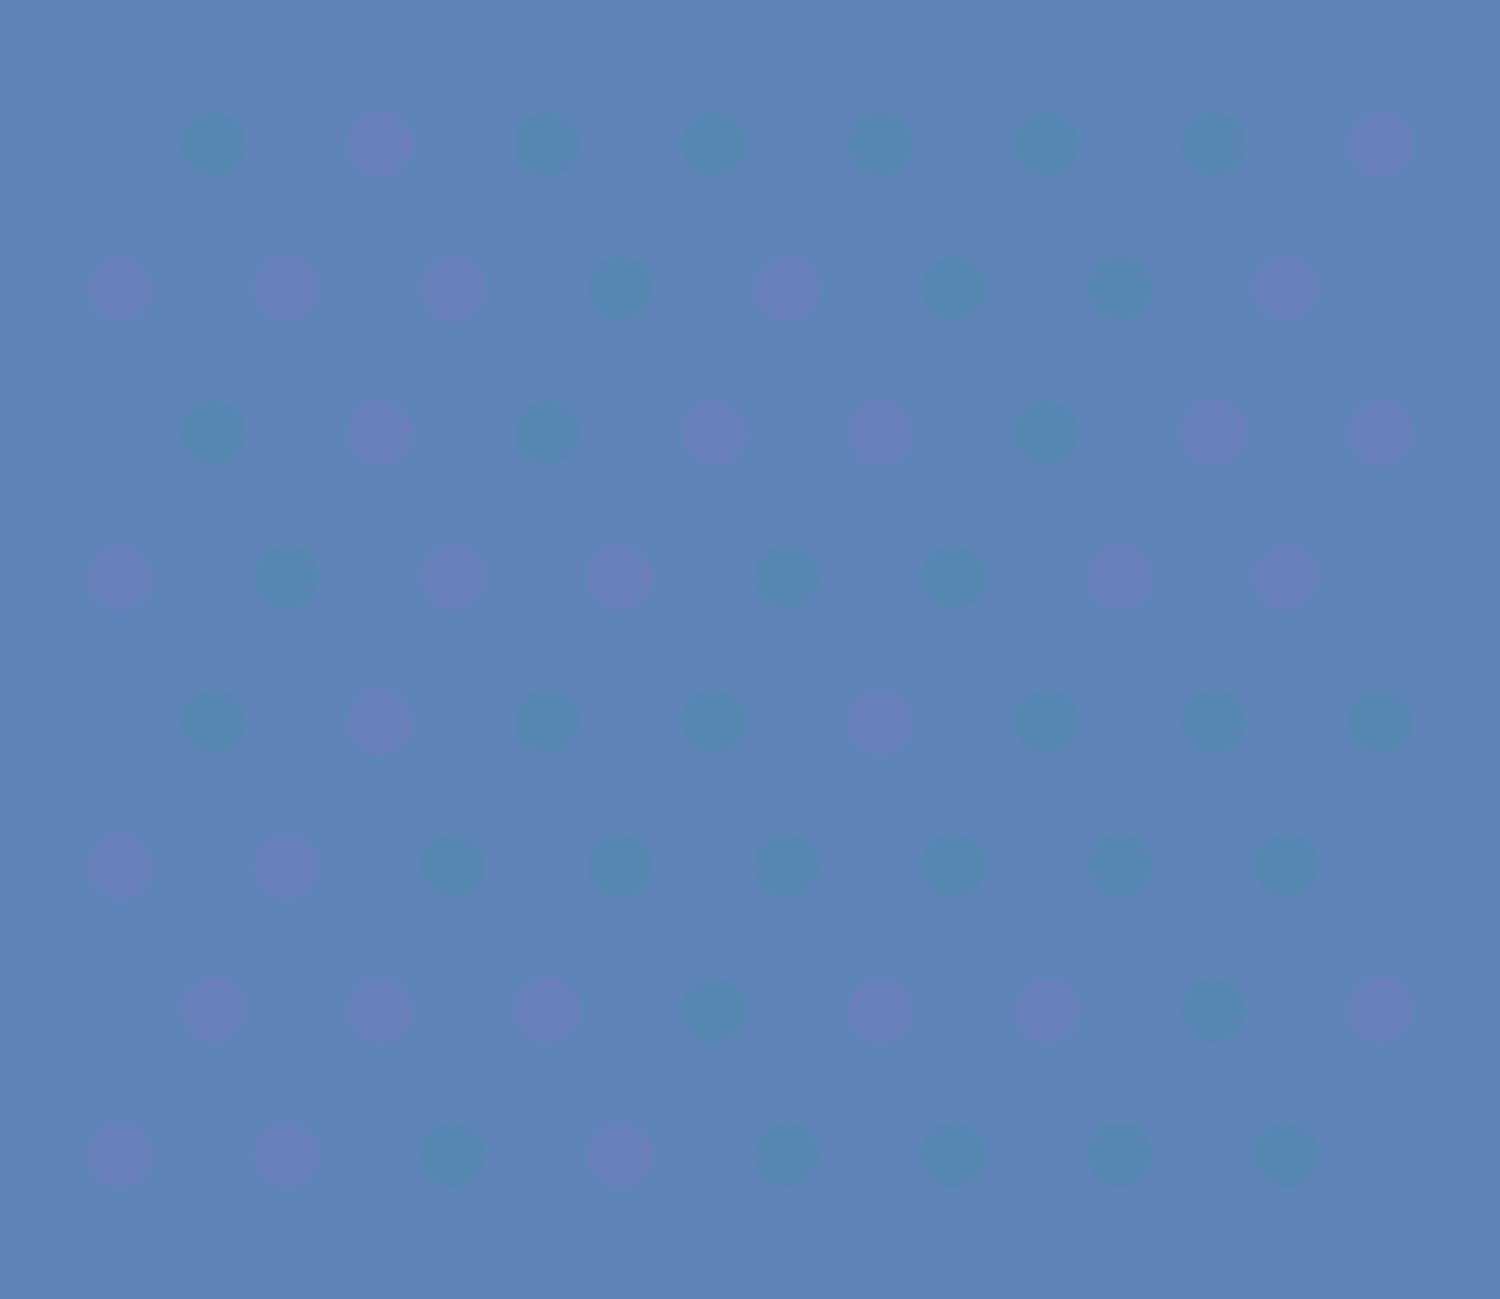

4


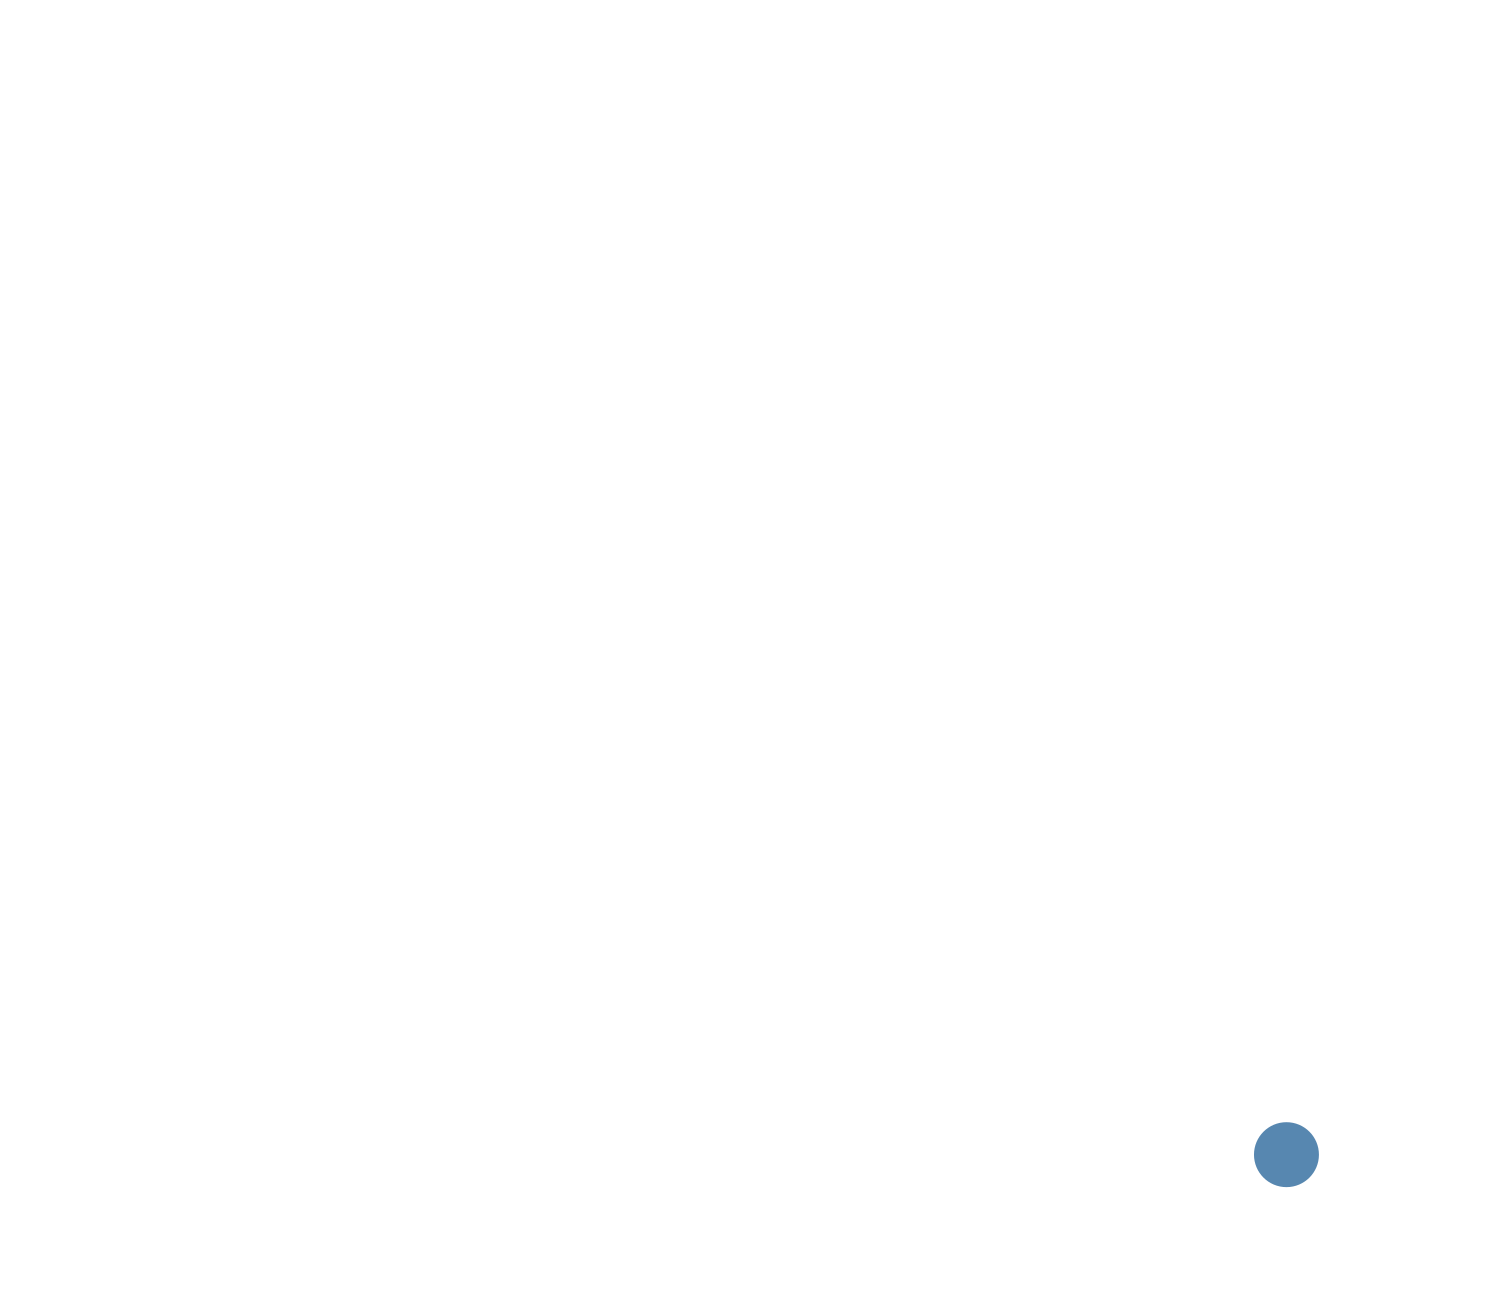

15


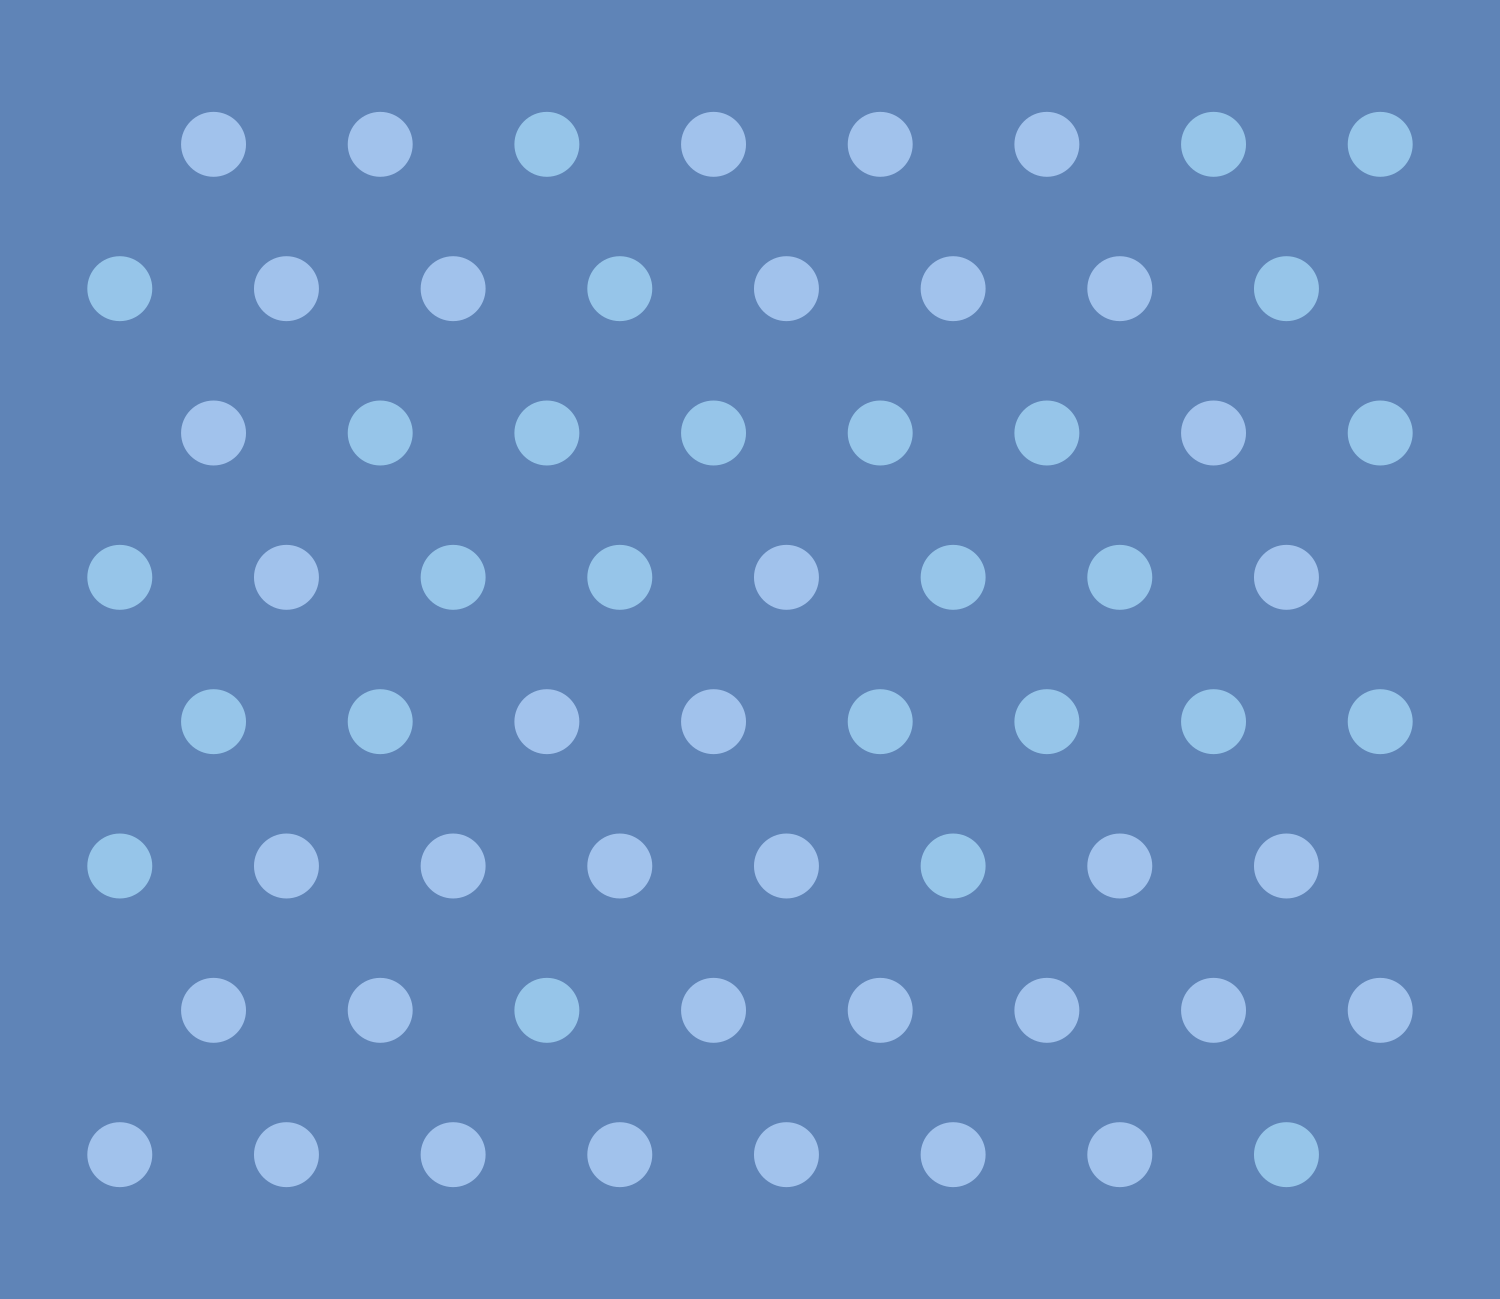

9


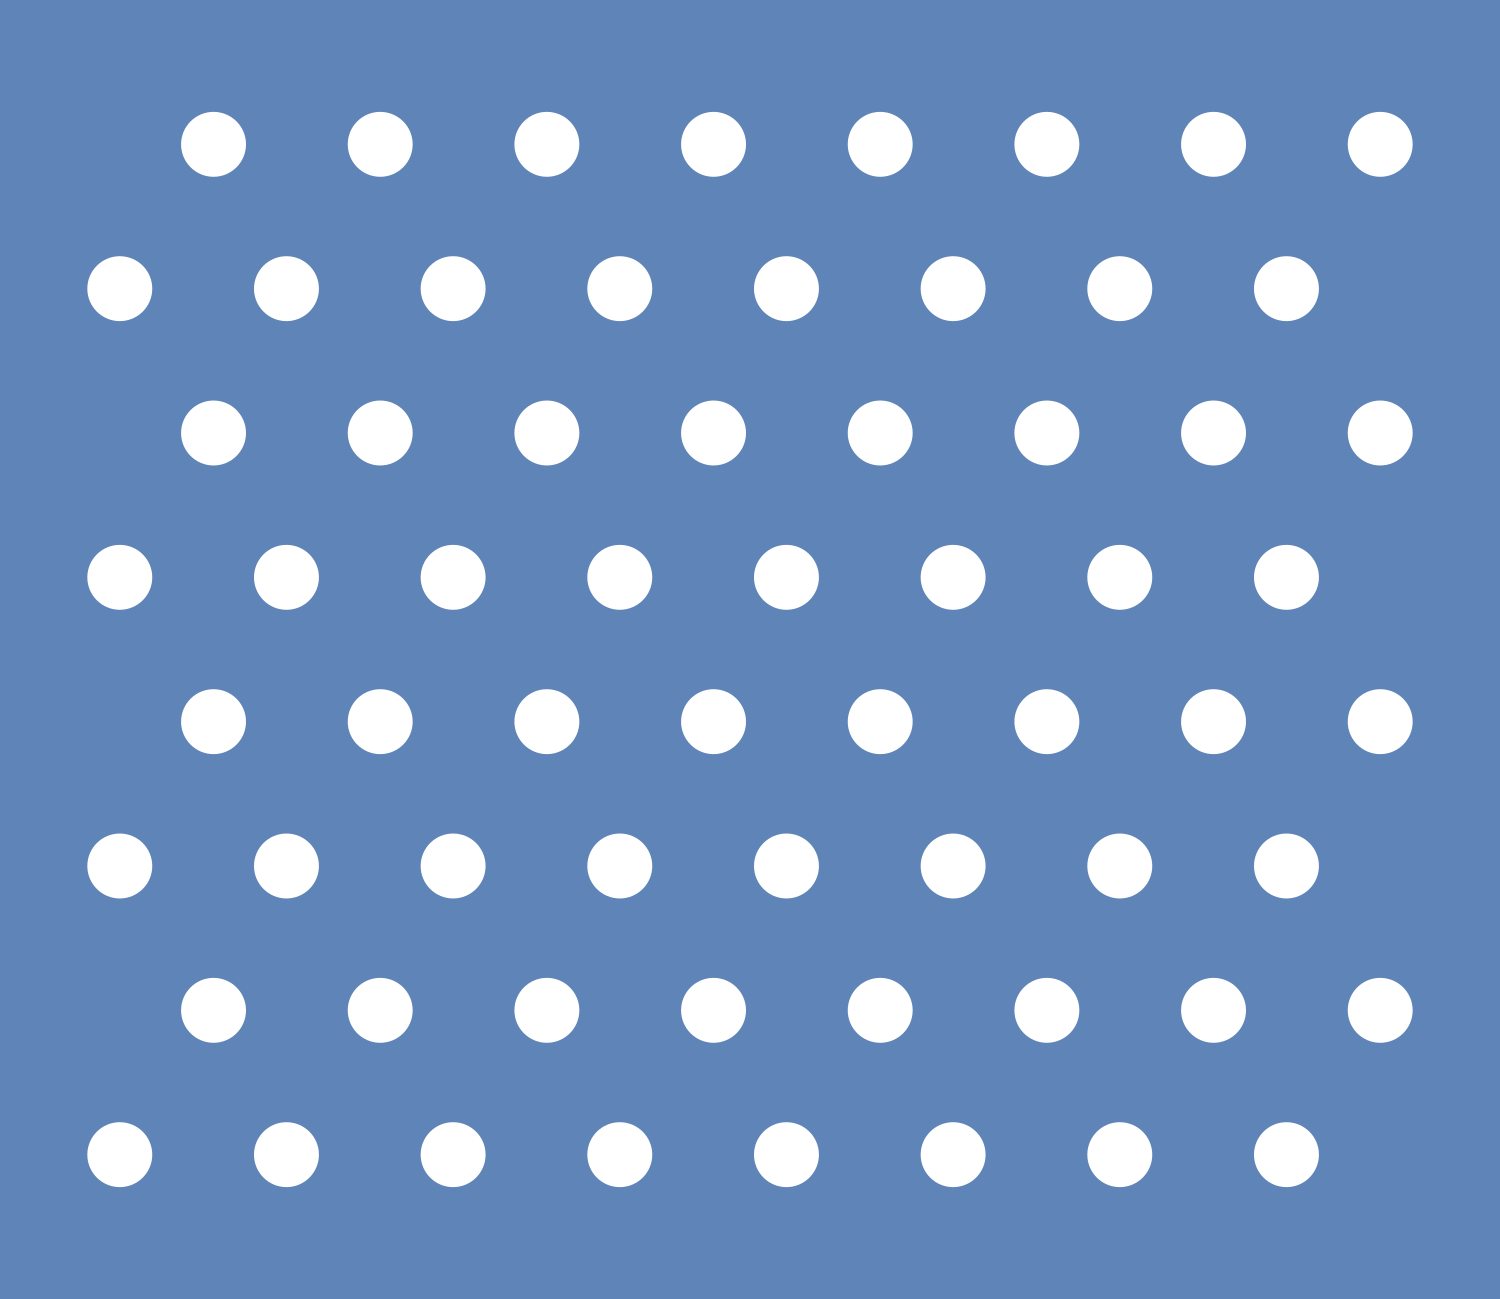

In [17]:
opts_ = opts.copy()
for operator_ in [cairo.OPERATOR_CLEAR, cairo.OPERATOR_ADD, cairo.OPERATOR_SOURCE, cairo.OPERATOR_OVER, cairo.OPERATOR_OUT, cairo.OPERATOR_SCREEN, cairo.OPERATOR_DEST_OUT]: 
    opts_.update(operator=operator_)
    print(f'{operator_}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


## some book keeping for the notebook

In [18]:
%pwd

'/Users/laurentperrinet/sdrive_cnrs/blog/laurentperrinet.github.io_sciblog/posts'

In [19]:
%pip install watermark

Note: you may need to restart the kernel to use updated packages.


In [20]:
%load_ext watermark
%watermark -i -h -m -v -p numpy,cairo  -r -g -b

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.16.0

numpy: 2.5.1
cairo: unknown

Compiler    : Clang 17.0.0 (clang-1700.6.4.2)
OS          : Darwin
Release     : 24.6.0
Machine     : x86_64
Processor   : i386
CPU cores   : 36
Architecture: 64bit

Hostname: Ahsoka

Git hash: a6ce3a08c4fbe0f2d7a8d545dc86f3179c670317

Git repo: https://github.com/laurentperrinet/sciblog

Git branch: master

